# Longitudinal Graph-Aware EM — Main Notebook

In [175]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from __future__ import annotations
from src.features.extraction import (
    extract_article_features,
    extract_ses_features,
    combine_data,
)

In [2]:
# --------------------------- Config / Paths ------------------------
VERSION_A_DIR = Path("../data/processed/version_A")

FEATURES_BASELINE_FNAME = "features_baseline.csv"
FEATURES_FOLLOWUP_FNAME = "features_followup.csv"

CONN_BASELINE_FNAME = "connectomes_baseline.npy"
CONN_FOLLOWUP_FNAME = "connectomes_followup.npy"

SUBJECTS_BASELINE_FNAME = "subjects.csv"
SUBJECTS_FOLLOWUP_FNAME = "subjects.csv"

sleep_df = pd.read_csv('../notebooks/data/ABCD_sleep_Liza.csv')


# --------------------------- I/O Helpers ---------------------------
def _require_columns(df: pd.DataFrame, cols: list[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


def read_features(dirpath: Path, fname: str) -> pd.DataFrame:
    df = pd.read_csv(dirpath / fname)
    _require_columns(df, ["Subject"])
    df["Subject"] = df["Subject"].astype(str)
    return df


def read_connectomes(dirpath: Path, fname: str) -> np.ndarray:
    arr = np.load(dirpath / fname)
    if arr.ndim != 2:
        raise ValueError(f"Connectome array must be 2D, got shape {arr.shape}")
    return arr


def read_subjects(dirpath: Path, fname: str) -> list[str]:
    s = pd.read_csv(dirpath / fname)
    _require_columns(s, ["Subject"])
    return s["Subject"].astype(str).tolist()


def connectomes_to_df(arr: np.ndarray, subjects: list[str]) -> pd.DataFrame:
    if arr.shape[0] != len(subjects):
        raise ValueError(f"{len(subjects)} subjects vs {arr.shape[0]} rows in connectomes")
    cols = [f"conn_{i}" for i in range(arr.shape[1])]
    df = pd.DataFrame(arr, columns=cols)
    df.insert(0, "Subject", subjects)
    return df


def mean_impute_numeric(df: pd.DataFrame, exclude: list[str] | None = None) -> pd.DataFrame:
    exclude = exclude or []
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns.difference(exclude)
    out[num_cols] = out[num_cols].fillna(out[num_cols].mean())
    return out


def restrict_to_common_subjects(*dfs: pd.DataFrame, key: str = "Subject") -> list[pd.DataFrame]:
    """Restrict all dfs to common subjects and sort identically by Subject."""
    subj_sets = [set(df[key].astype(str)) for df in dfs]
    common = set.intersection(*subj_sets)
    if len(common) == 0:
        raise ValueError("No common subjects across provided tables.")

    out = []
    for df in dfs:
        tmp = df[df[key].astype(str).isin(common)].copy()
        tmp[key] = tmp[key].astype(str)
        tmp.sort_values(key, inplace=True, kind="mergesort")
        tmp.reset_index(drop=True, inplace=True)
        out.append(tmp)
    return out


def sample_subjects(df: pd.DataFrame, n: Optional[int], seed: int = 0) -> pd.DataFrame:
    if n is None:
        return df
    if n > len(df):
        raise ValueError(f"Requested n={n}, but only {len(df)} rows available.")
    return df.sample(n=n, random_state=seed).sort_values("Subject").reset_index(drop=True)


# --------------------------- Main Routine ---------------------------
def main(n_subjects: Optional[int] = None) -> None:
    # 1) Load features
    feat_bl = read_features(VERSION_A_DIR, FEATURES_BASELINE_FNAME)
    feat_fu = read_features(VERSION_A_DIR, FEATURES_FOLLOWUP_FNAME)

    # 2) Load connectomes + subject lists
    subs_bl = read_subjects(VERSION_A_DIR, SUBJECTS_BASELINE_FNAME)
    subs_fu = read_subjects(VERSION_A_DIR, SUBJECTS_FOLLOWUP_FNAME)

    conn_bl = connectomes_to_df(read_connectomes(VERSION_A_DIR, CONN_BASELINE_FNAME), subs_bl)
    conn_fu = connectomes_to_df(read_connectomes(VERSION_A_DIR, CONN_FOLLOWUP_FNAME), subs_fu)

    # 3) Build covariates + outcomes (ensure Subject is carried through!)
    # IMPORTANT: make these return tables with Subject included.
    X_bl_article, g_bl = extract_article_features(feat_bl)
    X_fu_article, g_fu = extract_article_features(feat_fu)

    ses_bl = extract_ses_features(feat_bl)
    ses_fu = extract_ses_features(feat_fu)

    cov_bl = combine_data(ses_bl, X_bl_article)
    cov_fu = combine_data(ses_fu, X_fu_article)

    # If these functions don’t already include Subject, do it here:
    for df, feat in [(cov_bl, feat_bl), (cov_fu, feat_fu)]:
        if "Subject" not in df.columns:
            df.insert(0, "Subject", feat["Subject"].astype(str).values)

    # Similarly, make g a Subject-keyed table
    if isinstance(g_bl, pd.Series) and g_bl.name != "g":
        g_bl = g_bl.rename("g")
    if isinstance(g_fu, pd.Series) and g_fu.name != "g":
        g_fu = g_fu.rename("g")

    y_bl = pd.DataFrame({"Subject": feat_bl["Subject"].astype(str), "g": np.asarray(g_bl)})
    y_fu = pd.DataFrame({"Subject": feat_fu["Subject"].astype(str), "g": np.asarray(g_fu)})

    # 4) Align within each timepoint
    cov_bl, conn_bl, y_bl = restrict_to_common_subjects(cov_bl, conn_bl, y_bl)
    cov_fu, conn_fu, y_fu = restrict_to_common_subjects(cov_fu, conn_fu, y_fu)

    # 5) Align across timepoints (keep only subjects present in both BL and FU)
    # Do this by restricting each side to the intersection:
    common = set(cov_bl["Subject"]) & set(cov_fu["Subject"])
    cov_bl = cov_bl[cov_bl["Subject"].isin(common)].sort_values("Subject").reset_index(drop=True)
    conn_bl = conn_bl[conn_bl["Subject"].isin(common)].sort_values("Subject").reset_index(drop=True)
    y_bl   = y_bl[y_bl["Subject"].isin(common)].sort_values("Subject").reset_index(drop=True)

    cov_fu = cov_fu[cov_fu["Subject"].isin(common)].sort_values("Subject").reset_index(drop=True)
    conn_fu = conn_fu[conn_fu["Subject"].isin(common)].sort_values("Subject").reset_index(drop=True)
    y_fu   = y_fu[y_fu["Subject"].isin(common)].sort_values("Subject").reset_index(drop=True)

    # 6) Optional imputation (do it AFTER alignment so means are computed on the kept set)
    conn_fu = mean_impute_numeric(conn_fu, exclude=["Subject"])

    # 7) Optional sampling (AFTER all alignment)
    cov_bl = sample_subjects(cov_bl, n_subjects)
    # and then re-restrict other tables to that exact sample:
    keep = set(cov_bl["Subject"])
    cov_fu = cov_fu[cov_fu["Subject"].isin(keep)].sort_values("Subject").reset_index(drop=True)
    conn_bl = conn_bl[conn_bl["Subject"].isin(keep)].sort_values("Subject").reset_index(drop=True)
    conn_fu = conn_fu[conn_fu["Subject"].isin(keep)].sort_values("Subject").reset_index(drop=True)
    y_bl = y_bl[y_bl["Subject"].isin(keep)].sort_values("Subject").reset_index(drop=True)
    y_fu = y_fu[y_fu["Subject"].isin(keep)].sort_values("Subject").reset_index(drop=True)

    # 8) Final sanity checks
    assert list(cov_bl["Subject"]) == list(conn_bl["Subject"]) == list(y_bl["Subject"])
    assert list(cov_fu["Subject"]) == list(conn_fu["Subject"]) == list(y_fu["Subject"])
    assert list(cov_bl["Subject"]) == list(cov_fu["Subject"])

    print("[OK] n subjects:", len(cov_bl))
    print("cov_bl:", cov_bl.shape, "conn_bl:", conn_bl.shape, "y_bl:", y_bl.shape)
    print("cov_fu:", cov_fu.shape, "conn_fu:", conn_fu.shape, "y_fu:", y_fu.shape)

    return conn_bl, conn_fu, cov_bl, cov_fu, y_bl, y_fu

if __name__ == "__main__":
    conn_bl, conn_fu, cov_bl, cov_fu, y_bl, y_fu = main(n_subjects=None)



Dropping duplicate columns: ['site_id_l', 'Subject']
Dropping duplicate columns: ['site_id_l', 'Subject']
[OK] n subjects: 2409
cov_bl: (2409, 14) conn_bl: (2409, 87154) y_bl: (2409, 2)
cov_fu: (2409, 14) conn_fu: (2409, 87154) y_fu: (2409, 2)


## Data Loading

In [3]:
# Step 1: Check subject ID format in cov_bl
print("=== Subject ID Format Comparison ===")
print(f"Sleep data format: {sleep_df['src_subject_id'].iloc[0]}")
print(f"cov_bl format: {cov_bl['Subject'].iloc[0]}")

# Step 2: Standardize subject IDs (remove underscores if needed)
sleep_df = sleep_df.copy()
sleep_df['Subject'] = sleep_df['src_subject_id'].str.replace('_', '').astype(str)

# Check if formats match now
print(f"\nAfter cleaning:")
print(f"Sleep data format: {sleep_df['Subject'].iloc[0]}")
print(f"cov_bl format: {cov_bl['Subject'].iloc[0]}")

# Step 3: Split by timepoint (only use sleepdisturb1_p_hours due to missing sleep_factor)
sleep_baseline = sleep_df[sleep_df['eventname'] == 'baseline_year_1_arm_1'].copy()
sleep_baseline = sleep_baseline[['Subject', 'sleepdisturb1_p_hours']]
sleep_baseline = sleep_baseline.rename(columns={'sleepdisturb1_p_hours': 'sleep_hours'})
sleep_baseline = sleep_baseline.drop_duplicates(subset='Subject')

sleep_followup = sleep_df[sleep_df['eventname'] == '2_year_follow_up_y_arm_1'].copy()
sleep_followup = sleep_followup[['Subject', 'sleepdisturb1_p_hours']]
sleep_followup = sleep_followup.rename(columns={'sleepdisturb1_p_hours': 'sleep_hours'})
sleep_followup = sleep_followup.drop_duplicates(subset='Subject')

print(f"\nSleep baseline: {len(sleep_baseline)} subjects")
print(f"Sleep followup: {len(sleep_followup)} subjects")

# Step 4: Check overlap
overlap_bl = set(cov_bl['Subject']) & set(sleep_baseline['Subject'])
overlap_fu = set(cov_fu['Subject']) & set(sleep_followup['Subject'])

print(f"\nOverlap with cov_bl: {len(overlap_bl)} / {len(cov_bl)} ({100*len(overlap_bl)/len(cov_bl):.1f}%)")
print(f"Overlap with cov_fu: {len(overlap_fu)} / {len(cov_fu)} ({100*len(overlap_fu)/len(cov_fu):.1f}%)")

# Step 5: Merge
cov_bl_with_sleep = cov_bl.merge(
    sleep_baseline, on='Subject', how='left', suffixes=('', '_sleep')
)
cov_fu_with_sleep = cov_fu.merge(
    sleep_followup, on='Subject', how='left', suffixes=('', '_sleep')
)

# --- Minimal fix: remove duplicated sleep columns ---
for df in [cov_bl_with_sleep, cov_fu_with_sleep]:
    sleep_cols = [c for c in df.columns if c.startswith('sleep_hours')]
    if len(sleep_cols) > 1:
        df['sleep_hours'] = df[sleep_cols].bfill(axis=1).iloc[:, 0]
        df.drop(columns=sleep_cols, inplace=True)

print(f"\n=== After Merging ===")
print(f"cov_bl shape: {cov_bl.shape} -> {cov_bl_with_sleep.shape}")
print(f"cov_fu shape: {cov_fu.shape} -> {cov_fu_with_sleep.shape}")

# Missing values
n_missing_bl = cov_bl_with_sleep['sleep_hours'].isna().sum()
n_missing_fu = cov_fu_with_sleep['sleep_hours'].isna().sum()
print(f"\nMissing sleep_hours:")
print(f"  Baseline: {n_missing_bl} ({100*n_missing_bl/len(cov_bl_with_sleep):.1f}%)")
print(f"  Followup: {n_missing_fu} ({100*n_missing_fu/len(cov_fu_with_sleep):.1f}%)")

# Step 6: Mean imputation for missing values
cov_bl_with_sleep['sleep_hours'] = cov_bl_with_sleep['sleep_hours'].fillna(
    cov_bl_with_sleep['sleep_hours'].mean()
)
cov_fu_with_sleep['sleep_hours'] = cov_fu_with_sleep['sleep_hours'].fillna(
    cov_fu_with_sleep['sleep_hours'].mean()
)

# Step 7: Check time variation of sleep
sleep_bl_vals = cov_bl_with_sleep.set_index('Subject')['sleep_hours']
sleep_fu_vals = cov_fu_with_sleep.set_index('Subject')['sleep_hours']
common_subj = sleep_bl_vals.dropna().index.intersection(sleep_fu_vals.dropna().index)

corr_sleep = np.corrcoef(sleep_bl_vals.loc[common_subj], sleep_fu_vals.loc[common_subj])[0, 1]
mean_diff = np.mean(np.abs(sleep_fu_vals.loc[common_subj] - sleep_bl_vals.loc[common_subj]))

print(f"\n=== Sleep Hours: Time Variation ===")
print(f"Correlation (BL-FU): {float(corr_sleep):.3f}")
print(f"Mean |Δ|: {float(mean_diff):.3f}")
print(f"Mean (BL): {float(sleep_bl_vals.mean()):.2f}")
print(f"Mean (FU): {float(sleep_fu_vals.mean()):.2f}")

print(f"\n=== Final ===")
print(f"cov_bl_with_sleep columns: {cov_bl_with_sleep.columns.tolist()}")

=== Subject ID Format Comparison ===
Sleep data format: NDAR_INV003RTV85
cov_bl format: NDARINV00CY2MDM

After cleaning:
Sleep data format: NDARINV003RTV85
cov_bl format: NDARINV00CY2MDM

Sleep baseline: 11863 subjects
Sleep followup: 10876 subjects

Overlap with cov_bl: 2409 / 2409 (100.0%)
Overlap with cov_fu: 2408 / 2409 (100.0%)

=== After Merging ===
cov_bl shape: (2409, 14) -> (2409, 15)
cov_fu shape: (2409, 14) -> (2409, 15)

Missing sleep_hours:
  Baseline: 0 (0.0%)
  Followup: 1 (0.0%)

=== Sleep Hours: Time Variation ===
Correlation (BL-FU): 0.512
Mean |Δ|: 0.759
Mean (BL): 9.11
Mean (FU): 8.65

=== Final ===
cov_bl_with_sleep columns: ['site_id_l', 'Subject', 'EdYearsHighest', 'IncCombinedMidpoint', 'Income2Needs', 'married_encoded', 'income_encoded', 'age', 'meanFD', 'sex', 'age_squared', 'meanFD_squared', 'hisp_encoded', 'race_encoded', 'sleep_hours']


In [4]:
from typing import Dict, List, Tuple, Optional


def build_cells(K: int, base: int = 1) -> np.ndarray:
    assert isinstance(K, int) and K >= 1
    assert base in (0, 1)

    labels = np.arange(base, base + K, dtype=int)
    C1, C2 = np.meshgrid(labels, labels, indexing="ij")
    mask = C1 <= C2
    return np.column_stack((C1[mask], C2[mask]))


def pair_to_cell_id(a: np.ndarray, b: np.ndarray, K: int, base: int) -> np.ndarray:
    """
    Vectorized mapping (a,b) with a<=b to cell id in [0..C-1] matching build_cells order.
    """
    if base == 1:
        a0 = a - 1
        b0 = b - 1
    else:
        a0 = a
        b0 = b

    # a0,b0 are 0..K-1 and a0<=b0
    return (a0 * K - (a0 * (a0 - 1)) // 2 + (b0 - a0)).astype(int)


def edges_per_cell_from_ids(cell_id_of_edge: np.ndarray, C: int) -> list[np.ndarray]:
    order = np.argsort(cell_id_of_edge, kind="mergesort")
    sorted_ids = cell_id_of_edge[order]
    counts = np.bincount(sorted_ids, minlength=C)

    out = []
    start = 0
    for c in range(C):
        cnt = counts[c]
        out.append(order[start:start + cnt])
        start += cnt
    return out


def group_edges_by_cell(cell_id_of_edge: np.ndarray, C: int) -> List[np.ndarray]:
    """
    Return edges_per_cell as list of arrays of edge indices (k in 0..E-1), one per cell.
    Runs in O(E log E) due to argsort (fast in NumPy).
    """
    order = np.argsort(cell_id_of_edge, kind="mergesort")
    sorted_ids = cell_id_of_edge[order]
    counts = np.bincount(sorted_ids, minlength=C)

    edges_per_cell: List[np.ndarray] = []
    start = 0
    for c in range(C):
        cnt = counts[c]
        edges_per_cell.append(order[start:start + cnt])
        start += cnt
    return edges_per_cell


def map_edges_to_cells(
    sys_labels: np.ndarray,
    base: int = 1,
    require_contiguous: bool = True,
):
    sys_labels = np.asarray(sys_labels, dtype=int)
    n = sys_labels.size
    assert n >= 2
    assert base in (0, 1)

    if require_contiguous:
        if base == 1:
            assert sys_labels.min() == 1, "labels must start at 1 for base=1"
            K = int(sys_labels.max())
            assert np.array_equal(np.unique(sys_labels), np.arange(1, K + 1)), \
                "labels must be contiguous 1..K"
        else:
            assert sys_labels.min() == 0, "labels must start at 0 for base=0"
            K = int(sys_labels.max()) + 1
            assert np.array_equal(np.unique(sys_labels), np.arange(0, K)), \
                "labels must be contiguous 0..K-1"
    else:
        # infer K from unique labels, but you should remap before using pair_to_cell_id
        uniq = np.unique(sys_labels)
        K = uniq.size
        raise ValueError("If require_contiguous=False, remap labels to contiguous first.")

    cells = build_cells(K, base=base)
    C = cells.shape[0]

    iu_i, iu_j = np.triu_indices(n, k=1)
    a = sys_labels[iu_i]
    b = sys_labels[iu_j]
    amin = np.minimum(a, b)
    amax = np.maximum(a, b)

    cell_id_of_edge = pair_to_cell_id(amin, amax, K=K, base=base)

    # Optional: edges_by_cell as (i,j) pairs, built without Python edge loop
    # (still uses grouping by cell ids)
    #edges_per_cell = group_edges_by_cell(cell_id_of_edge, C=C)
    C = cells.shape[0]
    edges_per_cell = edges_per_cell_from_ids(cell_id_of_edge, C)
    edges_by_cell: Dict[int, np.ndarray] = {}
    for c, edge_idx in enumerate(edges_per_cell):
        edges_by_cell[c] = np.column_stack((iu_i[edge_idx], iu_j[edge_idx])).astype(int)

    return cells, (iu_i, iu_j), cell_id_of_edge, edges_by_cell, edges_per_cell


def build_cells_from_gordon(regions: pd.DataFrame, n_edges: int):
    if "NetworkNumber" not in regions.columns:
        raise KeyError("regions must contain column 'NetworkNumber'")

    sys_labels_raw = regions["NetworkNumber"].to_numpy()
    R = sys_labels_raw.size

    expected_E = R * (R - 1) // 2
    if expected_E != n_edges:
        raise ValueError(
            f"Connectomes have E={n_edges} edges, but Gordon has R={R} ROIs, "
            f"so R*(R-1)/2={expected_E}. Different ROIs or flattening."
        )

    unique_labels = np.sort(np.unique(sys_labels_raw))
    K = unique_labels.size
    label_to_new = {old: i + 1 for i, old in enumerate(unique_labels)}
    sys_labels = np.array([label_to_new[x] for x in sys_labels_raw], dtype=int)

    print("Original NetworkNumber values:", unique_labels)
    print(f"Remapped to contiguous labels 1..{K}")

    cells, tri_idx, cell_id_of_edge, edges_by_cell, edges_per_cell = map_edges_to_cells(
        sys_labels,
        base=1,
        require_contiguous=True,
    )

    # Sanity: partition check without expensive set()
    E = n_edges
    sizes = sum(arr.size for arr in edges_per_cell)
    if sizes != E:
        raise RuntimeError("edges_per_cell sizes do not sum to E")

    # Check it’s a permutation of 0..E-1
    all_edges = np.concatenate(edges_per_cell)
    if all_edges.size != E or not np.array_equal(np.sort(all_edges), np.arange(E)):
        raise RuntimeError("edges_per_cell does not partition [0..E-1] correctly")

    return cells, tri_idx, cell_id_of_edge, edges_per_cell


In [5]:
regions = pd.read_csv("../data/raw/gordon_sub_cere_parcels.csv")

In [6]:
E_bl = conn_bl.shape[1] - 1  # subtract Subject
E_fu = conn_fu.shape[1] - 1

assert E_bl == E_fu, "Baseline and follow-up must have same number of edges"

assert E_bl == E_fu, "Baseline and follow-up must have same number of edges"
assert conn_bl.shape[1] == E_bl + 1
assert conn_fu.shape[1] == E_bl + 1

# Gordon cells
cells, tri_idx, cell_id_of_edge, edges_per_cell = build_cells_from_gordon(regions=regions, n_edges=E_bl)

K = len(np.unique(regions["NetworkNumber"]))
print(f"K = {K}")
print(f"C = {cells.shape[0]}")

R = regions.shape[0]
print(f"ROIs: R={R} => expected E={R*(R-1)//2}, observed E={E_bl}")

counts = np.array([len(e) for e in edges_per_cell])
print(f"Edges per cell: min={counts.min()}, median={int(np.median(counts))}, max={counts.max()}")
print(f"Sum edges across cells: {counts.sum()} (should equal {E_bl})")
assert counts.sum() == E_bl

def assert_subject_alignment(*dfs, key="Subject"):
    base = dfs[0][key].astype(str).to_numpy()
    for i, df in enumerate(dfs[1:], start=1):
        other = df[key].astype(str).to_numpy()
        if base.shape != other.shape or not np.array_equal(base, other):
            m = np.where(base != other)[0]
            j = int(m[0]) if m.size else -1
            raise AssertionError(f"Subject mismatch df0 vs df{i} at row {j}: {base[j]} vs {other[j]}")


print("\n=== Missing Values ===")
print(f"main_bl missing: {cov_bl.isnull().sum().sum()}")
print(f"main_fu missing: {cov_fu.isnull().sum().sum()}")

print("\n=== Age Info ===")
print(f"Baseline age range: {cov_bl['age'].min():.1f} - {cov_bl['age'].max():.1f}")
print(f"Follow-up age range: {cov_fu['age'].min():.1f} - {cov_fu['age'].max():.1f}")


# Mapping for block construction
iu_i, iu_j = tri_idx

# edge_to_roi[e] = (roi_left, roi_right) as 0-indexed positions
edge_to_roi = np.column_stack([iu_i, iu_j]).astype(np.int32)

Original NetworkNumber values: [ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16]
Remapped to contiguous labels 1..15
K = 15
C = 120
ROIs: R=418 => expected E=87153, observed E=87153
Edges per cell: min=6, median=552, max=2538
Sum edges across cells: 87153 (should equal 87153)

=== Missing Values ===
main_bl missing: 0
main_fu missing: 0

=== Age Info ===
Baseline age range: 107.0 - 133.0
Follow-up age range: 129.0 - 164.0


In [7]:
# Add g_lavaan to the combined feature DataFrames
cov_bl = cov_bl_with_sleep.merge(y_bl, on="Subject", how="left")
cov_fu = cov_fu_with_sleep.merge(y_fu, on="Subject", how="left")

print("=== Updated main_bl ===")
print(f"Shape: {cov_bl.shape}")
print(f"Columns: {cov_bl.columns.tolist()}")

# Verify no missing values were introduced
print(f"\nMissing values in main_bl: {cov_bl.isnull().sum().sum()}")
print(f"Missing values in main_fu: {cov_fu.isnull().sum().sum()}")

=== Updated main_bl ===
Shape: (2409, 16)
Columns: ['site_id_l', 'Subject', 'EdYearsHighest', 'IncCombinedMidpoint', 'Income2Needs', 'married_encoded', 'income_encoded', 'age', 'meanFD', 'sex', 'age_squared', 'meanFD_squared', 'hisp_encoded', 'race_encoded', 'sleep_hours', 'g']

Missing values in main_bl: 0
Missing values in main_fu: 0


In [8]:
# Extract connectome arrays
conn_cols = [c for c in conn_bl.columns if c.startswith('conn_')]

conn_baseline = conn_bl[conn_cols].values
conn_followup = conn_fu[conn_cols].values

print("=== Connectome Arrays ===")
print(f"conn_baseline shape: {conn_baseline.shape}")
print(f"conn_followup shape: {conn_followup.shape}")
print(f"Data type: {conn_baseline.dtype}")

# Quick sanity check - values should be Fisher-transformed correlations (typically -3 to 3)
print(f"\nBaseline value range: [{conn_baseline.min():.2f}, {conn_baseline.max():.2f}]")
print(f"Follow-up value range: [{conn_followup.min():.2f}, {conn_followup.max():.2f}]")

# Check for any NaN/Inf
print(f"\nBaseline NaN count: {np.isnan(conn_baseline).sum()}")
print(f"Baseline Inf count: {np.isinf(conn_baseline).sum()}")
print(f"Follow-up NaN count: {np.isnan(conn_followup).sum()}")
print(f"Follow-up Inf count: {np.isinf(conn_followup).sum()}")

=== Connectome Arrays ===
conn_baseline shape: (2409, 87153)
conn_followup shape: (2409, 87153)
Data type: float64

Baseline value range: [-0.80, 1.00]
Follow-up value range: [-0.71, 1.00]

Baseline NaN count: 0
Baseline Inf count: 0
Follow-up NaN count: 0
Follow-up Inf count: 0


In [9]:
# Build cell structure
cells, tri_idx, cell_id_of_edge, edges_per_cell = build_cells_from_gordon(
    regions,
    n_edges=conn_baseline.shape[1]  # 87153
)

print("=== Cell Structure ===")
print(f"Number of cells (C): {len(cells)}")
print(f"cells shape: {cells.shape}")
print(f"cell_id_of_edge shape: {cell_id_of_edge.shape}")
print(f"Number of edges per cell (first 10): {[len(e) for e in edges_per_cell[:10]]}")

# Show which communities we have
print(f"\n=== Community Info ===")
print(f"Unique NetworkNumbers: {sorted(regions['NetworkNumber'].unique())}")
print(f"Community names: {regions[['NetworkNumber', 'Community']].drop_duplicates().sort_values('NetworkNumber').values}")

Original NetworkNumber values: [ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16]
Remapped to contiguous labels 1..15
=== Cell Structure ===
Number of cells (C): 120
cells shape: (120, 2)
cell_id_of_edge shape: (87153,)
Number of edges per cell (first 10): [703, 304, 1520, 912, 1558, 1482, 912, 152, 2052, 874]

=== Community Info ===
Unique NetworkNumbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Community names: [[1 'SMhand']
 [2 'SMmouth']
 [3 'CinguloOperc']
 [4 'Auditory']
 [5 'Default']
 [7 'Visual']
 [8 'FrontoParietal']
 [9 'Salience']
 [10 'Subcortical']
 [11 'VentralAttn']
 [12 'DorsalAttn']
 [13 'Cerebellum']
 [14 nan]
 [15 'CinguloParietal']
 [16 'RetrosplenialTemporal']]


In [10]:
#Prepare data for the longitudinal model

# Define covariate columns
time_invariant_cols = ['sex', 'race_encoded', 'hisp_encoded', 'site_id_l']

time_varying_cols = [
    'age', 'age_squared',
    'meanFD', 'meanFD_squared',
    'EdYearsHighest', 'IncCombinedMidpoint', 'Income2Needs',
    'married_encoded', 'income_encoded','sleep_hours',
    'g'
]

# Verify all columns exist
print("=== Verifying columns ===")
missing_ti = [c for c in time_invariant_cols if c not in cov_bl.columns]
missing_tv = [c for c in time_varying_cols if c not in cov_bl.columns]
print(f"Missing time-invariant cols: {missing_ti}")
print(f"Missing time-varying cols: {missing_tv}")

# Check data types (should be numeric)
print("\n=== Data types for time-invariant ===")
print(cov_bl[time_invariant_cols].dtypes)

print("\n=== Data types for time-varying ===")
print(cov_bl[time_varying_cols].dtypes)

=== Verifying columns ===
Missing time-invariant cols: []
Missing time-varying cols: []

=== Data types for time-invariant ===
sex             float64
race_encoded      int64
hisp_encoded      int64
site_id_l        object
dtype: object

=== Data types for time-varying ===
age                    float64
age_squared            float64
meanFD                 float64
meanFD_squared         float64
EdYearsHighest         float64
IncCombinedMidpoint    float64
Income2Needs           float64
married_encoded          int64
income_encoded           int64
sleep_hours            float64
g                      float64
dtype: object


In [13]:
# Encode site_id_l

print("=== Site Information ===")
print(f"Unique sites: {cov_bl['site_id_l'].unique()}")
print(f"Number of sites: {cov_bl['site_id_l'].nunique()}")
print(f"\nSite counts:\n{cov_bl['site_id_l'].value_counts()}")

# Check if sites are the same at both timepoints (they should be)
sites_match = (cov_bl['site_id_l'] == cov_fu['site_id_l']).all()
print(f"\nSites match between timepoints: {sites_match}")

=== Site Information ===
Unique sites: ['site20' 'site04' 'site16' 'site19' 'site02' 'site05' 'site17' 'site13'
 'site08' 'site15' 'site10' 'site18' 'site06' 'site11' 'site21' 'site14'
 'site12' 'site03' 'site09']
Number of sites: 19

Site counts:
site_id_l
site16    321
site04    232
site20    176
site14    176
site06    166
site03    149
site13    147
site02    145
site10    139
site21    119
site17     96
site18     88
site05     85
site11     72
site19     65
site09     63
site08     59
site15     58
site12     53
Name: count, dtype: int64

Sites match between timepoints: False


In [14]:
# Investigate site mismatch

# How many subjects changed sites?
site_changed = cov_bl['site_id_l'] != cov_fu['site_id_l']
print(f"Subjects who changed sites: {site_changed.sum()} ({100*site_changed.mean():.1f}%)")

# Show some examples
if site_changed.sum() > 0:
    print("\nExamples of site changes:")
    changed_idx = site_changed[site_changed].index[:5]
    print(cov_bl.loc[changed_idx, ['Subject', 'site_id_l']].rename(columns={'site_id_l': 'site_baseline'}))
    print(cov_fu.loc[changed_idx, ['Subject', 'site_id_l']].rename(columns={'site_id_l': 'site_followup'}))

Subjects who changed sites: 18 (0.7%)

Examples of site changes:
             Subject site_baseline
140  NDARINV1F953XCP        site08
600  NDARINV7J3KXGBK        site11
634  NDARINV7YJ6UFDB        site04
664  NDARINV8BK50DPV        site15
810  NDARINVA2ZPZTJJ        site05
             Subject site_followup
140  NDARINV1F953XCP        site18
600  NDARINV7J3KXGBK        site20
634  NDARINV7YJ6UFDB        site02
664  NDARINV8BK50DPV        site17
810  NDARINVA2ZPZTJJ        site08


In [15]:
# Encode site as dummy variables

# Create dummy variables for site (using baseline site for both timepoints)
site_dummies = pd.get_dummies(cov_bl['site_id_l'], prefix='site', drop_first=True)

print(f"=== Site Dummy Encoding ===")
print(f"Number of site dummy columns: {site_dummies.shape[1]}")
print(f"Dummy columns: {site_dummies.columns.tolist()[:5]}... (showing first 5)")

# Add to both main_bl and main_fu (using baseline site for both)
for col in site_dummies.columns:
    cov_bl[col] = site_dummies[col].values
    cov_fu[col] = site_dummies[col].values  # Use baseline site for follow-up too

print(f"\nUpdated main_bl shape: {cov_bl.shape}")
print(f"Updated main_fu shape: {cov_fu.shape}")

# Update time_invariant_cols to include site dummies instead of site_id_l
site_dummy_cols = site_dummies.columns.tolist()
time_invariant_cols = ['sex', 'race_encoded', 'hisp_encoded'] + site_dummy_cols

print(f"\nUpdated time_invariant_cols ({len(time_invariant_cols)} columns):")
print(f"  - sex, race_encoded, hisp_encoded")
print(f"  - {len(site_dummy_cols)} site dummy variables")

=== Site Dummy Encoding ===
Number of site dummy columns: 18
Dummy columns: ['site_site03', 'site_site04', 'site_site05', 'site_site06', 'site_site08']... (showing first 5)

Updated main_bl shape: (2409, 34)
Updated main_fu shape: (2409, 34)

Updated time_invariant_cols (21 columns):
  - sex, race_encoded, hisp_encoded
  - 18 site dummy variables


In [16]:
# Verify our covariate lists
print("=== Final Covariate Lists ===")
print(f"Time-invariant ({len(time_invariant_cols)}): {time_invariant_cols[:5]}...")
print(f"Time-varying ({len(time_varying_cols)}): {time_varying_cols}")

# Extract covariate arrays
Z_covariates = cov_bl[time_invariant_cols].values.astype(np.float64)
V_baseline = cov_bl[time_varying_cols].values.astype(np.float64)
V_followup = cov_fu[time_varying_cols].values.astype(np.float64)

print(f"\n=== Covariate Array Shapes ===")
print(f"Z_covariates (time-invariant): {Z_covariates.shape}")
print(f"V_baseline (time-varying): {V_baseline.shape}")
print(f"V_followup (time-varying): {V_followup.shape}")

# Stack for model
Y = np.stack([conn_baseline, conn_followup], axis=1)  # (N, T, E)
V_covariates = np.stack([V_baseline, V_followup], axis=1)  # (N, T, p_v)
ages = np.stack([
    cov_bl['age'].values,
    cov_fu['age'].values
], axis=1)  # (N, T)

print(f"\n=== Stacked Array Shapes ===")
print(f"Y (connectomes): {Y.shape}")
print(f"V_covariates: {V_covariates.shape}")
print(f"ages: {ages.shape}")

# Subject IDs
subject_ids = cov_bl['Subject'].values

print(f"\n=== Ready to create LongitudinalData ===")
print(f"N subjects: {len(subject_ids)}")
print(f"T timepoints: {Y.shape[1]}")
print(f"E edges: {Y.shape[2]}")

=== Final Covariate Lists ===
Time-invariant (21): ['sex', 'race_encoded', 'hisp_encoded', 'site_site03', 'site_site04']...
Time-varying (11): ['age', 'age_squared', 'meanFD', 'meanFD_squared', 'EdYearsHighest', 'IncCombinedMidpoint', 'Income2Needs', 'married_encoded', 'income_encoded', 'sleep_hours', 'g']

=== Covariate Array Shapes ===
Z_covariates (time-invariant): (2409, 21)
V_baseline (time-varying): (2409, 11)
V_followup (time-varying): (2409, 11)

=== Stacked Array Shapes ===
Y (connectomes): (2409, 2, 87153)
V_covariates: (2409, 2, 11)
ages: (2409, 2)

=== Ready to create LongitudinalData ===
N subjects: 2409
T timepoints: 2
E edges: 87153


In [17]:
# Create LongitudinalData object

from src.model.model_structures import LongitudinalData

data = LongitudinalData(
    Y = Y.astype(np.float32, copy=False),
    Z_covariates = Z_covariates.astype(np.float32, copy=False),
    V_covariates = V_covariates.astype(np.float32, copy=False),
    ages = ages.astype(np.float32, copy=False),
    subject_ids=subject_ids,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    cells=cells
)

# Validate the data
data.validate()

# Print summary
print(f"\n=== LongitudinalData Summary ===")
print(f"Dimensions: {data.dims}")
print(f"  N (subjects): {data.dims.N}")
print(f"  T (timepoints): {data.dims.T}")
print(f"  E (edges): {data.dims.E}")
print(f"  K (communities): {data.dims.K}")
print(f"  C (cells): {data.dims.C}")
print(f"  p_z (time-invariant covariates): {data.dims.p_z}")
print(f"  p_v (time-varying covariates): {data.dims.p_v}")
print(f"  Total fixed effects: {data.dims.n_fixed_effects}")

✓ Data validation passed: ModelDimensions(N=2409, T=2, E=87153, K=15, C=120, n_fixed=174578)

=== LongitudinalData Summary ===
Dimensions: ModelDimensions(N=2409, T=2, E=87153, K=15, C=120, n_fixed=174578)
  N (subjects): 2409
  T (timepoints): 2
  E (edges): 87153
  K (communities): 15
  C (cells): 120
  p_z (time-invariant covariates): 21
  p_v (time-varying covariates): 11
  Total fixed effects: 174578


# SES from R

In [18]:
ses_cols = ["EdYearsHighest", "IncCombinedMidpoint", "Income2Needs"]

df_bl = cov_bl[ses_cols].copy()
df_fu = cov_fu[ses_cols].copy()

df_bl["timepoint"] = "baseline"
df_fu["timepoint"] = "followup"

df_ses = pd.concat([df_bl, df_fu], axis=0).reset_index(drop=True)
df_ses.to_csv("ses_data.csv", index=False)
#df_ses.head()
ses = pd.read_csv("ses_with_scores.csv")
ses.head()

,EdYearsHighest,IncCombinedMidpoint,Income2Needs,timepoint,SES
0,14.0,42500.0,1.476720,baseline,-1.043822
1,12.0,42500.0,1.116658,baseline,-1.066926
2,16.0,150000.0,4.038772,baseline,0.667791
3,16.0,150000.0,5.211953,baseline,0.710641
4,16.0,150000.0,2.584425,baseline,0.614673


## OLS Baseline: Naive vs Clustered SE

In [19]:
# ── build cell labels ─────────────────────────────────────────────
community_info = regions.groupby('NetworkNumber').agg({
    'Community': 'first',
    'ParcelID': 'count',
}).reset_index()
community_info.columns = ['NetworkNumber', 'CommunityName', 'NodeCount']
community_info = community_info.sort_values('NetworkNumber')

network_order = community_info['CommunityName'].tolist()
cell_labels = []
for c_idx in range(len(cells)):
    a, b = cells[c_idx]
    if cells.min() == 1:
        a, b = a - 1, b - 1
    cell_labels.append((network_order[a], network_order[b]))

print(f"Community info:\n{community_info}")
print(f"\nCell labels: {len(cell_labels)} cells")
print(f"First 3: {cell_labels[:3]}")

# roi_to_network: needed by BlockV class
roi_to_network = regions["NetworkNumber"].values


Community info:
    NetworkNumber          CommunityName  NodeCount
0               1                 SMhand         38
1               2                SMmouth          8
2               3           CinguloOperc         40
3               4               Auditory         24
4               5                Default         41
5               7                 Visual         39
6               8         FrontoParietal         24
7               9               Salience          4
8              10            Subcortical         54
9              11            VentralAttn         23
10             12             DorsalAttn         32
11             13             Cerebellum         31
12             14                   None         47
13             15        CinguloParietal          5
14             16  RetrosplenialTemporal          8

Cell labels: 120 cells
First 3: [('SMhand', 'SMhand'), ('SMhand', 'SMmouth'), ('SMhand', 'CinguloOperc')]


In [20]:
# Create matched subsample for both models

np.random.seed(42356)
N_sample = 2409

# Sample subject indices
#sample_subjects = np.random.choice(data.dims.N, size=N_sample, replace=False)
#sample_subjects = np.sort(sample_subjects)

print(f"=== Subsample: {N_sample} subjects ===\n")

# --- Prepare data for LONGITUDINAL model ---
#conn_baseline_sub = conn_baseline[sample_subjects]
#conn_followup_sub = conn_followup[sample_subjects]
conn_baseline_sub = conn_baseline
conn_followup_sub = conn_followup
#ages_sub = ages[sample_subjects]
ages_sub = ages
# Stack for longitudinal
Y_stacked_sub = np.vstack([conn_baseline_sub, conn_followup_sub])
ages_raw_stacked_sub = np.concatenate([ages_sub[:, 0], ages_sub[:, 1]])
ages_centered_sub = (ages_raw_stacked_sub - ages_raw_stacked_sub.mean()) / ages_raw_stacked_sub.std()
X_stacked_sub = np.column_stack([np.ones(2 * N_sample), ages_centered_sub])
subject_id_sub = np.concatenate([np.arange(N_sample), np.arange(N_sample)])

print(f"Longitudinal setup:")
print(f"  Y shape: {Y_stacked_sub.shape}")
print(f"  N_obs: {2 * N_sample}, N_subjects: {N_sample}")

print(f"\nNaive (cross-sectional) setup:")
print(f"  Y shape: {Y_stacked_sub.shape}")
print(f"  N_obs: {2 * N_sample} (treated as independent)")

=== Subsample: 2409 subjects ===

Longitudinal setup:
  Y shape: (4818, 87153)
  N_obs: 4818, N_subjects: 2409

Naive (cross-sectional) setup:
  Y shape: (4818, 87153)
  N_obs: 4818 (treated as independent)


In [21]:
# Step 1: Cell-wise Pooled OLS with Naive and Clustered Standard Errors

def cell_wise_ols_with_se(
    Y: np.ndarray,
    X: np.ndarray,
    subject_id: np.ndarray,
    cell_id_of_edge: np.ndarray,
) -> dict:
    """
    Pooled OLS per cell with naive and subject-clustered standard errors.

    Both estimators share the same point estimate. The comparison
    isolates the cost of ignoring within-subject correlation in the
    variance formula alone.

    Parameters
    ----------
    Y : (N_obs, E)
        Stacked connectivity data (baseline rows then follow-up rows).
    X : (N_obs, p)
        Design matrix, e.g. [1, standardized_age].
    subject_id : (N_obs,)
        Integer subject index in 0..N_subjects-1 for each row of Y.
    cell_id_of_edge : (E,)
        Cell assignment for each edge, integer in 0..C-1.

    Returns
    -------
    dict with keys:
        'beta'      : (C, p) OLS estimates
        'se_naive'  : (C, p) naive standard errors (assumes independence)
        'se_clust'  : (C, p) clustered standard errors (clusters = subjects)
    """
    N_obs, E = Y.shape
    p = X.shape[1]
    N_subjects = int(subject_id.max()) + 1
    C = int(cell_id_of_edge.max()) + 1

    beta     = np.zeros((C, p))
    se_naive = np.zeros((C, p))
    se_clust = np.zeros((C, p))

    # Precompute gram matrix — identical across cells
    XtX     = X.T @ X          # (p, p)
    XtX_inv = np.linalg.inv(XtX)

    for c in range(C):
        edge_mask = (cell_id_of_edge == c)
        E_c = int(edge_mask.sum())
        if E_c == 0:
            continue

        Y_c = Y[:, edge_mask]           # (N_obs, E_c)
        Y_c_sum = Y_c.sum(axis=1)       # (N_obs,)  — sum over edges per observation

        # --- OLS estimate ---
        # Pooled gram: E_c * X^T X  =>  inverse is XtX_inv / E_c
        XtX_c_inv = XtX_inv / E_c
        beta[c]   = XtX_c_inv @ (X.T @ Y_c_sum)

        # --- Residuals ---
        Y_hat_c      = X @ beta[c]                        # (N_obs,)
        residuals_c  = Y_c - Y_hat_c[:, np.newaxis]       # (N_obs, E_c)

        # --- Naive SE ---
        # Assumes all N_obs * E_c observations are independent
        RSS_c    = float(np.sum(residuals_c ** 2))
        df_naive = N_obs * E_c - p                        # naive degrees of freedom
        sigma2_c = RSS_c / df_naive
        se_naive[c] = np.sqrt(np.diag(sigma2_c * XtX_c_inv))

        # --- Clustered SE (sandwich, clusters = subjects) ---
        # Score for each observation: x_{m,t} * sum_i(ε_{m,t,i})
        scores = X * residuals_c.sum(axis=1, keepdims=True)  # (N_obs, p)

        # Accumulate scores by subject: u[m] = sum over subject m's rows
        u = np.zeros((N_subjects, p))
        np.add.at(u, subject_id, scores)                     # (N_subjects, p)

        # Sandwich: (E_c * X^T X)^{-1}  [sum_m u_m u_m^T]  (E_c * X^T X)^{-1}
        meat         = u.T @ u                               # (p, p)
        var_clust_c  = XtX_c_inv @ meat @ XtX_c_inv
        se_clust[c]  = np.sqrt(np.diag(var_clust_c))

    return {'beta': beta, 'se_naive': se_naive, 'se_clust': se_clust}

In [22]:
# Run the analysis
print("=== Running Cell-wise OLS ===")
results = cell_wise_ols_with_se(
    Y=Y_stacked_sub,
    X=X_stacked_sub,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    #n_cells=120  # C = K(K+1)/2 for K=15
)

print(f"Beta shape: {results['beta'].shape}")
print(f"SE naive shape: {results['se_naive'].shape}")
print(f"SE clustered shape: {results['se_clust'].shape}")

# Extract age effects (second column)
alpha1_hat = results['beta'][:, 1]
se_naive_alpha1 = results['se_naive'][:, 1]
se_clust_alpha1 = results['se_clust'][:, 1]

print(f"\n=== Age Effect Summary ===")
print(f"alpha1 range: [{alpha1_hat.min():.6f}, {alpha1_hat.max():.6f}]")
print(f"SE naive range: [{se_naive_alpha1.min():.6f}, {se_naive_alpha1.max():.6f}]")
print(f"SE clustered range: [{se_clust_alpha1.min():.6f}, {se_clust_alpha1.max():.6f}]")

# Inflation ratio
inflation_ratio = se_clust_alpha1 / se_naive_alpha1
print(f"\n=== SE Inflation (Clustered / Naive) ===")
print(f"Mean: {inflation_ratio.mean():.2f}")
print(f"Min: {inflation_ratio.min():.2f}")
print(f"Max: {inflation_ratio.max():.2f}")  # Run the analysis
print("=== Running Cell-wise OLS ===")
results = cell_wise_ols_with_se(
    Y=Y_stacked_sub,
    X=X_stacked_sub,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    #n_cells=120  # C = K(K+1)/2 for K=15
)

print(f"Beta shape: {results['beta'].shape}")
print(f"SE naive shape: {results['se_naive'].shape}")
print(f"SE clustered shape: {results['se_clust'].shape}")

# Extract age effects (second column)
alpha1_hat = results['beta'][:, 1]
se_naive_alpha1 = results['se_naive'][:, 1]
se_clust_alpha1 = results['se_clust'][:, 1]

print(f"\n=== Age Effect Summary ===")
print(f"alpha1 range: [{alpha1_hat.min():.6f}, {alpha1_hat.max():.6f}]")
print(f"SE naive range: [{se_naive_alpha1.min():.6f}, {se_naive_alpha1.max():.6f}]")
print(f"SE clustered range: [{se_clust_alpha1.min():.6f}, {se_clust_alpha1.max():.6f}]")

# Inflation ratio
inflation_ratio = se_clust_alpha1 / se_naive_alpha1
print(f"\n=== SE Inflation (Clustered / Naive) ===")
print(f"Mean: {inflation_ratio.mean():.2f}")
print(f"Min: {inflation_ratio.min():.2f}")
print(f"Max: {inflation_ratio.max():.2f}")

=== Running Cell-wise OLS ===
Beta shape: (120, 2)
SE naive shape: (120, 2)
SE clustered shape: (120, 2)

=== Age Effect Summary ===
alpha1 range: [-0.005329, 0.014633]
SE naive range: [0.000015, 0.000744]
SE clustered range: [0.000141, 0.001200]

=== SE Inflation (Clustered / Naive) ===
Mean: 6.74
Min: 1.45
Max: 13.00
=== Running Cell-wise OLS ===
Beta shape: (120, 2)
SE naive shape: (120, 2)
SE clustered shape: (120, 2)

=== Age Effect Summary ===
alpha1 range: [-0.005329, 0.014633]
SE naive range: [0.000015, 0.000744]
SE clustered range: [0.000141, 0.001200]

=== SE Inflation (Clustered / Naive) ===
Mean: 6.74
Min: 1.45
Max: 13.00


In [23]:
from scipy import stats

# Compute t-statistics
t_naive = alpha1_hat / se_naive_alpha1
t_clust = alpha1_hat / se_clust_alpha1

# Compute p-values (two-sided, using normal approximation)
p_naive = 2 * (1 - stats.norm.cdf(np.abs(t_naive)))
p_clust = 2 * (1 - stats.norm.cdf(np.abs(t_clust)))

# Significance at alpha = 0.05
sig_naive_raw = (p_naive < 0.05).sum()
sig_clust_raw = (p_clust < 0.05).sum()

print("=== Inference Comparison ===")
print(f"\nt-statistic ratio (naive/clust): {np.mean(np.abs(t_naive/t_clust)):.2f}")
print(f"\nSignificant cells (p < 0.05):")
print(f"  Naive SE:     {sig_naive_raw} / 120 ({100*sig_naive_raw/120:.1f}%)")
print(f"  Clustered SE: {sig_clust_raw} / 120 ({100*sig_clust_raw/120:.1f}%)")

# With multiple testing correction (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests

reject_naive_bh, _, _, _ = multipletests(p_naive, alpha=0.05, method='fdr_bh')
reject_clust_bh, _, _, _ = multipletests(p_clust, alpha=0.05, method='fdr_bh')

print(f"\nSignificant cells (BH-corrected, FDR = 0.05):")
print(f"  Naive SE:     {reject_naive_bh.sum()} / 120")
print(f"  Clustered SE: {reject_clust_bh.sum()} / 120")

# False positives due to ignoring clustering
false_positives = (reject_naive_bh & ~reject_clust_bh).sum()
print(f"\nPotential false positives (significant with naive only): {false_positives}")

=== Inference Comparison ===

t-statistic ratio (naive/clust): 6.74

Significant cells (p < 0.05):
  Naive SE:     114 / 120 (95.0%)
  Clustered SE: 82 / 120 (68.3%)

Significant cells (BH-corrected, FDR = 0.05):
  Naive SE:     114 / 120
  Clustered SE: 74 / 120

Potential false positives (significant with naive only): 40


## Helper Functions

In [24]:
from scipy.stats import norm


def adjust_pvalues(pvals, method="BH"):
    """
    Multiple testing correction.

    Parameters
    ----------
    pvals : array-like, shape (m,)
        Raw p-values.
    method : {"BH", "BY", "holm"}, default="BH"
        BH   = Benjamini-Hochberg FDR control
        BY   = Benjamini-Yekutieli FDR control (valid under arbitrary dependence)
        holm = Holm step-down FWER control

    Returns
    -------
    p_adj : ndarray, shape (m,)
        Adjusted p-values.
    """
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)

    if m == 0:
        return np.array([], dtype=float)

    if np.any(~np.isfinite(pvals)):
        raise ValueError("pvals must be finite.")
    if np.any((pvals < 0) | (pvals > 1)):
        raise ValueError("pvals must lie in [0, 1].")

    order = np.argsort(pvals)
    p_sorted = pvals[order]

    if method.lower() == "bh":
        # adjusted sorted p-values: p_i * m / i, monotone from the right
        ranks = np.arange(1, m + 1, dtype=float)
        adj_sorted = p_sorted * m / ranks
        adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
        adj_sorted = np.clip(adj_sorted, 0.0, 1.0)

    elif method.lower() == "by":
        # BH multiplied by harmonic factor c(m)
        ranks = np.arange(1, m + 1, dtype=float)
        c_m = np.sum(1.0 / ranks)
        adj_sorted = p_sorted * m * c_m / ranks
        adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
        adj_sorted = np.clip(adj_sorted, 0.0, 1.0)

    elif method.lower() == "holm":
        # step-down Holm
        mult = (m - np.arange(m)).astype(float)
        adj_sorted = p_sorted * mult
        adj_sorted = np.maximum.accumulate(adj_sorted)
        adj_sorted = np.clip(adj_sorted, 0.0, 1.0)

    else:
        raise ValueError("method must be one of {'BH', 'BY', 'holm'}")

    p_adj = np.empty_like(adj_sorted)
    p_adj[order] = adj_sorted
    return p_adj

from scipy.stats import norm

def z_to_pvals(zvals, two_sided=True):
    """
    Convert z-scores to p-values.
    """
    zvals = np.asarray(zvals, dtype=float)
    if two_sided:
        return 2.0 * norm.sf(np.abs(zvals))
    return norm.sf(zvals)

In [25]:
def testing_summary_from_z(zvals, alpha=0.05, method="BH", two_sided=True):
    """
    Compute raw and adjusted significance from z-scores.

    Returns
    -------
    dict with keys:
        z
        p_raw
        p_adj
        sig_raw
        sig_adj
    """
    zvals = np.asarray(zvals, dtype=float)
    p_raw = z_to_pvals(zvals, two_sided=two_sided)
    p_adj = adjust_pvalues(p_raw, method=method)

    return {
        "z": zvals,
        "p_raw": p_raw,
        "p_adj": p_adj,
        "sig_raw": p_raw < alpha,
        "sig_adj": p_adj < alpha,
    }

In [26]:
from scipy.linalg import cho_factor, cho_solve
_DEFAULT_EDGE_BATCH = 512

def _safe_inv(A):
    """
    Symmetric positive definite matrix inverse via Cholesky.
    Falls back to pseudoinverse if Cholesky fails.
    """
    try:
        L, low = cho_factor(A)
        return cho_solve((L, low), np.eye(A.shape[0]))
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A)

## Core Model Classes

### `LongitudinalGraphAwareEM_RI_cell`

In [124]:
# This version is the most up to date, supports everything except for interaction terms,
# no approximation, M-step is properly adjusted

class LongitudinalGraphAwareEM_RI_cell:
    def __init__(
        self,
        Y,
        age,
        subject_id,
        cell_id_of_edge,
        edges_per_cell,
        extra_covariates=None,
        global_covariates=None,
        covariate_names=None,
        global_covariate_names=None,
        interaction_specs=None,
        verbose=True,
        tol=1e-6,
    ):
        self.Y = np.asarray(Y, dtype=np.float64)
        self.age = np.asarray(age, dtype=np.float64).reshape(-1)
        self.subject_id = np.asarray(subject_id)
        self.cell_id_of_edge = np.asarray(cell_id_of_edge)
        self.edges_per_cell = edges_per_cell

        self._verbose = bool(verbose)
        self.tol = tol

        # store base extra covariates
        if extra_covariates is None:
            self.Z_extra = None
            self.n_extra = 0
            self.base_extra_covariate_names = []
        else:
            self.Z_extra = np.asarray(extra_covariates, dtype=np.float64)
            if self.Z_extra.ndim == 1:
                self.Z_extra = self.Z_extra[:, None]
            self.n_extra = self.Z_extra.shape[1]
            if covariate_names is None:
                self.base_extra_covariate_names = [f"x{j}" for j in range(self.n_extra)]
            else:
                if len(covariate_names) != self.n_extra:
                    raise ValueError("len(covariate_names) must match number of extra covariates.")
                self.base_extra_covariate_names = list(covariate_names)

        # store global covariates
        if global_covariates is None:
            self.Z_global = None
            self.has_global = False
            self.n_global = 0
            self.global_covariate_names = []
        else:
            self.Z_global = np.asarray(global_covariates, dtype=np.float64)
            if self.Z_global.ndim == 1:
                self.Z_global = self.Z_global[:, None]
            self.has_global = True
            self.n_global = self.Z_global.shape[1]
            if global_covariate_names is None:
                self.global_covariate_names = [f"g{j}" for j in range(self.n_global)]
            else:
                if len(global_covariate_names) != self.n_global:
                    raise ValueError("len(global_covariate_names) must match number of global covariates.")
                self.global_covariate_names = list(global_covariate_names)

        self.interaction_specs = [] if interaction_specs is None else list(interaction_specs)

        # build X once
        self.X, self.Zg, self.covariate_names_full = self._build_design_matrix(
            age=self.age,
            extra_covariates=self.Z_extra,
            global_covariates=self.Z_global,
        )

        self.p = self.X.shape[1]
        self.N_obs, self.E = self.Y.shape
        self.C = len(self.edges_per_cell)
        self.N_subjects = int(self.subject_id.max()) + 1

        self.obs_per_subject = [
            np.where(self.subject_id == m)[0] for m in range(self.N_subjects)
        ]

        XtX = self.X.T @ self.X
        self.XtX_inv = np.linalg.pinv(XtX)
        self._XtX_inv_Xt = self.XtX_inv @ self.X.T

        self.alpha = None
        self.eta = None
        self.d = None
        self.V_diag = None
        self.b_mean = None
        self.b_var = None
        self.gamma = None

        self.max_iter = 50
        self.B = 512

    @property
    def verbose(self):
        return self._verbose

    def _edge_batches(self, eidx):
        for start in range(0, len(eidx), self.B):
            yield eidx[start:start + self.B]

    def _validate_cell_structure(self):
        nonempty = [eidx for eidx in self.edges_per_cell if len(eidx) > 0]
        if len(nonempty) == 0:
            raise ValueError("All cells are empty.")
        all_edges = np.concatenate(nonempty)
        assert all_edges.min() >= 0 and all_edges.max() < self.E
        unique_edges, counts = np.unique(all_edges, return_counts=True)
        assert (counts == 1).all(), "Edges appear in multiple cells"
        assert len(unique_edges) == self.E, "edges_per_cell does not cover all edges"
        cell_id_reconstructed = np.empty(self.E, dtype=np.int32)
        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) > 0:
                cell_id_reconstructed[eidx] = c
        assert np.all(cell_id_reconstructed == self.cell_id_of_edge), \
            "cell_id_of_edge inconsistent with edges_per_cell"

    def _enforce_eta_constraint(self):
        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                continue

            if self.V_diag is None:
                shift = self.eta[eidx].mean()
            else:
                w = 1.0 / self.V_diag[eidx]
                shift = np.sum(w * self.eta[eidx]) / np.sum(w)

            self.eta[eidx]  -= shift
            self.alpha[c, 0] += shift

    def _resolve_focus_col(self, focus):
        if isinstance(focus, str):
            if focus not in self.covariate_names_full:
                raise ValueError(
                    f"Unknown focus='{focus}'. "
                    f"Available: {self.covariate_names_full}"
                )
            return self.covariate_names_full.index(focus)
        elif isinstance(focus, int):
            if not (0 <= focus < self.p):
                raise ValueError(f"focus index {focus} out of bounds for p={self.p}")
            return focus
        else:
            raise TypeError("focus must be a covariate name or integer column index")

    def _build_design_matrix(
        self,
        age,
        extra_covariates=None,
        global_covariates=None,
    ):
        age = np.asarray(age, dtype=np.float64).reshape(-1)
        N = len(age)

        X_parts = [np.ones((N, 1), dtype=np.float64), age[:, None]]
        names = ["intercept", "age"]

        # extra covariates
        if self.n_extra > 0:
            if extra_covariates is None:
                raise ValueError("This model expects extra_covariates, but none were provided.")
            Zextra = np.asarray(extra_covariates, dtype=np.float64)
            if Zextra.ndim == 1:
                Zextra = Zextra[:, None]
            if Zextra.shape != (N, self.n_extra):
                raise ValueError(
                    f"extra_covariates has shape {Zextra.shape}, expected {(N, self.n_extra)}."
                )
            X_parts.append(Zextra)
            names.extend(self.base_extra_covariate_names)
        else:
            Zextra = None

        # interactions
        if self.interaction_specs:
            base_lookup = {
                "intercept": np.ones(N, dtype=np.float64),
                "age": age,
            }
            if Zextra is not None:
                for j, nm in enumerate(self.base_extra_covariate_names):
                    base_lookup[nm] = Zextra[:, j]

            for a, b in self.interaction_specs:
                if a not in base_lookup or b not in base_lookup:
                    raise ValueError(f"Unknown interaction term ({a}, {b}).")
                X_parts.append((base_lookup[a] * base_lookup[b])[:, None])
                names.append(f"{a}:{b}")

        X = np.column_stack(X_parts)

        # global covariates stay separate
        if self.has_global:
            if global_covariates is None:
                raise ValueError("This model expects global_covariates, but none were provided.")
            Zg = np.asarray(global_covariates, dtype=np.float64)
            if Zg.ndim == 1:
                Zg = Zg[:, None]
            if Zg.shape != (N, self.n_global):
                raise ValueError(
                    f"global_covariates has shape {Zg.shape}, expected {(N, self.n_global)}."
                )
        else:
            Zg = None

        return X, Zg, names

    # ── initialization ────────────────────────────────────────────────

    def initialize(self):
        if self.verbose:
            print("Initializing...")

        # ── 1. alpha: OLS on cell means ───────────────────────────────
        # cell_means[:, c] = mean over edges in cell c for each observation
        cell_means = np.empty((self.N_obs, self.C), dtype=np.float64)
        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                cell_means[:, c] = 0.0
            else:
                cell_means[:, c] = self.Y[:, eidx].mean(axis=1)

        # alpha[c, :] = OLS coeffs of cell mean on X
        # shape: (C, p)
        self.alpha = (self._XtX_inv_Xt @ cell_means).T

        # ── 2. eta: edge-specific intercept deviations only ───────────
        self.eta = np.zeros(self.E, dtype=np.float64)

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                continue

            # full cell-level mean for this cell
            mu_c = (self.X @ self.alpha[c])[:, None]      # (N_obs, 1)

            # residuals after removing cell-level fixed effects
            resid_c = self.Y[:, eidx] - mu_c              # (N_obs, E_c)

            # initialize edge-specific intercept deviations
            eta_c = resid_c.mean(axis=0)                  # (E_c,)
            self.eta[eidx] = eta_c

        self._enforce_eta_constraint()

        if self.Z_global is not None:
            self.gamma = np.zeros(self.Z_global.shape[1], dtype=np.float64)
        else:
            self.gamma = None

        # ── 3. V: per-edge residual variance ───────────────────────────
        self.V_diag = np.empty(self.E, dtype=np.float64)

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                continue

            mu_c = (self.X @ self.alpha[c])[:, None] + self.eta[eidx][None, :]
            r_c = self.Y[:, eidx] - mu_c

            # plug-in edgewise variance
            self.V_diag[eidx] = np.maximum(r_c.var(axis=0), 1e-8)

        # ── 4. d: between-subject variance of subject-specific intercepts ──
        # Use the grand mean across cells as a scalar response per obs
        beta_subj = np.empty(self.N_subjects, dtype=np.float64)

        global_mean = cell_means.mean(axis=1)                 # (N_obs,)
        global_beta = self._XtX_inv_Xt @ global_mean          # (p,)
        global_int  = global_beta[0]

        for m, oidx in enumerate(self.obs_per_subject):
            X_m    = self.X[oidx]                             # (T_m, p)
            ybar_m = cell_means[oidx].mean(axis=1)           # (T_m,)

            # If enough observations to estimate all coefficients, do subject OLS.
            # Otherwise fall back to global intercept.
            if len(oidx) >= self.p and np.linalg.matrix_rank(X_m) == self.p:
                beta_m = _safe_inv(X_m.T @ X_m) @ (X_m.T @ ybar_m)
                beta_subj[m] = beta_m[0]                     # intercept only
            else:
                beta_subj[m] = global_int

        if self.N_subjects >= 2:
            self.d = float(np.var(beta_subj, ddof=1))
        else:
            self.d = 1e-3

        self.d = max(self.d, 1e-8)

        # ── 5. posterior quantities ────────────────────────────────────
        self.b_mean = np.zeros(self.N_subjects, dtype=np.float64)
        self.b_var  = np.zeros(self.N_subjects, dtype=np.float64)

        # ── 6. diagnostics printout ────────────────────────────────────
        if self.verbose:
            print(f"  alpha range : [{self.alpha.min():.4f}, {self.alpha.max():.4f}]")
            print(f"  eta   range : [{self.eta.min():.4f}, {self.eta.max():.4f}]")
            max_eta_sum = max(
                abs(self.eta[eidx].sum()) for eidx in self.edges_per_cell if len(eidx) > 0
            )
            print(f"  eta constraint: max|sum_c eta| = {max_eta_sum:.2e}")
            print(f"  V     range : [{self.V_diag.min():.4f}, {self.V_diag.max():.4f}]")
            print(f"  d init      : {self.d:.6f}")

    # ── E-step ────────────────────────────────────────────────────────

    def e_step(self):
        # adjusted Y
        Y_adj = self.Y
        if self.Z_global is not None and self.gamma is not None:
            Y_adj = Y_adj - (self.Z_global @ self.gamma)[:, None]

        s_obs = np.zeros(self.N_obs)
        w     = (1.0 / self.V_diag).sum()

        for c, eidx in enumerate(self.edges_per_cell):
            alpha_c = self.X @ self.alpha[c]
            eta_c   = self.eta[eidx]
            r_c     = Y_adj[:, eidx] - alpha_c[:, None] - eta_c[None, :]
            s_obs  += r_c @ (1.0 / self.V_diag[eidx])

        d_inv = 1.0 / self.d
        for m, oidx in enumerate(self.obs_per_subject):
            T_m           = len(oidx)
            S_m           = s_obs[oidx].sum()
            W_m           = T_m * w
            lam_m         = d_inv + W_m
            self.b_var[m]  = 1.0 / lam_m
            self.b_mean[m] = self.b_var[m] * S_m

    # ── M-step ────────────────────────────────────────────────────────

    def _update_d(self):
        """
        d_new = (1/M) sum_m [ b_var_m + b_mean_m^2 ]
        """
        d_new = (self.b_var.sum() + np.sum(self.b_mean**2)) \
                / self.N_subjects
        self.d = max(d_new, 1e-8)

    def _update_alpha_eta(self):
        """
        Proper conditional M-step for:
            Y[:, e] = X @ alpha_c + eta_e + b_subject + error,
        where eta_e is an edge-specific INTERCEPT deviation only.

        Given current posterior means b_mean and current V_diag, this update:
            1. removes posterior mean random intercepts,
            2. estimates common slopes within each cell after removing edge-specific
                intercepts via observation-centering,
            3. reconstructs the cell intercept and edge-specific intercept deviations,
            4. enforces weighted-mean-zero identifiability on eta within each cell.

        This is the exact weighted least-squares M-step for the current model class.
        """
        # Remove posterior mean random intercepts
        gam   = self.b_mean[self.subject_id]          # (N_obs,)
        Y_adj = self.Y - gam[:, None]                 # (N_obs, E)
        if self.Z_global is not None and self.gamma is not None:
            Y_adj = Y_adj - (self.Z_global @ self.gamma)[:, None]

        alpha_new = np.zeros((self.C, self.p), dtype=np.float64)
        eta_new   = np.zeros(self.E, dtype=np.float64)

        # Split X into intercept and non-intercept part
        X1 = self.X[:, 1:]                            # (N_obs, p-1)
        has_slopes = (self.p > 1)

        if has_slopes:
            # Center non-intercept covariates across observations
            X1_mean     = X1.mean(axis=0)                         # (p-1,)
            X1_centered = X1 - X1_mean[None, :]                  # (N_obs, p-1)
            XtX1        = X1_centered.T @ X1_centered            # (p-1, p-1)
            XtX1_inv    = np.linalg.pinv(XtX1)

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                continue

            # Edge precisions
            w      = 1.0 / self.V_diag[eidx]                     # (E_c,)
            w_sum  = np.sum(w)
            w_norm = w / w_sum

            # Cell responses after removing posterior mean RI
            Y_c = Y_adj[:, eidx]                                 # (N_obs, E_c)

            # ---- Step 1: estimate common slopes alpha_c[1:] ----
            if has_slopes:
                # Remove edge-specific intercepts by centering each edge over observations
                Y_c_mean     = Y_c.mean(axis=0)                  # (E_c,)
                Y_c_centered = Y_c - Y_c_mean[None, :]          # (N_obs, E_c)

                # Weighted average across edges in the cell
                ybar_centered = Y_c_centered @ w_norm            # (N_obs,)

                # WLS/OLS on centered design
                alpha_slopes = XtX1_inv @ (X1_centered.T @ ybar_centered)
            else:
                alpha_slopes = np.zeros(0, dtype=np.float64)

            # ---- Step 2: reconstruct intercept and eta ----
            if has_slopes:
                edge_intercepts_raw = Y_c.mean(axis=0) - X1_mean @ alpha_slopes
            else:
                edge_intercepts_raw = Y_c.mean(axis=0).copy()

            # Weighted mean becomes the cell intercept; remainder is eta
            alpha0_c = np.sum(w * edge_intercepts_raw) / w_sum
            eta_c    = edge_intercepts_raw - alpha0_c

            alpha_c = np.empty(self.p, dtype=np.float64)
            alpha_c[0] = alpha0_c
            if has_slopes:
                alpha_c[1:] = alpha_slopes

            alpha_new[c] = alpha_c
            eta_new[eidx] = eta_c

        self.alpha = alpha_new
        self.eta   = eta_new

    def _update_gamma(self):
        """
        Update global coefficients gamma for covariates that have the same
        effect across all cells/edges (e.g. site dummies).

        Conditional on current alpha, eta, random intercept posterior means,
        and diagonal V, this is a pooled GLS update.
        """
        if self.Z_global is None:
            return

        gam = self.b_mean[self.subject_id]   # (N_obs,)
        inv_v = 1.0 / self.V_diag            # (E,)
        w_total = inv_v.sum()                # scalar

        # pooled residual sufficient statistic over edges
        s = np.zeros(self.N_obs, dtype=np.float64)

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                continue

            mu_c = (self.X @ self.alpha[c])[:, None] + self.eta[eidx][None, :]
            r_c = self.Y[:, eidx] - mu_c - gam[:, None]   # exclude gamma on purpose
            s += r_c @ inv_v[eidx]                        # (N_obs,)

        Z = self.Z_global
        A = w_total * (Z.T @ Z)
        b = Z.T @ s

        self.gamma = np.linalg.pinv(A) @ b

    def _update_V(self):
        """
        Proper EM update for diagonal residual variance V.

        For each edge e:
            v_e^{new} = (1 / N_obs) sum_n E[(y_{n,e} - mu_{n,e} - b_{subj(n)})^2 | y]
                  = (1 / N_obs) sum_n [
                        (y_{n,e} - mu_{n,e} - b_mean[subj(n)])^2
                        + b_var[subj(n)]
                    ]
        """
        gam_obs  = self.b_mean[self.subject_id]      # (N_obs,)
        bvar_obs = self.b_var[self.subject_id]       # (N_obs,)

        Y_adj = self.Y
        if self.Z_global is not None and self.gamma is not None:
            Y_adj = Y_adj - (self.Z_global @ self.gamma)[:, None]

        V_new    = np.empty(self.E, dtype=np.float64)

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                continue

            for batch in self._edge_batches(eidx):
                mu_b = (self.X @ self.alpha[c])[:, None] + self.eta[batch][None, :]
                r_b  = Y_adj[:, batch] - mu_b - gam_obs[:, None]

                # exact EM residual second moment
                V_new[batch] = np.mean(r_b**2 + bvar_obs[:, None], axis=0)

        self.V_diag = np.maximum(V_new, 1e-8)


    # ── log-likelihood ────────────────────────────────────────────────

    def compute_log_likelihood(self):
        if any(x is None for x in [self.alpha, self.eta, self.d, self.V_diag]):
            raise ValueError("Model parameters are not initialized.")

        if (not np.isfinite(self.d)) or self.d <= 0:
            return -np.inf
        if (not np.all(np.isfinite(self.V_diag))) or np.any(self.V_diag <= 0):
            return -np.inf

        ll = 0.0
        log_2pi = np.log(2.0 * np.pi)

        inv_v = 1.0 / self.V_diag              # (E,)
        logdet_diag = np.log(self.V_diag).sum()  # scalar: sum_e log v_e
        w = inv_v.sum()                        # scalar: sum_e 1 / v_e
        d = self.d

        for m, oidx in enumerate(self.obs_per_subject):
            T_m = len(oidx)
            y_m = self.Y[oidx]                 # (T_m, E)

            # population mean mu_m
            mu_m = np.zeros((T_m, self.E))
            X_m = self.X[oidx]
            for c, eidx in enumerate(self.edges_per_cell):
                if len(eidx) == 0:
                    continue
                mu_m[:, eidx] = (X_m @ self.alpha[c])[:, None] + self.eta[eidx][None, :]

            if self.Z_global is not None and self.gamma is not None:
                mu_m += (self.Z_global[oidx] @ self.gamma)[:, None]

            r_m = y_m - mu_m                   # (T_m, E)

            # a_m = sum_{t,e} r_{t,e}^2 / v_e
            a_m = np.sum((r_m ** 2) * inv_v[None, :])

            # b_m = sum_{t,e} r_{t,e} / v_e
            b_m = np.sum(r_m * inv_v[None, :])

            # rank-1 correction
            kappa_m = 1.0 + d * T_m * w
            if kappa_m <= 0 or not np.isfinite(kappa_m):
                return -np.inf

            logdet_m = T_m * logdet_diag + np.log(kappa_m)
            quad_m = a_m - (d / kappa_m) * (b_m ** 2)

            ll += -0.5 * (T_m * self.E * log_2pi + logdet_m + quad_m)

        return float(ll)

    def _compute_ll_T2(self):
        """
        Fast LL for T=2.
        Sigma_{m,e} = [[d+v, d], [d, d+v]]
        det = v*(2d+v)
        """
        ll      = 0.0
        log_2pi = np.log(2 * np.pi)
        d       = self.d
        v       = self.V_diag               # (E,)

        # det and logdet — same for all subjects
        det    = v * (2*d + v)              # (E,)
        logdet = np.log(np.maximum(det, 1e-300))

        # Inverse of [[d+v, d],[d, d+v]] / det:
        # = [[d+v, -d],[-d, d+v]] / det
        # Quadratic form r' Sigma^{-1} r:
        # = [(d+v)(r0^2+r1^2) - 2d*r0*r1] / det

        for m, oidx in enumerate(self.obs_per_subject):
            y_m  = self.Y[oidx]            # (2, E)

            # Population mean
            mu_m = np.zeros((2, self.E))
            for c, eidx in enumerate(self.edges_per_cell):
                if len(eidx) == 0:
                    continue
                mu_m[:, eidx] = (
                    (self.X[oidx] @ self.alpha[c])[:, None]
                    + self.eta[eidx][None, :]
                )

            r_m  = y_m - mu_m              # (2, E)
            r0, r1 = r_m[0], r_m[1]        # (E,) each

            quad = (
                (d + v) * (r0**2 + r1**2)
                - 2.0 * d * r0 * r1
            ) / np.maximum(det, 1e-300)    # (E,)

            ll += -0.5 * np.sum(2.0 * log_2pi + logdet + quad)

        return ll

    def _compute_ll_general(self):
        """General T via Cholesky."""
        ll      = 0.0
        log_2pi = np.log(2 * np.pi)
        d       = self.d

        for m, oidx in enumerate(self.obs_per_subject):
            T_m  = len(oidx)
            y_m  = self.Y[oidx]

            mu_m = np.zeros((T_m, self.E))
            for c, eidx in enumerate(self.edges_per_cell):
                if len(eidx) == 0:
                    continue
                mu_m[:, eidx] = (
                    (self.X[oidx] @ self.alpha[c])[:, None]
                    + self.eta[eidx][None, :]
                )

            r_m  = y_m - mu_m
            # Sigma = d * 11' + v_e * I
            ones_T = np.ones(T_m)

            for e in range(self.E):
                v_e   = self.V_diag[e]
                Sig_e = d * np.outer(ones_T, ones_T) \
                        + v_e * np.eye(T_m)
                try:
                    L, low    = cho_factor(Sig_e)
                    r_e       = r_m[:, e]
                    quad      = r_e @ cho_solve((L, low), r_e)
                    _, logdet = np.linalg.slogdet(Sig_e)
                    ll       += -0.5 * (T_m * log_2pi + logdet + quad)
                except np.linalg.LinAlgError:
                    return -np.inf

        return ll

    # ── fit ───────────────────────────────────────────────────────────

    def fit(self, compute_ll_every=1):
        if self.alpha is None:
            self.initialize()

        self.log_likelihood_history = []
        prev_ll = -np.inf

        for it in range(self.max_iter):
            self.e_step()
            self._update_d()
            self._update_gamma()
            self._update_alpha_eta()
            self._update_V()

            if it % compute_ll_every == 0:
                ll = self.compute_log_likelihood()
                self.log_likelihood_history.append((it, ll))

                rel_change = (
                    np.inf if prev_ll == -np.inf
                    else abs(ll - prev_ll) / max(abs(ll), 1.0)
                )

                if self.verbose:
                    print(f"  Iter {it:3d}: LL = {ll:.4f}  "
                          f"(rel Δ = {rel_change:.2e})")

                if it > 0 and ll < prev_ll - 1e-6:
                    if self.verbose:
                        print(f"  Warning: LL decreased at iter {it}: {prev_ll:.4f} -> {ll:.4f}")
                        # do not declare convergence on a decreasing step
                else:
                    if it > 0 and rel_change < self.tol:
                        if self.verbose:
                            print(f"  Converged at iter {it} (rel Δ = {rel_change:.2e} < {self.tol:.0e})")
                        break

                prev_ll = ll

        return self

    def fit_debug(self, n_iter=3):
        if self.alpha is None:
            self.initialize()

        self.log_likelihood_history = []
        prev_ll = self.compute_log_likelihood()
        self.log_likelihood_history.append(("init", prev_ll))
        print(f"Init LL: {prev_ll:.10f}")

        for it in range(n_iter):
            self.e_step()
            ll_e = self.compute_log_likelihood()

            self._update_d()
            ll_d = self.compute_log_likelihood()

            self._update_alpha_eta()
            ll_a = self.compute_log_likelihood()

            self._update_V()
            ll_v = self.compute_log_likelihood()

            self.log_likelihood_history.extend([
                (f"{it}_E", ll_e),
                (f"{it}_d", ll_d),
                (f"{it}_alpha_eta", ll_a),
                (f"{it}_V", ll_v),
            ])

            print(
                f"Iter {it:2d} | "
                f"after E: {ll_e - prev_ll:+.10f} | "
                f"after d: {ll_d - ll_e:+.10f} | "
                f"after alpha/eta: {ll_a - ll_d:+.10f} | "
                f"after V: {ll_v - ll_a:+.10f} | "
                f"net: {ll_v - prev_ll:+.10f}"
            )

            prev_ll = ll_v

    def diagnostics(
        self,
        focus="age",
        cell_labels=None,
        z_threshold=1.96,
        adjust_method="BH",
        alpha=0.05,
        se_type="clustered",   # "model" or "clustered"
    ):
        assert self.alpha is not None, "Call fit() first"

        if se_type not in {"model", "clustered"}:
            raise ValueError("se_type must be either 'model' or 'clustered'")

        focus_col = self._resolve_focus_col(focus)
        focus_name = self.covariate_names_full[focus_col]

        n_edges  = np.array([len(eidx) for eidx in self.edges_per_cell], dtype=np.int32)
        alpha_se = np.empty((self.C, self.p), dtype=np.float64)
        avg_v    = np.empty(self.C, dtype=np.float64)

        gam = self.b_mean[self.subject_id]

        global_term_full = 0.0
        if self.Z_global is not None and self.gamma is not None:
            global_term_full = (self.Z_global @ self.gamma)[:, None]

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                alpha_se[c, :] = np.inf
                avg_v[c] = np.nan
                continue

            avg_v[c] = self.V_diag[eidx].mean()

            mu_c = (
                (self.X @ self.alpha[c])[:, None]
                + self.eta[eidx][None, :]
                + global_term_full
            )
            r_c = self.Y[:, eidx] - mu_c - gam[:, None]

            w = 1.0 / self.V_diag[eidx]
            w_sum = w.sum()

            if se_type == "model":
                # Model-based SE under diagonal residual structure.
                # This treats residuals as independent after the random intercept.
                A_inv = self.XtX_inv / w_sum
                var_alpha_c = A_inv

            elif se_type == "clustered":
                # Subject-clustered sandwich SE.
                # Same alpha estimates, but score contributions are aggregated by subject.
                weighted_resid_sum = r_c @ w
                scores = self.X * weighted_resid_sum[:, None]

                u = np.zeros((self.N_subjects, self.p), dtype=np.float64)
                np.add.at(u, self.subject_id, scores)

                A_inv = self.XtX_inv / w_sum
                meat = u.T @ u
                var_alpha_c = A_inv @ meat @ A_inv

            alpha_se[c, :] = np.sqrt(np.maximum(np.diag(var_alpha_c), 0.0))

        alpha_z = self.alpha / np.maximum(alpha_se, 1e-15)

        focus_alpha = self.alpha[:, focus_col]
        focus_se    = alpha_se[:, focus_col]
        focus_z     = alpha_z[:, focus_col]

        focus_p_raw = z_to_pvals(focus_z, two_sided=True)
        focus_p_adj = adjust_pvalues(focus_p_raw, method=adjust_method)

        focus_sig_raw = np.abs(focus_z) > z_threshold
        focus_sig_adj = focus_p_adj < alpha

        if self.verbose:
            print(f"\n{'='*60}")
            print(f"DIAGNOSTICS  ({self.C} cells, {self.E} edges, {self.N_subjects} subjects)")
            print(f"{'='*60}")
            print(f"\n  SE type = {se_type!r}")
            print(f"  d (random intercept variance) = {self.d:.6f}")
            print(f"  Focus covariate: {focus_name!r} (column {focus_col})")
            print(f"  Raw significant cells at |z| > {z_threshold:.2f}: {focus_sig_raw.sum()} / {self.C}")
            print(f"  Adjusted significant cells ({adjust_method}, alpha={alpha:.2f}): {focus_sig_adj.sum()} / {self.C}")

            print(f"\nTop 5 {focus_name} effects by |z-score|:")
            top5 = np.argsort(np.abs(focus_z))[-5:][::-1]
            for idx in top5:
                lbl = cell_labels[idx] if cell_labels is not None else idx
                print(
                    f"  Cell {idx:3d} {str(lbl):>35s}: "
                    f"{focus_name} = {focus_alpha[idx]:+.6f}  "
                    f"SE = {focus_se[idx]:.6f}  "
                    f"z = {focus_z[idx]:+.2f}  "
                    f"p = {focus_p_raw[idx]:.3e}  "
                    f"p_adj = {focus_p_adj[idx]:.3e}  "
                    f"({n_edges[idx]} edges)"
                )

        return {
            "alpha": self.alpha,
            "eta": self.eta,
            "d": self.d,
            "V_diag": self.V_diag,
            "alpha_se": alpha_se,
            "alpha_z": alpha_z,
            "n_edges": n_edges,
            "avg_v": avg_v,
            "focus_col": focus_col,
            "focus_name": focus_name,
            "focus_alpha": focus_alpha,
            "focus_se": focus_se,
            "focus_z": focus_z,
            "focus_p_raw": focus_p_raw,
            "focus_p_adj": focus_p_adj,
            "focus_sig_raw": focus_sig_raw,
            "focus_sig_adj": focus_sig_adj,
            "covariate_names": self.covariate_names_full,
            "adjust_method": adjust_method,
            "alpha_level": alpha,
            "se_type": se_type,
            "gamma": self.gamma,
            "global_covariate_names": self.global_covariate_names,
        }


    def predictive_log_likelihood(
        self,
        Y,
        age,
        subject_id,
        extra_covariates=None,
        global_covariates=None,
        return_by_subject=False,
    ):
        age = np.asarray(age, dtype=np.float64)
        Y = np.asarray(Y, dtype=np.float64)
        subject_id = np.asarray(subject_id)

        if Y.shape[0] != len(age):
            raise ValueError(f"Y has {Y.shape[0]} rows, but age has length {len(age)}.")
        if len(subject_id) != len(age):
            raise ValueError(f"subject_id has length {len(subject_id)}, but age has length {len(age)}.")

        X, Zg, _ = self._build_design_matrix(
            age=age,
            extra_covariates=extra_covariates,
            global_covariates=global_covariates,
        )

        unique_subj, subj_idx = np.unique(subject_id, return_inverse=True)
        M = len(unique_subj)
        N = len(age)

        if not np.isfinite(self.d) or self.d <= 0:
            return -np.inf

        inv_v = 1.0 / self.V_diag
        w = inv_v.sum()
        logdet_V = np.log(self.V_diag).sum()

        a_obs = np.zeros(N)
        b_obs = np.zeros(N)

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                continue

            alpha_c = X @ self.alpha[c]
            eta_c = self.eta[eidx]
            r_c = Y[:, eidx] - alpha_c[:, None] - eta_c[None, :]

            if Zg is not None:
                if self.gamma is None:
                    raise ValueError("Model expects global covariate coefficients, but self.gamma is None.")
                r_c = r_c - (Zg @ self.gamma)[:, None]

            inv_v_c = inv_v[eidx]
            a_obs += np.sum(r_c**2 * inv_v_c[None, :], axis=1)
            b_obs += r_c @ inv_v_c

        a_subj = np.bincount(subj_idx, weights=a_obs, minlength=M).astype(float)
        b_subj = np.bincount(subj_idx, weights=b_obs, minlength=M).astype(float)
        T_subj = np.bincount(subj_idx, minlength=M).astype(float)

        kappa = 1.0 + self.d * T_subj * w
        if np.any(kappa <= 0) or not np.all(np.isfinite(kappa)):
            return -np.inf

        log_2pi = np.log(2.0 * np.pi)
        logdet = T_subj * logdet_V + np.log(kappa)
        quad = a_subj - (self.d / kappa) * b_subj**2
        ll_subj = -0.5 * (T_subj * self.E * log_2pi + logdet + quad)

        return ll_subj if return_by_subject else float(ll_subj.sum())

### `LongitudinalGraphAwareEM_RI_BlockV_cell`


In [28]:
class LongitudinalGraphAwareEM_RI_BlockV_cell(LongitudinalGraphAwareEM_RI_cell):
    """
    Random-intercept model with block-diagonal residual covariance V.
    Blocks are defined within each cell.
    """

    def __init__(self, edge_to_roi, roi_to_network, cells, **kwargs):
        super().__init__(**kwargs)

        self.edge_to_roi    = np.asarray(edge_to_roi, dtype=np.int32)
        self.roi_to_network = np.asarray(roi_to_network, dtype=np.int32)
        self.cells          = np.asarray(cells, dtype=np.int32)

        self.blocks_per_cell = self._build_blocks_cell_level()
        self.V_blocks = None

        self._Vb_inv = None
        self._Vb_logdet = None
        self._Vb_w = None
        self._Vb_inv1 = None

    # ------------------------------------------------------------------ #
    #  Block construction                                                  #
    # ------------------------------------------------------------------ #

    def _build_blocks_cell_level(self):
        """One block per cell — original Kim & Kessler structure."""
        return [
            [eidx] if len(eidx) > 0 else []
            for eidx in self.edges_per_cell
        ]

    # ------------------------------------------------------------------ #
    #  Precomputed block quantities                                        #
    # ------------------------------------------------------------------ #

    def _precompute_block_quantities(self):
        """
        Compute and cache V_b^{-1}, log|V_b|, w_b = 1'V_b^{-1}1, and
        V_b^{-1}1 for every block.  Call this after every V update.
        """
        inv    = []
        logdet = []
        w      = []
        inv1   = []

        for c, cell_blocks in enumerate(self.blocks_per_cell):
            c_inv, c_logdet, c_w, c_inv1 = [], [], [], []
            for b, eidx in enumerate(cell_blocks):
                Vb = self.V_blocks[c][b]               # (E_b, E_b)
                E_b = len(eidx)
                ones_b = np.ones(E_b)

                try:
                    L, lower   = cho_factor(Vb)
                    Vb_inv     = cho_solve((L, lower), np.eye(E_b))
                    _, ld      = np.linalg.slogdet(Vb)
                except np.linalg.LinAlgError:
                    # fallback: diagonal regularisation
                    Vb_reg     = Vb + 1e-8 * np.eye(E_b)
                    Vb_inv     = np.linalg.inv(Vb_reg)
                    _, ld      = np.linalg.slogdet(Vb_reg)

                inv1_b = Vb_inv @ ones_b               # (E_b,)
                w_b    = float(ones_b @ inv1_b)        # scalar

                c_inv.append(Vb_inv)
                c_logdet.append(float(ld))
                c_w.append(w_b)
                c_inv1.append(inv1_b)

            inv.append(c_inv)
            logdet.append(c_logdet)
            w.append(c_w)
            inv1.append(c_inv1)

        self._Vb_inv    = inv
        self._Vb_logdet = logdet
        self._Vb_w      = w
        self._Vb_inv1   = inv1

    # ------------------------------------------------------------------ #
    #  Convenience: total w = sum_{c,b} w_b  (used in e-step)            #
    # ------------------------------------------------------------------ #

    @property
    def _total_w(self):
        """sum_b  1^T V_b^{-1} 1  across all blocks (scalar)."""
        return sum(
            w_b
            for c_w in self._Vb_w
            for w_b in c_w
        )

    # ------------------------------------------------------------------ #
    #  Diagnostics: block structure summary                               #
    # ------------------------------------------------------------------ #

    def block_summary(self):
        """Print a per-cell summary of block sizes and V_b diagonals."""
        for c, cell_blocks in enumerate(self.blocks_per_cell):
            sizes = [len(b) for b in cell_blocks]
            print(f"Cell {c:3d}: {len(cell_blocks):4d} blocks, "
                  f"sizes min={min(sizes)} max={max(sizes)} "
                  f"mean={np.mean(sizes):.1f}")

    def initialize(self):
        super().initialize()

        self.V_blocks = []
        for c, cell_blocks in enumerate(self.blocks_per_cell):
            cell_V = []
            for block_edges in cell_blocks:
                Vb = np.diag(self.V_diag[block_edges].copy())
                cell_V.append(Vb)
            self.V_blocks.append(cell_V)

        self._precompute_block_quantities()

        if self.verbose:
            w_diag  = (1.0 / self.V_diag).sum()
            w_block = self._total_w
            print(
                f"  w check — diagonal: {w_diag:.6f}, "
                f"block: {w_block:.6f}, diff: {abs(w_diag - w_block):.2e}"
            )


    def e_step(self):
        """
        Same as parent but uses block V^{-1} instead of diagonal.

        Key changes vs parent:
        - w  = sum_{c,b} 1' V_b^{-1} 1          (from _total_w)
        - s_obs[i] += r_{i,b}' V_b^{-1} 1_b     (per block)
        """
        Y_adj = self.Y
        if self.Z_global is not None and self.gamma is not None:
            Y_adj = Y_adj - (self.Z_global @ self.gamma)[:, None]

        s_obs = np.zeros(self.N_obs)
        w     = self._total_w                      # scalar, precomputed

        for c, cell_blocks in enumerate(self.blocks_per_cell):
            alpha_c = self.X @ self.alpha[c]       # (N_obs,)
            for b, block_edges in enumerate(cell_blocks):
                if len(block_edges) == 0:
                    continue
                inv1_b = self._Vb_inv1[c][b]       # (E_b,)  V_b^{-1} 1
                Y_b = Y_adj[:, block_edges]        # (N_obs, E_b)
                eta_b  = self.eta[block_edges]     # (E_b,)
                r_b    = Y_b - alpha_c[:, None] - eta_b[None, :]
                s_obs += r_b @ inv1_b              # (N_obs,)

        d_inv = 1.0 / self.d
        for m, oidx in enumerate(self.obs_per_subject):
            T_m           = len(oidx)
            S_m           = s_obs[oidx].sum()
            W_m           = T_m * w
            lam_m         = d_inv + W_m
            self.b_var[m]  = 1.0 / lam_m
            self.b_mean[m] = self.b_var[m] * S_m

    def _update_gamma(self):
        """
        Update global coefficients gamma for covariates that have the same
        effect across all cells/edges (e.g. site dummies), using block-V precision.

        For each cell-block b, the global effect contributes the same scalar
        to every edge in the block, so the sufficient statistic is
            r_{n,b}' V_b^{-1} 1
        and the weight is
            1' V_b^{-1} 1.
        """
        if self.Z_global is None:
            return

        gam = self.b_mean[self.subject_id]   # (N_obs,)
        Z   = self.Z_global

        s_obs = np.zeros(self.N_obs, dtype=np.float64)
        w_total = 0.0

        for c, cell_blocks in enumerate(self.blocks_per_cell):
            alpha_c = self.X @ self.alpha[c]   # (N_obs,)

            for b, block_edges in enumerate(cell_blocks):
                if len(block_edges) == 0:
                    continue

                inv1_b = self._Vb_inv1[c][b]   # V_b^{-1} 1, shape (E_b,)
                w_b    = self._Vb_w[c][b]      # scalar

                Y_b   = self.Y[:, block_edges]         # (N_obs, E_b)
                eta_b = self.eta[block_edges]          # (E_b,)

                # residual excluding gamma on purpose
                r_b = Y_b - alpha_c[:, None] - eta_b[None, :] - gam[:, None]

                s_obs += r_b @ inv1_b
                w_total += w_b

        A = w_total * (Z.T @ Z)
        b = Z.T @ s_obs
        self.gamma = np.linalg.pinv(A) @ b

    def _update_V(self, shrink_if_needed=True):
        """
        EM update for block-diagonal residual covariance V.

        For each cell-block b:
            V_b^{new}
            = (1 / N_obs) sum_n E[r_{n,b} r_{n,b}^T | y]
            = (1 / N_obs) sum_n [
                  rhat_{n,b} rhat_{n,b}^T + bvar_n * 1 1^T
            ]
        where
            rhat_{n,b} = y_{n,b} - mu_{n,b} - bmean_n * 1.
        """
        gam_obs  = self.b_mean[self.subject_id]   # (N_obs,)
        bvar_obs = self.b_var[self.subject_id]    # (N_obs,)

        Y_adj = self.Y
        if self.Z_global is not None and self.gamma is not None:
            Y_adj = Y_adj - (self.Z_global @ self.gamma)[:, None]

        V_blocks_new = []
        V_diag_new   = np.empty(self.E, dtype=np.float64)

        for c, cell_blocks in enumerate(self.blocks_per_cell):
            if not cell_blocks:
                V_blocks_new.append([])
                continue

            alpha_c = self.X @ self.alpha[c]      # (N_obs,)
            cell_V = []

            for block_edges in cell_blocks:
                E_b = len(block_edges)
                if E_b == 0:
                    continue

                eta_b = self.eta[block_edges]                     # (E_b,)
                mu_b  = alpha_c[:, None] + eta_b[None, :]        # (N_obs, E_b)
                rhat  = Y_adj[:, block_edges] - mu_b - gam_obs[:, None]

                # empirical second moment
                Vb = (rhat.T @ rhat) / self.N_obs

                # posterior RI variance contribution: bvar_n * 11'
                Vb += bvar_obs.mean() * np.ones((E_b, E_b))

                # optional shrinkage for big/unstable blocks
                if shrink_if_needed and E_b > self.N_obs:
                    diag_mean = float(np.mean(np.diag(Vb)))
                    rho = min(0.9, (E_b / self.N_obs) - 1.0)
                    Vb = (1.0 - rho) * Vb + rho * diag_mean * np.eye(E_b)

                # numerical ridge
                Vb += 1e-8 * np.eye(E_b)

                cell_V.append(Vb)
                V_diag_new[block_edges] = np.diag(Vb)

            V_blocks_new.append(cell_V)

        self.V_blocks = V_blocks_new
        self.V_diag   = np.maximum(V_diag_new, 1e-8)
        self._precompute_block_quantities()


    def _update_alpha_eta(self, n_inner=1):
        """
        Block-V conditional M-step for alpha and eta.

        Assumes one block per cell.
        eta is an edge-specific intercept deviation with constraint sum(eta)=0
        enforced through the update.
        """
        gam   = self.b_mean[self.subject_id]      # (N_obs,)
        Y_adj = self.Y - gam[:, None]             # (N_obs, E)

        if self.Z_global is not None and self.gamma is not None:
            Y_adj = Y_adj - (self.Z_global @ self.gamma)[:, None]

        alpha_new = self.alpha.copy()
        eta_new   = self.eta.copy()

        X1 = self.X[:, 1:]
        has_slopes = (self.p > 1)

        if has_slopes:
            X1_mean = X1.mean(axis=0)
            X1_centered = X1 - X1_mean[None, :]
            XtX1 = X1_centered.T @ X1_centered
            XtX1_inv = np.linalg.pinv(XtX1)

        for _ in range(n_inner):
            for c, cell_blocks in enumerate(self.blocks_per_cell):
                if not cell_blocks:
                    alpha_new[c, :] = 0.0
                    continue

                # one block per cell
                block_edges = cell_blocks[0]
                E_c = len(block_edges)

                Vc_inv = self._Vb_inv[c][0]       # (E_c, E_c)
                inv1_c = self._Vb_inv1[c][0]      # (E_c,)
                w_c    = self._Vb_w[c][0]         # scalar

                Y_c = Y_adj[:, block_edges]       # (N_obs, E_c)

                # ---- Step 1: update slopes alpha[1:] ----
                if has_slopes:
                    Y_c_mean = Y_c.mean(axis=0)
                    Y_c_centered = Y_c - Y_c_mean[None, :]

                    # block-weighted average across edges
                    ybar_centered = (Y_c_centered @ inv1_c) / w_c

                    alpha_slopes = XtX1_inv @ (X1_centered.T @ ybar_centered)
                else:
                    alpha_slopes = np.zeros(0, dtype=np.float64)

                # ---- Step 2: reconstruct intercept and eta ----
                if has_slopes:
                    edge_intercepts_raw = Y_c.mean(axis=0) - X1_mean @ alpha_slopes
                else:
                    edge_intercepts_raw = Y_c.mean(axis=0).copy()

                # generalized weighted mean under V^{-1}
                alpha0_c = float(inv1_c @ edge_intercepts_raw) / w_c
                eta_c    = edge_intercepts_raw - alpha0_c

                alpha_c = np.empty(self.p, dtype=np.float64)
                alpha_c[0] = alpha0_c
                if has_slopes:
                    alpha_c[1:] = alpha_slopes

                alpha_new[c] = alpha_c
                eta_new[block_edges] = eta_c

        self.alpha = alpha_new
        self.eta   = eta_new

    def compute_log_likelihood(self):
        if any(x is None for x in [self.alpha, self.eta, self.d, self.V_blocks]):
            raise ValueError("Model not initialized.")
        if not np.isfinite(self.d) or self.d <= 0:
            return -np.inf

        w           = self._total_w
        logdet_full = sum(ld for c_ld in self._Vb_logdet for ld in c_ld)
        d           = self.d
        log_2pi     = np.log(2.0 * np.pi)

        if not np.isfinite(w) or not np.isfinite(logdet_full):
            return -np.inf

        # Accumulate per-observation contributions (no subject loop)
        quad_obs = np.zeros(self.N_obs)   # sum_{c,b} r_b' V_b^{-1} r_b
        b_obs    = np.zeros(self.N_obs)   # sum_{c,b} r_b' V_b^{-1} 1

        for c, cell_blocks in enumerate(self.blocks_per_cell):
            alpha_c = self.X @ self.alpha[c]          # (N_obs,)
            global_term = 0.0
            if self.Z_global is not None and self.gamma is not None:
                global_term = (self.Z_global @ self.gamma)

            for b, block_edges in enumerate(cell_blocks):
                if len(block_edges) == 0:
                    continue

                Vb_inv = self._Vb_inv[c][b]           # (E_b, E_b)
                inv1_b = self._Vb_inv1[c][b]          # (E_b,)

                Y_b   = self.Y[:, block_edges]         # (N_obs, E_b)
                eta_b = self.eta[block_edges]          # (E_b,)
                r_b   = Y_b - alpha_c[:, None] - eta_b[None, :]  # (N_obs, E_b)
                if self.Z_global is not None and self.gamma is not None:
                    r_b = r_b - global_term[:, None]

                # (N_obs, E_b) @ (E_b, E_b) -> (N_obs, E_b), then row dot with r_b
                quad_obs += (r_b @ Vb_inv * r_b).sum(axis=1)     # (N_obs,)
                b_obs    += r_b @ inv1_b                          # (N_obs,)

        # Aggregate to subject level using precomputed subject_id
        M        = self.N_subjects
        quad_subj = np.bincount(self.subject_id, weights=quad_obs, minlength=M)
        b_subj    = np.bincount(self.subject_id, weights=b_obs,    minlength=M)
        T_subj    = np.bincount(self.subject_id,                   minlength=M)  # T_m per subject

        # Per-subject log-likelihood (fully vectorized)
        kappa     = 1.0 + d * T_subj * w                          # (M,)
        logdet_m  = T_subj * logdet_full + np.log(kappa)          # (M,)
        quad_m    = quad_subj - (d / kappa) * b_subj**2           # (M,)

        ll = -0.5 * (T_subj * self.E * log_2pi + logdet_m + quad_m).sum()

        return float(ll)

    def predictive_log_likelihood(
        self,
        Y,
        age,
        subject_id,
        extra_covariates=None,
        global_covariates=None,
        return_by_subject=False,
    ):
        age = np.asarray(age, dtype=np.float64)
        Y   = np.asarray(Y, dtype=np.float64)

        X_parts = [
            np.ones((len(age), 1), dtype=np.float64),
            age[:, None],
        ]

        if self.p > 2:
            if extra_covariates is None:
                raise ValueError(
                    "This fitted model expects extra_covariates, but none were provided."
                )
            extra_covariates = np.asarray(extra_covariates, dtype=np.float64)
            if extra_covariates.ndim == 1:
                extra_covariates = extra_covariates[:, None]
            if extra_covariates.shape[1] != self.p - 2:
                raise ValueError(
                    f"extra_covariates has {extra_covariates.shape[1]} columns, "
                    f"but expected {self.p - 2}."
                )
            X_parts.append(extra_covariates)

        X = np.column_stack(X_parts)

        if self.Z_global is not None:
            if global_covariates is None:
                raise ValueError(
                    "This fitted model expects global_covariates, but none were provided."
                )
            Zg = np.asarray(global_covariates, dtype=np.float64)
            if Zg.ndim == 1:
                Zg = Zg[:, None]
            if Zg.shape[1] != len(self.global_covariate_names):
                raise ValueError(
                    f"global_covariates has {Zg.shape[1]} columns, "
                    f"but expected {len(self.global_covariate_names)}."
                )
        else:
            Zg = None


        unique_subj, subj_idx = np.unique(subject_id, return_inverse=True)
        M = len(unique_subj)
        N = len(age)

        if not np.isfinite(self.d) or self.d <= 0:
            return -np.inf

        w = self._total_w
        logdet_full = sum(ld for c_ld in self._Vb_logdet for ld in c_ld)

        a_obs = np.zeros(N)
        b_obs = np.zeros(N)

        for c, cell_blocks in enumerate(self.blocks_per_cell):
            alpha_c = X @ self.alpha[c]
            for b, block_edges in enumerate(cell_blocks):
                if len(block_edges) == 0:
                    continue
                Vb_inv = self._Vb_inv[c][b]
                inv1_b = self._Vb_inv1[c][b]
                eta_b  = self.eta[block_edges]

                r_b = Y[:, block_edges] - alpha_c[:, None] - eta_b[None, :]
                if Zg is not None and self.gamma is not None:
                    r_b = r_b - (Zg @ self.gamma)[:, None]

                rVinv = r_b @ Vb_inv
                a_obs += np.sum(rVinv * r_b, axis=1)
                b_obs += r_b @ inv1_b

        a_subj = np.bincount(subj_idx, weights=a_obs, minlength=M).astype(float)
        b_subj = np.bincount(subj_idx, weights=b_obs, minlength=M).astype(float)
        T_subj = np.bincount(subj_idx, minlength=M).astype(float)

        d = self.d
        log_2pi = np.log(2.0 * np.pi)
        kappa = 1.0 + d * T_subj * w

        if np.any(kappa <= 0) or not np.all(np.isfinite(kappa)):
            return -np.inf

        logdet = T_subj * logdet_full + np.log(kappa)
        quad = a_subj - (d / kappa) * b_subj**2
        ll_subj = -0.5 * (T_subj * self.E * log_2pi + logdet + quad)

        return ll_subj if return_by_subject else float(ll_subj.sum())

        # ── diagnostics ───────────────────────────────────────────────────

    def diagnostics(self, focus="age", cell_labels=None, z_threshold=1.96, adjust_method="BH", alpha=0.05,):
        assert self.alpha is not None, "Call fit() first"

        focus_col = self._resolve_focus_col(focus)
        focus_name = self.covariate_names_full[focus_col]

        n_edges  = np.array([len(eidx) for eidx in self.edges_per_cell], dtype=np.int32)
        alpha_se = np.empty((self.C, self.p), dtype=np.float64)
        avg_v    = np.empty(self.C, dtype=np.float64)

        # Current RI contribution per observation
        gam = self.b_mean[self.subject_id]   # (N_obs,)
        global_term = 0.0
        if self.Z_global is not None and self.gamma is not None:
            global_term = (self.Z_global @ self.gamma)[:, None]

        for c, eidx in enumerate(self.edges_per_cell):
            if len(eidx) == 0:
                alpha_se[c, :] = np.inf
                avg_v[c] = np.nan
                continue

            avg_v[c] = self.V_diag[eidx].mean()

            # Residuals in this cell after removing fixed effects + RI
            mu_c = (self.X @ self.alpha[c])[:, None] + self.eta[eidx][None, :] + global_term
            r_c  = self.Y[:, eidx] - mu_c - gam[:, None]              # (N_obs, E_c)

            # Edge precision weights
            w = 1.0 / self.V_diag[eidx]                               # (E_c,)
            w_sum = w.sum()

            # Observation-level score contributions
            weighted_resid_sum = r_c @ w                              # (N_obs,)
            scores = self.X * weighted_resid_sum[:, None]             # (N_obs, p)

            # Aggregate by subject
            u = np.zeros((self.N_subjects, self.p), dtype=np.float64)
            np.add.at(u, self.subject_id, scores)

            # Sandwich variance estimate
            A_inv = self.XtX_inv / w_sum
            meat  = u.T @ u
            var_alpha_c = A_inv @ meat @ A_inv

            alpha_se[c, :] = np.sqrt(np.maximum(np.diag(var_alpha_c), 0.0))

        alpha_z = self.alpha / np.maximum(alpha_se, 1e-15)

        # Focus summaries
        focus_alpha = self.alpha[:, focus_col]
        focus_se    = alpha_se[:, focus_col]
        focus_z     = alpha_z[:, focus_col]

        # raw p-values from z
        focus_p_raw = z_to_pvals(focus_z, two_sided=True)
        focus_p_adj = adjust_pvalues(focus_p_raw, method=adjust_method)

        # two notions of significance:
        # 1) raw z-thresholding (kept for continuity with your current workflow)
        # 2) multiplicity-adjusted p-values
        focus_sig_raw = np.abs(focus_z) > z_threshold
        focus_sig_adj = focus_p_adj < alpha

        if self.verbose:
            print(f"\n{'='*60}")
            print(f"DIAGNOSTICS  ({self.C} cells, {self.E} edges, {self.N_subjects} subjects)")
            print(f"{'='*60}")
            print(f"\n  d (random intercept variance) = {self.d:.6f}")
            print(f"  Focus covariate: {focus_name!r} (column {focus_col})")
            print(f"  Raw significant cells at |z| > {z_threshold:.2f}: {focus_sig_raw.sum()} / {self.C}")
            print(f"  Adjusted significant cells ({adjust_method}, alpha={alpha:.2f}): {focus_sig_adj.sum()} / {self.C}")

            if self.gamma is not None:
                print("\n Global coefficients:")
                for nm, val in zip(self.global_covariate_names, self.gamma):
                    print(f"{nm} = {val:.6f}")

            print(f"\nTop 5 {focus_name} effects by |z-score|:")
            top5 = np.argsort(np.abs(focus_z))[-5:][::-1]
            for idx in top5:
                lbl = cell_labels[idx] if cell_labels is not None else idx
                print(
                f"  Cell {idx:3d} {str(lbl):>35s}: "
                f"{focus_name} = {focus_alpha[idx]:+.6f}  "
                f"SE = {focus_se[idx]:.6f}  "
                f"z = {focus_z[idx]:+.2f}  "
                f"p = {focus_p_raw[idx]:.3e}  "
                f"p_adj = {focus_p_adj[idx]:.3e}  "
                f"({n_edges[idx]} edges)"
            )

        return {
            "alpha": self.alpha,
            "eta": self.eta,
            "d": self.d,
            "V_diag": self.V_diag,
            "alpha_se": alpha_se,
            "alpha_z": alpha_z,
            "n_edges": n_edges,
            "avg_v": avg_v,
            "focus_col": focus_col,
            "focus_name": focus_name,
            "focus_alpha": focus_alpha,
            "focus_se": focus_se,
            "focus_z": focus_z,
            "focus_p_raw": focus_p_raw,
            "focus_p_adj": focus_p_adj,
            "focus_sig_raw": focus_sig_raw,
            "focus_sig_adj": focus_sig_adj,
            "covariate_names_full": self.covariate_names_full,
            "adjust_method": adjust_method,
            "alpha_level": alpha,
            "gamma": self.gamma,
            "global_covariate_names": self.global_covariate_names,
        }


### Stability analysis helper

In [29]:
def analyze_age_stability(diag_baseline, diag_adjusted, cell_labels=None, use_adjusted=True,
    z_threshold=1.96, top_k=10,):

    """
    Compare age effects between a baseline model and an adjusted model.

    Parameters
    ----------
    diag_baseline : dict
        Output of model.diagnostics(focus="age") for the baseline model.
    diag_adjusted : dict
        Output of model.diagnostics(focus="age") for the adjusted model.
    cell_labels : list-like, optional
        Optional labels for cells. If None, uses integer indices.
    z_threshold : float, default=1.96
        Threshold for declaring a cell significant by |z| > z_threshold.
    top_k : int, default=10
        Number of most changed cells to return.

    Returns
    -------
    out : dict
        Summary of stability of age effects.
    """

    # --- sanity checks ---
    if diag_baseline["focus_name"] != "age":
        raise ValueError(
            f"diag_baseline focus is {diag_baseline['focus_name']!r}, expected 'age'."
        )
    if diag_adjusted["focus_name"] != "age":
        raise ValueError(
            f"diag_adjusted focus is {diag_adjusted['focus_name']!r}, expected 'age'."
        )

    age_base = np.asarray(diag_baseline["focus_alpha"], dtype=float)
    age_adj  = np.asarray(diag_adjusted["focus_alpha"], dtype=float)

    se_base = np.asarray(diag_baseline["focus_se"], dtype=float)
    se_adj  = np.asarray(diag_adjusted["focus_se"], dtype=float)

    z_base = np.asarray(diag_baseline["focus_z"], dtype=float)
    z_adj  = np.asarray(diag_adjusted["focus_z"], dtype=float)

    n_edges = np.asarray(diag_baseline["n_edges"], dtype=int)

    if not (len(age_base) == len(age_adj) == len(z_base) == len(z_adj)):
        raise ValueError("Baseline and adjusted diagnostics have inconsistent numbers of cells.")

    C = len(age_base)

    if cell_labels is None:
        cell_labels = list(range(C))
    if len(cell_labels) != C:
        raise ValueError(f"cell_labels has length {len(cell_labels)}, expected {C}.")


    if use_adjusted:
        if "focus_sig_adj" not in diag_baseline or "focus_sig_adj" not in diag_adjusted:
            raise ValueError("Adjusted significance not found in diagnostics output.")
        sig_base = np.asarray(diag_baseline["focus_sig_adj"], dtype=bool)
        sig_adj  = np.asarray(diag_adjusted["focus_sig_adj"], dtype=bool)
    else:
        sig_base = np.abs(z_base) > z_threshold
        sig_adj  = np.abs(z_adj) > z_threshold

    # --- significance masks ---
    sig_base = np.abs(z_base) > z_threshold
    sig_adj  = np.abs(z_adj) > z_threshold

    overlap = sig_base & sig_adj
    lost    = sig_base & (~sig_adj)
    gained  = (~sig_base) & sig_adj

    # --- correlations ---
    def safe_corr(x, y):
        if np.allclose(np.std(x), 0) or np.allclose(np.std(y), 0):
            return np.nan
        return float(np.corrcoef(x, y)[0, 1])

    corr_alpha = safe_corr(age_base, age_adj)
    corr_z     = safe_corr(z_base, z_adj)

    # --- changes ---
    delta_alpha   = age_adj - age_base
    delta_abs_z   = np.abs(z_adj) - np.abs(z_base)
    delta_z       = z_adj - z_base
    delta_se      = se_adj - se_base
    se_ratio      = se_adj / np.maximum(se_base, 1e-15)

    # --- helper for row summaries ---
    def make_rows(indices):
        rows = []
        for i in indices:
            rows.append({
                "cell": int(i),
                "label": cell_labels[i],
                "n_edges": int(n_edges[i]),
                "age_base": float(age_base[i]),
                "age_adj": float(age_adj[i]),
                "delta_alpha": float(delta_alpha[i]),
                "se_base": float(se_base[i]),
                "se_adj": float(se_adj[i]),
                "se_ratio": float(se_ratio[i]),
                "z_base": float(z_base[i]),
                "z_adj": float(z_adj[i]),
                "delta_z": float(delta_z[i]),
                "delta_abs_z": float(delta_abs_z[i]),
                "sig_base": bool(sig_base[i]),
                "sig_adj": bool(sig_adj[i]),
            })
        return rows

    # --- top changed cells ---
    top_coef_idx = np.argsort(np.abs(delta_alpha))[-top_k:][::-1]
    top_z_idx    = np.argsort(np.abs(delta_abs_z))[-top_k:][::-1]

    lost_idx   = np.where(lost)[0]
    gained_idx = np.where(gained)[0]

    out = {
        "corr_alpha": corr_alpha,
        "corr_z": corr_z,
        "n_sig_base": int(sig_base.sum()),
        "n_sig_adj": int(sig_adj.sum()),
        "n_overlap": int(overlap.sum()),
        "n_lost": int(lost.sum()),
        "n_gained": int(gained.sum()),
        "sig_base_mask": sig_base,
        "sig_adj_mask": sig_adj,
        "overlap_mask": overlap,
        "lost_mask": lost,
        "gained_mask": gained,
        "delta_alpha": delta_alpha,
        "delta_z": delta_z,
        "delta_abs_z": delta_abs_z,
        "delta_se": delta_se,
        "se_ratio": se_ratio,
        "max_abs_coef_change": float(np.max(np.abs(delta_alpha))),
        "max_abs_z_change": float(np.max(np.abs(delta_abs_z))),
        "top_changed_by_coef": make_rows(top_coef_idx),
        "top_changed_by_abs_z": make_rows(top_z_idx),
        "lost_cells": make_rows(lost_idx),
        "gained_cells": make_rows(gained_idx),
    }

    return out

def print_age_stability_summary(stab, title=None, top_k=5):
    if title is not None:
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    print(f"Corr(age coefficients): {stab['corr_alpha']:.4f}")
    print(f"Corr(age z-scores):     {stab['corr_z']:.4f}")
    print(f"Baseline significant:   {stab['n_sig_base']}")
    print(f"Adjusted significant:   {stab['n_sig_adj']}")
    print(f"Overlap:                {stab['n_overlap']}")
    print(f"Lost:                   {stab['n_lost']}")
    print(f"Gained:                 {stab['n_gained']}")
    print(f"Max |Δ coefficient|:    {stab['max_abs_coef_change']:.6f}")
    print(f"Max |Δ |z||:           {stab['max_abs_z_change']:.6f}")

    print("\nTop cells by |Δ age coefficient|:")
    for row in stab["top_changed_by_coef"][:top_k]:
        print(
            f"  Cell {row['cell']:3d} {str(row['label']):>25s}: "
            f"age {row['age_base']:+.5f} -> {row['age_adj']:+.5f}  "
            f"(Δ={row['delta_alpha']:+.5f}), "
            f"z {row['z_base']:+.2f} -> {row['z_adj']:+.2f}"
        )

    print("\nTop cells by change in |z|:")
    for row in stab["top_changed_by_abs_z"][:top_k]:
        print(
            f"  Cell {row['cell']:3d} {str(row['label']):>25s}: "
            f"|z| {abs(row['z_base']):.2f} -> {abs(row['z_adj']):.2f}  "
            f"(Δ={row['delta_abs_z']:+.2f}), "
            f"sig {row['sig_base']} -> {row['sig_adj']}"
        )

    if stab["n_lost"] > 0:
        print("\nLost age-significant cells:")
        for row in stab["lost_cells"]:
            print(
                f"  Cell {row['cell']:3d} {str(row['label']):>25s}: "
                f"z {row['z_base']:+.2f} -> {row['z_adj']:+.2f}"
            )

    if stab["n_gained"] > 0:
        print("\nGained age-significant cells:")
        for row in stab["gained_cells"]:
            print(
                f"  Cell {row['cell']:3d} {str(row['label']):>25s}: "
                f"z {row['z_base']:+.2f} -> {row['z_adj']:+.2f}"
            )

# Experiments

### Age only (baseline)
#### Diagonal V

In [126]:
model_age_test_0 = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    extra_covariates=None,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    verbose=True,
    tol=1e-6,
)
model_age_test_0.fit()

Initializing...
  alpha range : [-0.0349, 0.4445]
  eta   range : [-0.2955, 0.6134]
  eta constraint: max|sum_c eta| = 2.22e-15
  V     range : [0.0011, 0.0430]
  d init      : 0.000112
  Iter   0: LL = 558167148.2805  (rel Δ = inf)
  Iter   1: LL = 558167442.4153  (rel Δ = 5.27e-07)
  Converged at iter 1 (rel Δ = 5.27e-07 < 1e-06)


In [31]:
diag_0 = model_age_test_0.diagnostics(focus="age", cell_labels=cell_labels)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000062
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 89 / 120
  Adjusted significant cells (BH, alpha=0.05): 86 / 120

Top 5 age effects by |z-score|:
  Cell 117 ('CinguloParietal', 'CinguloParietal'): age = +0.014659  SE = 0.001162  z = +12.61  p = 1.748e-36  p_adj = 2.098e-34  (10 edges)
  Cell   1               ('SMhand', 'SMmouth'): age = +0.007302  SE = 0.000595  z = +12.28  p = 1.203e-34  p_adj = 7.216e-33  (304 edges)
  Cell 115           (None, 'CinguloParietal'): age = -0.002574  SE = 0.000214  z = -12.02  p = 2.820e-33  p_adj = 1.128e-31  (235 edges)
  Cell  98 ('Subcortical', 'RetrosplenialTemporal'): age = -0.001936  SE = 0.000178  z = -10.90  p = 1.153e-27  p_adj = 3.460e-26  (432 edges)
  Cell  93      ('Subcortical', 'VentralAttn'): age = -0.001783  SE = 0.000165  z = -10.78  p = 4.052e-27  p_adj = 9.726e-26  (1242 edges)


## subject- clustered SEs

In [127]:
diag_m2 = model_age_test_0.diagnostics(
    focus="age",
    se_type="model",
    adjust_method="BH",
    alpha=0.05,
)

diag_m2_adj = model_age_test_0.diagnostics(
    focus="age",
    se_type="clustered",
    adjust_method="BH",
    alpha=0.05,
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  SE type = 'model'
  d (random intercept variance) = 0.000062
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 115 / 120
  Adjusted significant cells (BH, alpha=0.05): 115 / 120

Top 5 age effects by |z-score|:
  Cell   4                                   4: age = -0.002313  SE = 0.000024  z = -97.92  p = 0.000e+00  p_adj = 0.000e+00  (1558 edges)
  Cell  31                                  31: age = -0.002730  SE = 0.000028  z = -96.91  p = 0.000e+00  p_adj = 0.000e+00  (1640 edges)
  Cell  47                                  47: age = -0.001792  SE = 0.000019  z = -96.66  p = 0.000e+00  p_adj = 0.000e+00  (1296 edges)
  Cell  93                                  93: age = -0.001783  SE = 0.000019  z = -93.95  p = 0.000e+00  p_adj = 0.000e+00  (1242 edges)
  Cell   1                                   1: age = +0.007302  SE = 0.000079  z = +92.80  p = 0.000e+00  p_adj = 0.000e+00  (304 edges)

DIAGNOSTICS 

In [128]:
print("Model 2:")
print(" raw:", diag_m2["focus_sig_raw"].sum())
print(" adjusted:", diag_m2["focus_sig_adj"].sum())

print("Model 2 adjusted:")
print(" raw:", diag_m2_adj["focus_sig_raw"].sum())
print(" adjusted:", diag_m2_adj["focus_sig_adj"].sum())

Model 2:
 raw: 115
 adjusted: 115
Model 2 adjusted:
 raw: 89
 adjusted: 86


#### Block- diagonal V

In [32]:
model_block_test_0 = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub,
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub,
    extra_covariates=None,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    verbose=True,
    tol=1e-6,
)
model_block_test_0.fit()

Initializing...
  alpha range : [-0.0349, 0.4445]
  eta   range : [-0.2955, 0.6134]
  eta constraint: max|sum_c eta| = 2.22e-15
  V     range : [0.0011, 0.0430]
  d init      : 0.000112
  w check — diagonal: 25632798.902113, block: 25632798.902113, diff: 0.00e+00
  Iter   0: LL = 779724363.3016  (rel Δ = inf)
  Iter   1: LL = 779735099.2959  (rel Δ = 1.38e-05)
  Iter   2: LL = 779738167.5254  (rel Δ = 3.93e-06)
  Iter   3: LL = 779739240.0756  (rel Δ = 1.38e-06)
  Iter   4: LL = 779739660.1372  (rel Δ = 5.39e-07)
  Converged at iter 4 (rel Δ = 5.39e-07 < 1e-06)


In [33]:
diag_block_0 = model_block_test_0.diagnostics(focus="age", cell_labels=cell_labels)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000022
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 74 / 120
  Adjusted significant cells (BH, alpha=0.05): 68 / 120

Top 5 age effects by |z-score|:
  Cell 117 ('CinguloParietal', 'CinguloParietal'): age = +0.012843  SE = 0.001165  z = +11.02  p = 3.047e-28  p_adj = 3.656e-26  (10 edges)
  Cell  86         ('Salience', 'VentralAttn'): age = -0.002281  SE = 0.000386  z = -5.91  p = 3.510e-09  p_adj = 1.732e-07  (92 edges)
  Cell  82 ('FrontoParietal', 'CinguloParietal'): age = -0.002656  SE = 0.000452  z = -5.87  p = 4.330e-09  p_adj = 1.732e-07  (120 edges)
  Cell 116     (None, 'RetrosplenialTemporal'): age = -0.000996  SE = 0.000172  z = -5.78  p = 7.651e-09  p_adj = 2.295e-07  (376 edges)
  Cell   7              ('SMhand', 'Salience'): age = -0.001847  SE = 0.000324  z = -5.69  p = 1.242e-08  p_adj = 2.980e-07  (152 edges)


### Age + sex

In [38]:
sex = cov_bl_with_sleep["sex"].to_numpy()
sex_stacked = np.concatenate([sex, sex])
sex01 = (sex_stacked - 1).astype(float)
sexc  = sex01 - sex01.mean()

In [ ]:
model_age_sex_test_1 = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    extra_covariates=sexc,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["sex"],
    verbose=True,
    tol=1e-6,
)
model_age_sex_test_1.fit()

In [ ]:
diag_1_age = model_age_sex_test_1.diagnostics(focus="age", cell_labels=cell_labels)
diag_1_sex = model_age_sex_test_1.diagnostics(focus="sex", cell_labels=cell_labels)

In [ ]:
model_block_test_1 = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub,
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub,
    extra_covariates=sexc,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["sex"],
    verbose=True,
    tol=1e-6,
)
model_block_test_1.fit()

In [ ]:
block_diag_1_age = model_block_test_1.diagnostics(focus="age", cell_labels=cell_labels)
block_diag_1_sex = model_block_test_1.diagnostics(focus="sex", cell_labels=cell_labels)

### Age + motion

In [39]:
motion_stacked = np.concatenate([cov_bl_with_sleep['meanFD'], cov_fu_with_sleep['meanFD']])   # (N_obs,)
motion_centered = motion_stacked - motion_stacked.mean()

In [ ]:
model_age_motion_test_2 = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    extra_covariates=motion_centered,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["motion"],
    verbose=True,
    tol=1e-6,
)
model_age_motion_test_2.fit()

In [ ]:
diag_2_age = model_age_motion_test_2.diagnostics(focus="age", cell_labels=cell_labels)
diag_2_motion = model_age_motion_test_2.diagnostics(focus="motion", cell_labels=cell_labels)

In [ ]:
model_block_test_2 = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub,
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub,
    extra_covariates=motion_centered,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["motion"],
    verbose=True,
    tol=1e-6,
)
model_block_test_2.fit()

In [ ]:
block_diag_2_age = model_block_test_2.diagnostics(focus="age", cell_labels=cell_labels)
block_diag_2_motion = model_block_test_2.diagnostics(focus="motion", cell_labels=cell_labels)

### Age + sleep

In [40]:
sleep_stacked = np.concatenate([cov_bl['sleep_hours'], cov_fu['sleep_hours']])
sleep_centered = sleep_stacked  - sleep_stacked.mean()

In [ ]:
model_age_sleep_test_3 = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    extra_covariates=sleep_centered,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["sleep"],
    verbose=True,
    tol=1e-6,
)
model_age_sleep_test_3.fit()

In [ ]:
diag_3_age = model_age_sleep_test_3.diagnostics(focus="age", cell_labels=cell_labels)
diag_3_sleep = model_age_sleep_test_3.diagnostics(focus="sleep", cell_labels=cell_labels)

In [ ]:
model_block_test_3 = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub,
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub,
    extra_covariates=sleep_centered,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["sleep"],
    verbose=True,
    tol=1e-6,
)
model_block_test_3.fit()

In [ ]:
block_diag_3_age = model_block_test_3.diagnostics(focus="age", cell_labels=cell_labels)
block_diag_3_sleep = model_block_test_3.diagnostics(focus="sleep", cell_labels=cell_labels)

### Age + g (general intelligence)

In [41]:
g_stacked = np.concatenate([cov_bl['g'], cov_fu['g']])
g_centered = g_stacked  - g_stacked.mean()

In [ ]:
model_age_g_test_4 = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    extra_covariates=g_centered,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["g"],
    verbose=True,
    tol=1e-6,
)
model_age_g_test_4.fit()

In [ ]:
diag_4_age = model_age_g_test_4.diagnostics(focus="age", cell_labels=cell_labels)
diag_4_g = model_age_g_test_4.diagnostics(focus="g", cell_labels=cell_labels)

In [ ]:
model_block_test_4 = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub,
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub,
    extra_covariates=g_centered,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["g"],
    verbose=True,
    tol=1e-6,
)
model_block_test_4.fit()
block_diag_4_age = model_block_test_4.diagnostics(focus="age", cell_labels=cell_labels)
block_diag_4_g = model_block_test_4.diagnostics(focus="g", cell_labels=cell_labels)

## SES models

In [42]:
# Baseline values per subject
hisp_bl = cov_bl_with_sleep["hisp_encoded"].to_numpy().astype(float)
race_bl = cov_bl_with_sleep["race_encoded"].to_numpy()

# Stack to baseline + follow-up
hisp_stacked = np.concatenate([hisp_bl, hisp_bl])

# For binary covariate, centering is fine
hisp_c = hisp_stacked - hisp_stacked.mean()

# Race: treat as categorical, not numeric
race_cat = pd.Categorical(race_bl, categories=[0, 1, 2, 3])
race_dummies_bl = pd.get_dummies(race_cat, prefix="race", drop_first=True)

# Stack baseline + follow-up
race_dummies_stacked = pd.concat([race_dummies_bl, race_dummies_bl], axis=0).reset_index(drop=True)

# Optional: keep as float
race_dummies_stacked = race_dummies_stacked.astype(float)

# I would center the dummy columns too, for numerical stability
race_dummies_centered = race_dummies_stacked - race_dummies_stacked.mean(axis=0)

print(race_dummies_centered.head())
print(race_dummies_centered.columns.tolist())

    race_1    race_2    race_3
0 -0.14944 -0.099211 -0.016189
1  0.85056 -0.099211 -0.016189
2 -0.14944 -0.099211 -0.016189
3 -0.14944 -0.099211 -0.016189
4 -0.14944 -0.099211 -0.016189
['race_1', 'race_2', 'race_3']


In [43]:
site_cols = [c for c in cov_bl.columns if c.startswith("site_site")]

Z_site_bl = cov_bl[site_cols].to_numpy(dtype=float)
Z_site_stacked = np.vstack([Z_site_bl, Z_site_bl])

print("Z_site_stacked shape:", Z_site_stacked.shape)
print("Number of site columns:", len(site_cols))
print("First 5 site columns:", site_cols[:5])

Z_site_stacked shape: (4818, 18)
Number of site columns: 18
First 5 site columns: ['site_site03', 'site_site04', 'site_site05', 'site_site06', 'site_site08']


In [44]:
ses_stacked = ses["SES"]
ses_centered = ses_stacked - ses_stacked.mean()

In [45]:
ses_centered

0      -1.043822
1      -1.066926
2       0.667791
3       0.710641
4       0.614673
          ...   
4813    0.730552
4814   -0.715452
4815   -0.312975
4816    0.698852
4817    0.806987
Name: SES, Length: 4818, dtype: float64

In [ ]:
model_with_ses = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    extra_covariates=np.column_stack([
        sleep_centered,
        motion_centered,
        g_centered,
        sexc,
        hisp_c,
        race_dummies_centered.to_numpy(),
        ses_centered
        ]),
    global_covariates=Z_site_stacked,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["sleep", "motion", "g", "sex", "hisp", "race_1", "race_2", "race_3", "ses"],
    global_covariate_names=site_cols,
    verbose=True,
    tol=1e-6,
)
model_with_ses.fit()

diag_site_age = model_with_ses.diagnostics(focus="age", cell_labels=cell_labels)

In [ ]:
diag_site_ses = model_with_ses.diagnostics(focus="ses", cell_labels=cell_labels)

In [ ]:
model_block_with_ses = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub,
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub,
    extra_covariates=np.column_stack([
        sleep_centered,
        motion_centered,
        g_centered,
        sexc,
        hisp_c,
        race_dummies_centered.to_numpy(),
        ses_centered,
        ]),
    global_covariates=Z_site_stacked,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["sleep", "motion", "g", "sex", "hisp", "race_1", "race_2", "race_3", "ses"],
    global_covariate_names=site_cols,
    verbose=True,
    tol=1e-6,
)
model_block_with_ses.fit()

In [ ]:
block_with_ses_age = model_block_with_ses.diagnostics(focus="age", cell_labels=cell_labels)
block_with_ses_ses = model_block_with_ses.diagnostics(focus="ses", cell_labels=cell_labels)

# Interaction terms

In [ ]:
block_diag_0 = model_block_test_0.diagnostics(focus="age", cell_labels=cell_labels)

In [ ]:
model_int = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,

    extra_covariates=np.column_stack([
        sleep_centered,
        motion_centered,
        g_centered,
        sexc,
        hisp_c,
        race_dummies_centered.to_numpy(),
        ses_centered,
    ]),
    covariate_names=[
        "sleep", "motion", "g", "sex",
        "hisp", "race_1", "race_2", "race_3", "ses"
    ],

    interaction_specs=[("age", "g")],

    verbose=True,
    tol=1e-6,
)

model_int.fit()

In [ ]:
diag_int = model_int.diagnostics(focus="age:g")

# Full models

In [46]:
model_full_diag = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub,
    age=ages_centered_sub,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,

    extra_covariates=np.column_stack([
        sleep_centered,
        motion_centered,
        g_centered,
        sexc,
        hisp_c,
        race_dummies_centered.to_numpy(),
        ses_centered,
    ]),
    covariate_names=[
        "sleep", "motion", "g", "sex",
        "hisp", "race_1", "race_2", "race_3", "ses"
    ],
    global_covariate_names=site_cols,
    interaction_specs=[("age", "g"), ("age", "sex"), ("age", "sleep"), ("g", "sleep")],

    verbose=True,
    tol=1e-6,
)

model_full_diag.fit()

Initializing...
  alpha range : [-0.1853, 0.4454]
  eta   range : [-0.2955, 0.6134]
  eta constraint: max|sum_c eta| = 3.11e-15
  V     range : [0.0011, 0.0429]
  d init      : 0.000000
  Iter   0: LL = 558795582.5470  (rel Δ = inf)
  Iter   1: LL = 558828831.3270  (rel Δ = 5.95e-05)
  Iter   2: LL = 558830873.6828  (rel Δ = 3.65e-06)
  Iter   3: LL = 558831986.9063  (rel Δ = 1.99e-06)
  Iter   4: LL = 558832687.9051  (rel Δ = 1.25e-06)
  Iter   5: LL = 558833163.4789  (rel Δ = 8.51e-07)
  Converged at iter 5 (rel Δ = 8.51e-07 < 1e-06)


In [47]:
def covariate_significance_summary(
    model,
    cell_labels=None,
    z_threshold=1.96,
    adjust_method="BH",
    alpha=0.05,
    skip=("intercept",),
):
    """
    Run diagnostics() for every covariate and collect results into a
    summary DataFrame, one row per covariate.

    Returns
    -------
    summary_df : pd.DataFrame
        One row per covariate with significance counts, z-score stats,
        and top cells.
    diag_results : dict
        Full diagnostics() output keyed by covariate name, for further
        inspection.
    """
    import pandas as pd

    names = model.covariate_names_full
    diag_results = {}
    rows = []

    for name in names:
        if name in skip:
            continue

        d = model.diagnostics(
            focus=name,
            cell_labels=cell_labels,
            z_threshold=z_threshold,
            adjust_method=adjust_method,
            alpha=alpha,
        )
        diag_results[name] = d

        z   = d["focus_z"]
        sig_raw = d["focus_sig_raw"]
        sig_adj = d["focus_sig_adj"]

        # Top 3 cells by |z|
        top3_idx = np.argsort(np.abs(z))[-3:][::-1]
        if cell_labels is not None:
            top3 = [f"{cell_labels[i]} (z={z[i]:+.2f})" for i in top3_idx]
        else:
            top3 = [f"cell {i} (z={z[i]:+.2f})" for i in top3_idx]

        rows.append({
            "covariate":       name,
            "n_cells":         model.C,
            "sig_raw":         int(sig_raw.sum()),
            "pct_sig_raw":     100 * sig_raw.mean(),
            "sig_adj":         int(sig_adj.sum()),
            "pct_sig_adj":     100 * sig_adj.mean(),
            "z_mean":          float(np.mean(z)),
            "z_std":           float(np.std(z)),
            "z_max":           float(np.max(z)),
            "z_min":           float(np.min(z)),
            "z_absmax":        float(np.max(np.abs(z))),
            "top3_cells":      " | ".join(top3),
        })

    summary_df = (
        pd.DataFrame(rows)
        .sort_values("sig_adj", ascending=False)
        .reset_index(drop=True)
    )

    return summary_df, diag_results

In [48]:
def plot_covariate_summary(summary_df, z_threshold=1.96, figsize=(12, 6)):
    """
    Two-panel plot:
      Left:  number of significant cells per covariate (raw vs adjusted)
      Right: z-score range (mean ± std, with absmax whisker)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    df = summary_df.copy()
    covs = df["covariate"].tolist()
    x = np.arange(len(covs))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ---- Left: significant cell counts ----
    ax = axes[0]
    ax.bar(x - w/2, df["sig_raw"], width=w, label=f"|z| > {z_threshold}", color="steelblue", alpha=0.8)
    ax.bar(x + w/2, df["sig_adj"], width=w, label=f"BH adjusted", color="tomato", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(covs, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Number of significant cells")
    ax.set_title("Significant cells per covariate")
    ax.legend()
    ax.axhline(0, color="black", linewidth=0.5)

    # ---- Right: z-score distribution per covariate ----
    ax = axes[1]
    for i, row in df.iterrows():
        xi = i
        ax.plot([xi, xi], [row["z_mean"] - row["z_std"],
                            row["z_mean"] + row["z_std"]],
                color="steelblue", linewidth=2)
        ax.scatter(xi, row["z_mean"], color="steelblue", zorder=3, s=40)
        # whiskers to actual extremes
        ax.plot([xi, xi], [row["z_min"], row["z_mean"] - row["z_std"]],
                color="steelblue", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.plot([xi, xi], [row["z_max"], row["z_mean"] + row["z_std"]],
                color="steelblue", linewidth=0.8, linestyle="--", alpha=0.5)

    ax.axhline(z_threshold,  color="tomato", linestyle="--",
               linewidth=1, label=f"+{z_threshold}")
    ax.axhline(-z_threshold, color="tomato", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xticks(range(len(covs)))
    ax.set_xticklabels(covs, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("z-score (mean ± SD, full range dashed)")
    ax.set_title("z-score distribution per covariate")
    ax.legend()

    plt.tight_layout()
    return fig


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000059
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 81 / 120
  Adjusted significant cells (BH, alpha=0.05): 76 / 120

Top 5 age effects by |z-score|:
  Cell   1               ('SMhand', 'SMmouth'): age = +0.006060  SE = 0.000626  z = +9.68  p = 3.611e-22  p_adj = 4.333e-20  (304 edges)
  Cell 117 ('CinguloParietal', 'CinguloParietal'): age = +0.011714  SE = 0.001239  z = +9.46  p = 3.174e-21  p_adj = 1.904e-19  (10 edges)
  Cell 115           (None, 'CinguloParietal'): age = -0.001996  SE = 0.000226  z = -8.83  p = 1.092e-18  p_adj = 3.421e-17  (235 edges)
  Cell 102               ('VentralAttn', None): age = -0.001441  SE = 0.000163  z = -8.82  p = 1.140e-18  p_adj = 3.421e-17  (1081 edges)
  Cell  96               ('Subcortical', None): age = -0.000905  SE = 0.000104  z = -8.70  p = 3.427e-18  p_adj = 8.225e-17  (2538 edges)

DIAGNOSTICS  (120 cells, 87153 edges, 2

array([-2.08363011, -2.47034315, -0.80622571, -3.13821079, -3.05421865,
       -0.83118613, -2.30868049, -1.79603216, -0.29750351, -3.00922057,
       -2.31144231,  0.3801167 , -3.68084971, -0.99229919, -1.84897857,
        0.50247171, -1.60824145, -2.66264758, -2.7091878 , -1.35760694,
       -2.95184775, -2.46953213, -0.30096981, -1.64944248, -2.06185679,
        0.24328404, -2.78291899, -1.9012436 , -2.22871554, -0.27059332,
       -1.79859007, -2.65794549, -1.52962428, -2.63778196, -2.6331594 ,
       -2.54110555, -0.80476644, -1.99387237, -0.04268292, -4.12017907,
        0.54175746, -2.3707944 , -2.78690434, -3.10915582, -0.75601637,
       -1.6832768 , -2.14403278, -1.40128393, -2.09435957, -1.80373255,
        0.3089711 , -3.99173918, -1.36870386, -2.14448352, -0.4672405 ,
       -0.12735507, -2.05136638, -1.72849267, -2.40163748, -1.71517611,
       -2.92013112, -0.04727731, -1.51997125, -1.53683795, -1.44098705,
       -0.68824226, -1.61489111, -2.34407136, -0.85361129, -0.28

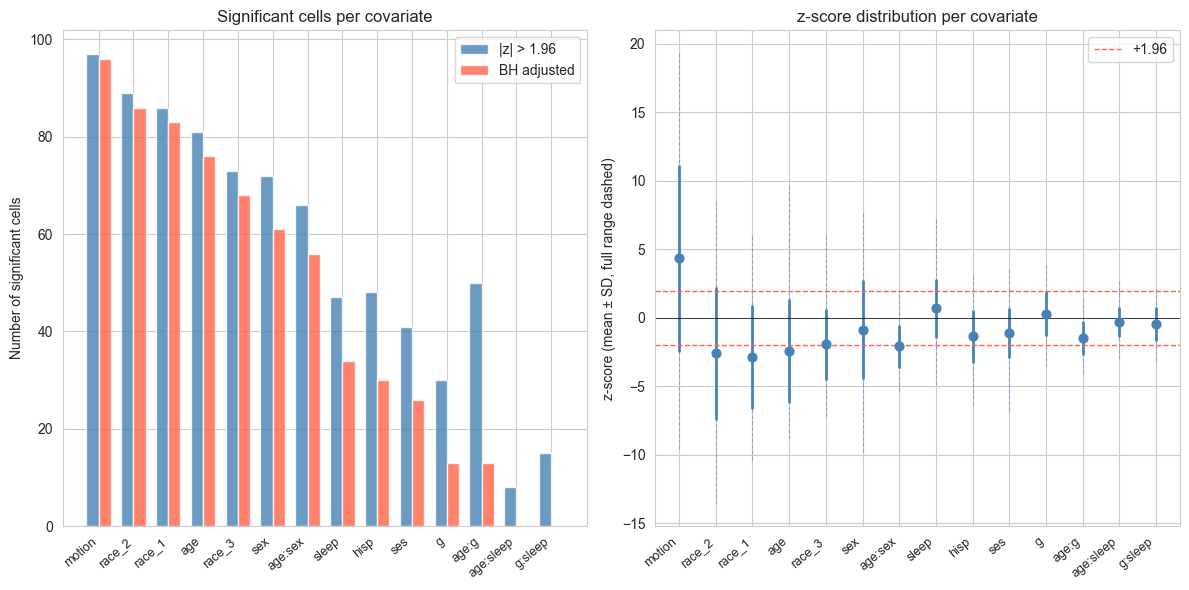

In [49]:
summary_df, all_diags = covariate_significance_summary(
    model_full_diag,
    cell_labels=cell_labels,   # or None
    z_threshold=1.96,
    adjust_method="BH",
    alpha=0.05,
    skip=("intercept",),
)

print(summary_df[["covariate", "sig_raw", "sig_adj", "pct_sig_adj", "z_absmax"]])

fig = plot_covariate_summary(summary_df)
fig.savefig("covariate_summary.png", dpi=150, bbox_inches="tight")

# Drill into any covariate you care about
all_diags["age:g"]["focus_z"]   # full z-score vector across cells

In [50]:
diag_full = model_full_diag.diagnostics(focus="age", cell_labels=cell_labels)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000059
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 81 / 120
  Adjusted significant cells (BH, alpha=0.05): 76 / 120

Top 5 age effects by |z-score|:
  Cell   1               ('SMhand', 'SMmouth'): age = +0.006060  SE = 0.000626  z = +9.68  p = 3.611e-22  p_adj = 4.333e-20  (304 edges)
  Cell 117 ('CinguloParietal', 'CinguloParietal'): age = +0.011714  SE = 0.001239  z = +9.46  p = 3.174e-21  p_adj = 1.904e-19  (10 edges)
  Cell 115           (None, 'CinguloParietal'): age = -0.001996  SE = 0.000226  z = -8.83  p = 1.092e-18  p_adj = 3.421e-17  (235 edges)
  Cell 102               ('VentralAttn', None): age = -0.001441  SE = 0.000163  z = -8.82  p = 1.140e-18  p_adj = 3.421e-17  (1081 edges)
  Cell  96               ('Subcortical', None): age = -0.000905  SE = 0.000104  z = -8.70  p = 3.427e-18  p_adj = 8.225e-17  (2538 edges)


## Block diagonal

In [51]:
model_block_full = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub,
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub,
    extra_covariates=np.column_stack([
        sleep_centered,
        motion_centered,
        g_centered,
        sexc,
        hisp_c,
        race_dummies_centered.to_numpy(),
        ses_centered,
        ]),
    global_covariates=Z_site_stacked,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=["sleep", "motion", "g", "sex", "hisp", "race_1", "race_2", "race_3", "ses"],
    global_covariate_names=site_cols,
    interaction_specs=[("age", "g"), ("age", "sex"), ("age", "sleep"), ("g", "sleep")],
    verbose=True,
    tol=1e-6,
)
model_block_full.fit()

Initializing...
  alpha range : [-0.1853, 0.4454]
  eta   range : [-0.2955, 0.6134]
  eta constraint: max|sum_c eta| = 3.11e-15
  V     range : [0.0011, 0.0429]
  d init      : 0.000000
  w check — diagonal: 25702662.148070, block: 25702662.148070, diff: 3.73e-09
  Iter   0: LL = 779723921.6690  (rel Δ = inf)
  Iter   1: LL = 779739014.5011  (rel Δ = 1.94e-05)
  Iter   2: LL = 779741921.3405  (rel Δ = 3.73e-06)
  Iter   3: LL = 779742773.9482  (rel Δ = 1.09e-06)
  Iter   4: LL = 779743091.3532  (rel Δ = 4.07e-07)
  Converged at iter 4 (rel Δ = 4.07e-07 < 1e-06)



DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 46 / 120
  Adjusted significant cells (BH, alpha=0.05): 32 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 age effects by |z-score|:
  Cell 117 ('CinguloParietal', 'CinguloParietal'): age = +0.011228  SE = 0.001244  z = +9.03  p = 1.745e-19  p_adj = 2.094e-17  (10 edges)
  Cell  82 ('FrontoParietal', 'CinguloParietal'): age = -0.002274  SE = 0.000483  z = -4.70  p = 2.555e-06  p_adj = 1.533e-04  (120 edges)
  Cel

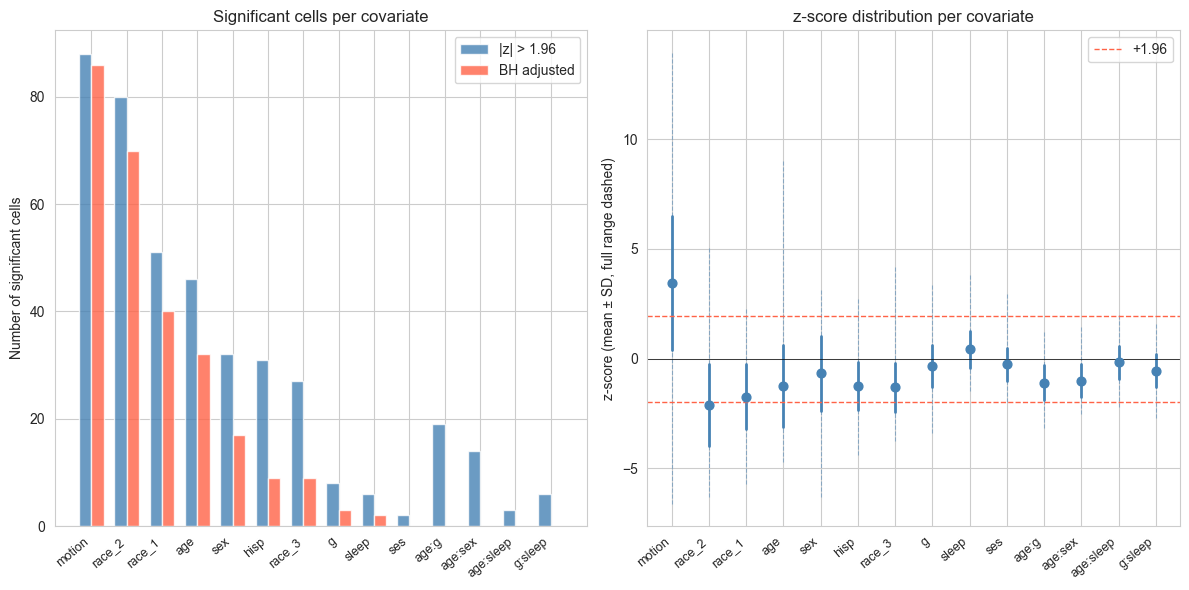

In [52]:
summary_df_block, all_diags_block = covariate_significance_summary(
    model_block_full,
    cell_labels=cell_labels,   # or None
    z_threshold=1.96,
    adjust_method="BH",
    alpha=0.05,
    skip=("intercept",),
)

print(summary_df_block[["covariate", "sig_raw", "sig_adj", "pct_sig_adj", "z_absmax"]])

fig = plot_covariate_summary(summary_df_block)
fig.savefig("covariate_summary.png", dpi=150, bbox_inches="tight")

# Drill into any covariate you care about
#all_diags_block["age:g"]["focus_z"]   # full z-score vector across cells

# Full covariates OLS

In [53]:
def cell_wise_ols_with_se(
    Y: np.ndarray,
    X: np.ndarray,
    subject_id: np.ndarray,
    cell_id_of_edge: np.ndarray,
    covariate_names: list[str] | None = None,
) -> dict:
    """
    Pooled OLS per cell with naive and subject-clustered standard errors.
    """
    N_obs, E = Y.shape
    p = X.shape[1]
    N_subjects = int(subject_id.max()) + 1
    C = int(cell_id_of_edge.max()) + 1

    if covariate_names is None:
        covariate_names = [f"x{j}" for j in range(p)]
    if len(covariate_names) != p:
        raise ValueError("len(covariate_names) must equal X.shape[1]")

    beta     = np.zeros((C, p))
    se_naive = np.zeros((C, p))
    se_clust = np.zeros((C, p))

    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)

    for c in range(C):
        edge_mask = (cell_id_of_edge == c)
        E_c = int(edge_mask.sum())
        if E_c == 0:
            continue

        Y_c = Y[:, edge_mask]                 # (N_obs, E_c)
        Y_c_sum = Y_c.sum(axis=1)             # (N_obs,)

        # OLS estimate
        XtX_c_inv = XtX_inv / E_c
        beta[c] = XtX_c_inv @ (X.T @ Y_c_sum)

        # Residuals
        Y_hat_c = X @ beta[c]                 # (N_obs,)
        residuals_c = Y_c - Y_hat_c[:, None]  # (N_obs, E_c)

        # Naive SE
        RSS_c = float(np.sum(residuals_c ** 2))
        df_naive = N_obs * E_c - p
        sigma2_c = RSS_c / df_naive
        se_naive[c] = np.sqrt(np.diag(sigma2_c * XtX_c_inv))

        # Clustered SE
        scores = X * residuals_c.sum(axis=1, keepdims=True)   # (N_obs, p)
        u = np.zeros((N_subjects, p))
        np.add.at(u, subject_id, scores)
        meat = u.T @ u
        var_clust_c = XtX_c_inv @ meat @ XtX_c_inv
        se_clust[c] = np.sqrt(np.diag(var_clust_c))

    return {
        "beta": beta,
        "se_naive": se_naive,
        "se_clust": se_clust,
        "covariate_names": covariate_names,
    }

# ---- Main effects ----
X_main = np.column_stack([
    np.ones(len(ages_centered_sub)),              # intercept
    ages_centered_sub,                            # age
    sleep_centered,
    motion_centered,
    g_centered,
    sexc,
    hisp_c,
    race_dummies_centered.to_numpy(),
    ses_centered,
    Z_site_stacked
])

ols_covariate_names = (
    ["intercept", "age", "sleep", "motion", "g", "sex", "hisp",
     "race_1", "race_2", "race_3", "ses"]
    + site_cols
)

# ---- Interaction terms matching interaction_specs ----
age_x_g     = ages_centered_sub * g_centered
age_x_sex   = ages_centered_sub * sexc
age_x_sleep = ages_centered_sub * sleep_centered
g_x_sleep   = g_centered * sleep_centered

X_interactions = np.column_stack([
    age_x_g,
    age_x_sex,
    age_x_sleep,
    g_x_sleep
])

interaction_names = [
    "age_x_g",
    "age_x_sex",
    "age_x_sleep",
    "g_x_sleep"
]

# ---- Full OLS design ----
X_full_matched = np.column_stack([X_main, X_interactions])
ols_covariate_names_matched = ols_covariate_names + interaction_names

# ---- Fit OLS ----
ols_full_matched = cell_wise_ols_with_se(
    Y=Y_stacked_sub,
    X=X_full_matched,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    covariate_names=ols_covariate_names_matched,
)

In [54]:
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# use the matched OLS object
age_idx = ols_full_matched["covariate_names"].index("age")

beta_age_full = ols_full_matched["beta"][:, age_idx]
se_age_naive_full = ols_full_matched["se_naive"][:, age_idx]
se_age_clust_full = ols_full_matched["se_clust"][:, age_idx]

# z/t style statistics
t_naive_full = beta_age_full / se_age_naive_full
t_clust_full = beta_age_full / se_age_clust_full

# two-sided p-values
p_naive_full = 2 * norm.sf(np.abs(t_naive_full))
p_clust_full = 2 * norm.sf(np.abs(t_clust_full))

# BH correction
reject_naive_bh_full, p_naive_bh_full, _, _ = multipletests(
    p_naive_full,
    alpha=0.05,
    method="fdr_bh"
)

reject_clust_bh_full, p_clust_bh_full, _, _ = multipletests(
    p_clust_full,
    alpha=0.05,
    method="fdr_bh"
)

# BH correction

In [55]:
#OLS full-model corrections
def ols_multiple_testing_summary(
    ols_result,
    se_type="clust",
    alpha=0.05,
    skip=("intercept",),
):
    beta = ols_result["beta"]   # (120, p)
    covariate_names = ols_result["covariate_names"]

    if se_type == "clust":
        se = ols_result["se_clust"]
    elif se_type == "naive":
        se = ols_result["se_naive"]
    else:
        raise ValueError("se_type must be 'clust' or 'naive'")

    z = beta / se
    p_raw = 2 * norm.sf(np.abs(z))

    selected_idx = [j for j, name in enumerate(covariate_names) if name not in skip]

    # within-covariate BH
    by_cov = {}
    for j in selected_idx:
        reject, p_adj, _, _ = multipletests(p_raw[:, j], alpha=alpha, method="fdr_bh")
        by_cov[covariate_names[j]] = {
            "z": z[:, j],
            "p_raw": p_raw[:, j],
            "p_adj_within": p_adj,
            "reject_within": reject,
        }

    # global BH across all selected coefficients
    p_all = np.concatenate([p_raw[:, j] for j in selected_idx])
    reject_all, p_all_adj, _, _ = multipletests(p_all, alpha=alpha, method="fdr_bh")

    by_cov_global = {}
    start = 0
    for j in selected_idx:
        end = start + beta.shape[0]
        by_cov_global[covariate_names[j]] = {
            "p_adj_global": p_all_adj[start:end],
            "reject_global": reject_all[start:end],
        }
        start = end

    return by_cov, by_cov_global

In [60]:
import pandas as pd

def global_bh_from_all_diags(
    all_diags,
    alpha=0.05,
    skip=("intercept",),
):
    covariates = [cov for cov in all_diags.keys() if cov not in skip]

    pvals_list = []
    n_cells_by_cov = {}

    for cov in covariates:
        p = np.asarray(all_diags[cov]["focus_p_raw"])
        pvals_list.append(p)
        n_cells_by_cov[cov] = len(p)

    p_all = np.concatenate(pvals_list)

    reject_all, p_all_adj, _, _ = multipletests(
        p_all,
        alpha=alpha,
        method="fdr_bh"
    )

    global_results = {}
    rows = []

    start = 0
    for cov in covariates:
        n = n_cells_by_cov[cov]
        end = start + n

        reject_global = reject_all[start:end]
        p_adj_global = p_all_adj[start:end]

        global_results[cov] = {
            "reject_global": reject_global,
            "p_adj_global": p_adj_global,
        }

        rows.append({
            "covariate": cov,
            "sig_within": int(np.sum(all_diags[cov]["focus_sig_adj"])),
            "sig_global_bh": int(np.sum(reject_global)),
            "lost_global": int(np.sum(all_diags[cov]["focus_sig_adj"] & ~reject_global)),
            "z_absmax": float(np.max(np.abs(all_diags[cov]["focus_z"]))),
        })

        start = end

    summary_global = pd.DataFrame(rows).sort_values(
        ["sig_within", "sig_global_bh"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return summary_global, global_results

In [61]:
ols_naive_by_cov, ols_naive_global = ols_multiple_testing_summary(
    ols_full_matched,
    se_type="naive",
    alpha=0.05,
    skip=("intercept",),
)

ols_clust_by_cov, ols_clust_global = ols_multiple_testing_summary(
    ols_full_matched,
    se_type="clust",
    alpha=0.05,
    skip=("intercept",),
)

In [62]:
summary_df_diag, all_diags_diag = covariate_significance_summary(
    model_full_diag,
    cell_labels=cell_labels,
    z_threshold=1.96,
    adjust_method="BH",
    alpha=0.05,
    skip=("intercept",),
)

summary_global_diag, global_diags_diag = global_bh_from_all_diags(
    all_diags_diag,
    alpha=0.05,
    skip=("intercept",),
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000059
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 81 / 120
  Adjusted significant cells (BH, alpha=0.05): 76 / 120

Top 5 age effects by |z-score|:
  Cell   1               ('SMhand', 'SMmouth'): age = +0.006060  SE = 0.000626  z = +9.68  p = 3.611e-22  p_adj = 4.333e-20  (304 edges)
  Cell 117 ('CinguloParietal', 'CinguloParietal'): age = +0.011714  SE = 0.001239  z = +9.46  p = 3.174e-21  p_adj = 1.904e-19  (10 edges)
  Cell 115           (None, 'CinguloParietal'): age = -0.001996  SE = 0.000226  z = -8.83  p = 1.092e-18  p_adj = 3.421e-17  (235 edges)
  Cell 102               ('VentralAttn', None): age = -0.001441  SE = 0.000163  z = -8.82  p = 1.140e-18  p_adj = 3.421e-17  (1081 edges)
  Cell  96               ('Subcortical', None): age = -0.000905  SE = 0.000104  z = -8.70  p = 3.427e-18  p_adj = 8.225e-17  (2538 edges)

DIAGNOSTICS  (120 cells, 87153 edges, 2

In [153]:
summary_df_block, all_diags_block = covariate_significance_summary(
    model_block_full,
    cell_labels=cell_labels,
    z_threshold=1.96,
    adjust_method="BH",
    alpha=0.05,
    skip=("intercept",),
)

summary_global_block, global_diags_block = global_bh_from_all_diags(
    all_diags_block,
    alpha=0.05,
    skip=("intercept",),
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'age' (column 1)
  Raw significant cells at |z| > 1.96: 46 / 120
  Adjusted significant cells (BH, alpha=0.05): 32 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 age effects by |z-score|:
  Cell 117 ('CinguloParietal', 'CinguloParietal'): age = +0.011228  SE = 0.001244  z = +9.03  p = 1.745e-19  p_adj = 2.094e-17  (10 edges)
  Cell  82 ('FrontoParietal', 'CinguloParietal'): age = -0.002274  SE = 0.000483  z = -4.70  p = 2.555e-06  p_adj = 1.533e-04  (120 edges)
  Cel

In [64]:
print(summary_global_diag.columns.tolist())
print(summary_global_block.columns.tolist())

['covariate', 'sig_within', 'sig_global_bh', 'lost_global', 'z_absmax']
['covariate', 'sig_within', 'sig_global_bh', 'lost_global', 'z_absmax']


In [65]:
age_ols_naive_within = ols_naive_by_cov["age"]["reject_within"].sum()
age_ols_naive_global = ols_naive_global["age"]["reject_global"].sum()

age_ols_clust_within = ols_clust_by_cov["age"]["reject_within"].sum()
age_ols_clust_global = ols_clust_global["age"]["reject_global"].sum()

age_diag_within = summary_df_diag.loc[
    summary_df_diag["covariate"] == "age", "sig_adj"
].iloc[0]
age_diag_global = summary_global_diag.loc[
    summary_global_diag["covariate"] == "age", "sig_global_bh"
].iloc[0]

age_block_within = summary_df_block.loc[
    summary_df_block["covariate"] == "age", "sig_adj"
].iloc[0]
age_block_global = summary_global_block.loc[
    summary_global_block["covariate"] == "age", "sig_global_bh"
].iloc[0]

print("OLS naive:     ", age_ols_naive_within, age_ols_naive_global)
print("OLS clustered: ", age_ols_clust_within, age_ols_clust_global)
print("Graph diag:    ", age_diag_within, age_diag_global)
print("Graph block:   ", age_block_within, age_block_global)

OLS naive:      112 112
OLS clustered:  67 62
Graph diag:     76 73
Graph block:    32 27


# Goodness of fit

In [38]:
from sklearn.model_selection import KFold

def kfold_prediction_frobenius(
    model_class,
    model_kwargs: dict,
    Y: np.ndarray,
    age: np.ndarray,
    subject_id: np.ndarray,
    cell_id_of_edge: np.ndarray,
    edges_per_cell: list,
    n_splits: int = 5,
    random_state: int = 42,
    fit_kwargs: dict | None = None,
    model_name: str = "Model",
) -> dict:
    """
    K-fold subject-level CV using normalized Frobenius prediction error.

    For held-out subjects, predictions use only parameters estimated from
    training subjects. For RI / block models, the unseen subject random
    intercept is set to 0 (prior mean).

    Returned metric:
        frob_rmse = ||Y_test - Yhat_test||_F / sqrt(n_test_obs * E)

    This is comparable across folds and models.
    """
    if fit_kwargs is None:
        fit_kwargs = {}

    C = len(edges_per_cell)
    E = Y.shape[1]
    N_subjects = int(subject_id.max()) + 1
    subjects = np.arange(N_subjects)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    frob_per_fold = np.zeros(n_splits)
    mse_per_fold = np.zeros(n_splits)

    for fold, (train_subj, test_subj) in enumerate(kf.split(subjects)):
        train_mask = np.isin(subject_id, train_subj)
        test_mask  = np.isin(subject_id, test_subj)

        Y_train   = Y[train_mask]
        age_train = age[train_mask]
        sid_train = subject_id[train_mask]

        Y_test    = Y[test_mask]
        age_test  = age[test_mask]

        X_test = np.column_stack([np.ones(len(age_test)), age_test])

        # ---- fit on training data ----
        if model_class is None:
            # OLS on cell means; edge-level prediction is constant within cell
            X_train = np.column_stack([np.ones(len(age_train)), age_train])
            XtX_inv = np.linalg.inv(X_train.T @ X_train)

            alpha_hat = np.zeros((C, 2))
            eta_hat   = np.zeros(E)   # no edge-specific deviation in OLS branch

            for c, eidx in enumerate(edges_per_cell):
                if len(eidx) == 0:
                    continue
                Y_mean = Y_train[:, eidx].mean(axis=1)
                alpha_hat[c] = XtX_inv @ (X_train.T @ Y_mean)

        else:
            _, sid_train_remapped = np.unique(sid_train, return_inverse=True)

            kwargs = dict(model_kwargs)
            kwargs.update({
                "Y": Y_train,
                "age": age_train,
                "subject_id": sid_train_remapped,
                "cell_id_of_edge": cell_id_of_edge,
                "edges_per_cell": edges_per_cell,
                "verbose": False,
            })
            model = model_class(**kwargs)
            model.fit(**fit_kwargs)

            alpha_hat = model.alpha
            eta_hat   = model.eta

        # ---- predict held-out subjects with gamma = 0 ----
        Yhat_test = np.zeros_like(Y_test)
        for c, eidx in enumerate(edges_per_cell):
            if len(eidx) == 0:
                continue
            mu_c = (X_test @ alpha_hat[c])[:, None] + eta_hat[eidx][None, :]
            Yhat_test[:, eidx] = mu_c

        resid = Y_test - Yhat_test

        frob = np.linalg.norm(resid, ord="fro")
        frob_rmse = frob / np.sqrt(Y_test.shape[0] * Y_test.shape[1])
        mse = np.mean(resid**2)

        frob_per_fold[fold] = frob_rmse
        mse_per_fold[fold] = mse

        print(
            f"{model_name} fold {fold+1}/{n_splits}: "
            f"Frobenius-RMSE = {frob_rmse:.6f}, MSE = {mse:.6f}"
        )

    print(f"\n=== {model_name}: Held-out prediction error ===")
    print(f"  Mean Frobenius-RMSE : {np.mean(frob_per_fold):.6f}")
    print(f"  SD   Frobenius-RMSE : {np.std(frob_per_fold, ddof=1):.6f}")
    print(f"  Mean MSE            : {np.mean(mse_per_fold):.6f}")

    return {
        "frob_per_fold": frob_per_fold,
        "frob_mean": float(np.mean(frob_per_fold)),
        "frob_sd": float(np.std(frob_per_fold, ddof=1)),
        "mse_per_fold": mse_per_fold,
        "mse_mean": float(np.mean(mse_per_fold)),
    }

In [39]:
RANDOM_STATE = 2205
N_SPLITS = 5

print("=== OLS (Models 1 & 2) ===")
frob_ols = kfold_prediction_frobenius(
    model_class=None,
    model_kwargs={},
    Y=Y_stacked_sub,
    age=ages_raw_stacked_sub,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    model_name="OLS",
)

print("\n=== Model 3: Random Intercept ===")
frob_ri = kfold_prediction_frobenius(
    model_class=LongitudinalGraphAwareEM_RI_cell,
    model_kwargs={},
    Y=Y_stacked_sub,
    age=ages_raw_stacked_sub,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    model_name="RI",
)

print("\n=== Model 4: Block-V ===")
frob_blockv = kfold_prediction_frobenius(
    model_class=LongitudinalGraphAwareEM_RI_BlockV_cell,
    model_kwargs={
        "edge_to_roi": edge_to_roi,
        "roi_to_network": roi_to_network,
        "cells": cells,
    },
    Y=Y_stacked_sub,
    age=ages_raw_stacked_sub,
    subject_id=subject_id_sub,
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    model_name="Block-V",
)

print("\n=== Held-out Prediction Error Summary ===")
print(
    f"OLS (M1 & M2) : Frobenius-RMSE = {frob_ols['frob_mean']:.6f}  "
    f"MSE = {frob_ols['mse_mean']:.6f}  "
    f"folds: {np.round(frob_ols['frob_per_fold'], 6)}"
)
print(
    f"RI  (M3)      : Frobenius-RMSE = {frob_ri['frob_mean']:.6f}  "
    f"MSE = {frob_ri['mse_mean']:.6f}  "
    f"folds: {np.round(frob_ri['frob_per_fold'], 6)}"
)
print(
    f"Block-V (M4)  : Frobenius-RMSE = {frob_blockv['frob_mean']:.6f}  "
    f"MSE = {frob_blockv['mse_mean']:.6f}  "
    f"folds: {np.round(frob_blockv['frob_per_fold'], 6)}"
)

=== OLS (Models 1 & 2) ===
OLS fold 1/5: Frobenius-RMSE = 0.087423, MSE = 0.007643
OLS fold 2/5: Frobenius-RMSE = 0.086888, MSE = 0.007550
OLS fold 3/5: Frobenius-RMSE = 0.086825, MSE = 0.007539
OLS fold 4/5: Frobenius-RMSE = 0.086794, MSE = 0.007533
OLS fold 5/5: Frobenius-RMSE = 0.087951, MSE = 0.007735

=== OLS: Held-out prediction error ===
  Mean Frobenius-RMSE : 0.087176
  SD   Frobenius-RMSE : 0.000503
  Mean MSE            : 0.007600

=== Model 3: Random Intercept ===
RI fold 1/5: Frobenius-RMSE = 0.073303, MSE = 0.005373
RI fold 2/5: Frobenius-RMSE = 0.072970, MSE = 0.005325
RI fold 3/5: Frobenius-RMSE = 0.073056, MSE = 0.005337
RI fold 4/5: Frobenius-RMSE = 0.073016, MSE = 0.005331
RI fold 5/5: Frobenius-RMSE = 0.074589, MSE = 0.005563

=== RI: Held-out prediction error ===
  Mean Frobenius-RMSE : 0.073387
  SD   Frobenius-RMSE : 0.000684
  Mean MSE            : 0.005386

=== Model 4: Block-V ===
Block-V fold 1/5: Frobenius-RMSE = 0.073313, MSE = 0.005375
Block-V fold 2/5: Fr

# PLOTS PLOTS PLOTS

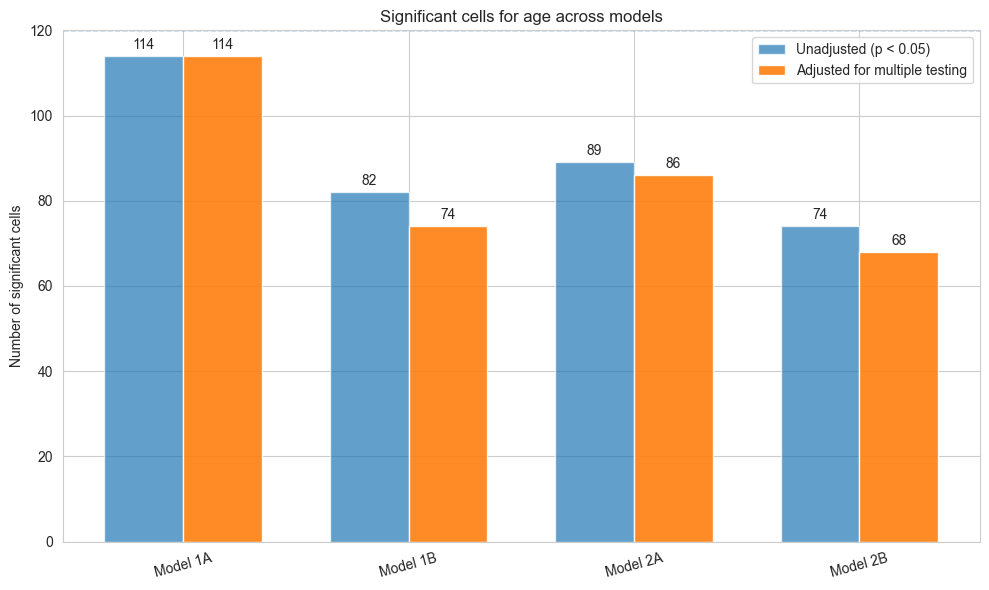

In [11]:
import matplotlib.pyplot as plt
# significant cells counts for all 4 methods: raw and corrected
methods = ["Model 1A", "Model 1B", "Model 2A", "Model 2B"]
raw = [114, 82, 89, 74]
bh  = [114, 74, 86, 68]

x = np.arange(len(methods))
width = 0.35

# Plot
plt.figure(figsize=(10, 6))

#bars_raw = plt.bar(x - width/2, raw, width, alpha=0.7, label='Raw (p < 0.05)')
#bars_bh  = plt.bar(x + width/2, bh,  width, alpha=0.9,label='BH-corrected (FDR 0.05)')
bars_raw = plt.bar(x - width/2, raw, width, alpha=0.7, label='Unadjusted (p < 0.05)')
bars_bh  = plt.bar(x + width/2, bh,  width, alpha=0.9,label='Adjusted for multiple testing')

# Labels & title
plt.ylabel("Number of significant cells")
plt.title("Significant cells for age across models"),
plt.xticks(x, methods, rotation=15)
plt.ylim(0, 120)

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

add_labels(bars_raw)
add_labels(bars_bh)

# Legend
plt.legend()

# Optional: horizontal reference line
plt.axhline(120, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

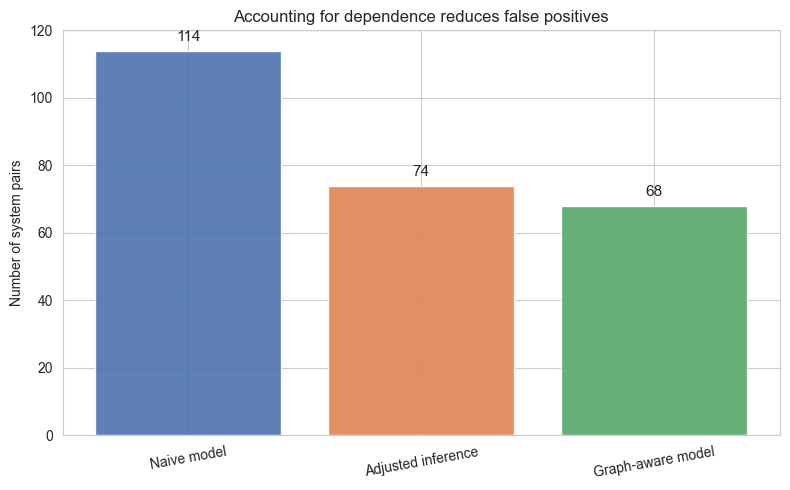

In [129]:
import numpy as np
import matplotlib.pyplot as plt

# Clean 3-step story
methods = ["Naive model", "Adjusted inference", "Graph-aware model"]

# Use only adjusted counts (your BH numbers)
values = [114, 74, 68]

x = np.arange(len(methods))

plt.figure(figsize=(8, 5))

# Colors: progression
colors = ["#4C72B0", "#DD8452", "#55A868"]  # blue, orange, green

bars = plt.bar(x, values, color=colors, alpha=0.9)

# Labels & title
plt.ylabel("Number of system pairs")
plt.title("Accounting for dependence reduces false positives")

plt.xticks(x, methods, rotation=10)
plt.ylim(0, 120)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Optional: subtle reference line
plt.axhline(120, linestyle='--', linewidth=1, alpha=0.4)

plt.tight_layout()
plt.show()

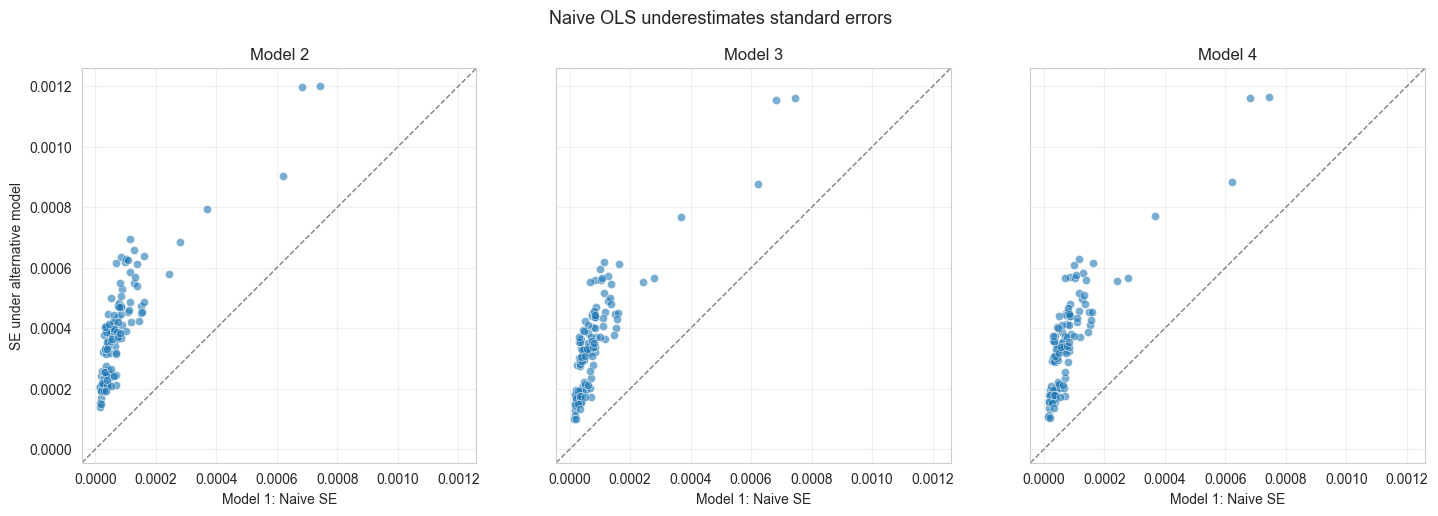

In [130]:
"""
Three-panel scatter plot comparing SEs across models.
Each panel shows Model 1 (Naive OLS) vs. one of Models 2/3/4 on shared axes.

Assumes you have these arrays already defined (one SE per cell, length 120):
  se_naive_alpha1   # Model 1: Naive pooled OLS
  se_clust_alpha1   # Model 2: OLS + clustered SE
  se_ri_alpha1      # Model 3: Random intercept (edge + subject)
  se_block_0        # Model 4: RI + block V (graph-aware)
"""

se_ri_0 = diag_0["focus_se"]
se_block_0 = diag_block_0["focus_se"]

# ---- panels: (y-array, y-label for subplot title) ----
panels = [
    (se_clust_alpha1, "Model 2"),
    (se_ri_0,    "Model 3"),
    (se_block_0,      "Model 4"),
]

# shared axis limits across all three panels so points are visually comparable
all_ses = np.concatenate([se_naive_alpha1] + [p[0] for p in panels])
lo, hi = all_ses.min(), all_ses.max()
pad = 0.05 * (hi - lo)
lim = (lo - pad, hi + pad)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, (y, title) in zip(axes, panels):
    ax.scatter(se_naive_alpha1, y, alpha=0.6, s=35, edgecolor="white", linewidth=0.5)
    ax.plot(lim, lim, linestyle="--", color="gray", linewidth=1)  # y = x reference
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect("equal")
    ax.set_xlabel("Model 1: Naive SE")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("SE under alternative model")

fig.suptitle(
    "Naive OLS underestimates standard errors\n",
    #"(points above y = x have larger SEs once dependence is accounted for)",
    fontsize=13,
)

plt.tight_layout()
plt.savefig("se_three_panel.png", dpi=200, bbox_inches="tight")
plt.show()

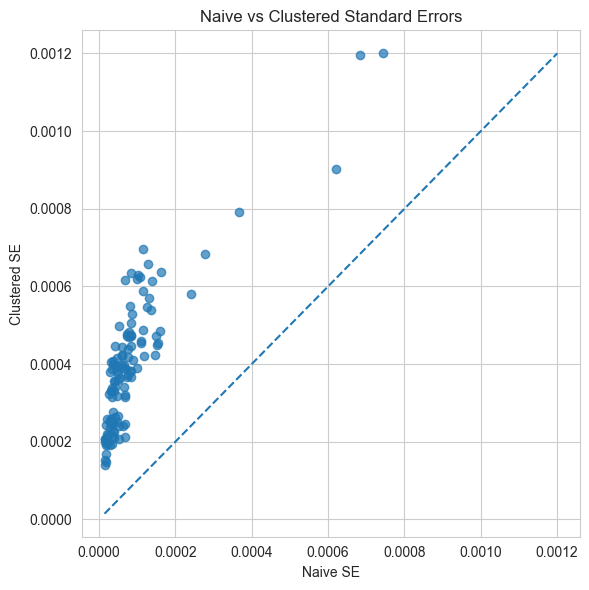

In [132]:
# scatter plot Naive vs Clustered
plt.figure(figsize=(6, 6))

plt.scatter(se_naive_alpha1, se_clust_alpha1, alpha=0.7)

# diagonal
min_val = min(se_naive_alpha1.min(), se_clust_alpha1.min())
max_val = max(se_naive_alpha1.max(), se_clust_alpha1.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Naive SE")
plt.ylabel("Clustered SE")
plt.title("Naive vs Clustered Standard Errors")

plt.tight_layout()
plt.show()

In [133]:
se_ri_0 = diag_0["focus_se"]
se_block_0 = block_diag_0["focus_se"]

In [134]:
se_ratio_ri_vs_clust = se_ri_0 / se_clust_alpha1

print("RI / clustered SE ratio:")
print(f"Mean:   {se_ratio_ri_vs_clust.mean():.2f}")
print(f"Median: {np.median(se_ratio_ri_vs_clust):.2f}")
print(f"Min:    {se_ratio_ri_vs_clust.min():.2f}")
print(f"Max:    {se_ratio_ri_vs_clust.max():.2f}")

RI / clustered SE ratio:
Mean:   0.85
Median: 0.87
Min:    0.60
Max:    0.97


In [135]:
se_ratio_block_vs_diag = se_block_0 / se_ri_0

print("Block / diag SE ratio:")
print(f"Mean:   {se_ratio_block_vs_diag.mean():.2f}")
print(f"Median: {np.median(se_ratio_block_vs_diag):.2f}")
print(f"Min:    {se_ratio_block_vs_diag.min():.2f}")
print(f"Max:    {se_ratio_block_vs_diag.max():.2f}")

Block / diag SE ratio:
Mean:   1.02
Median: 1.02
Min:    0.98
Max:    1.08


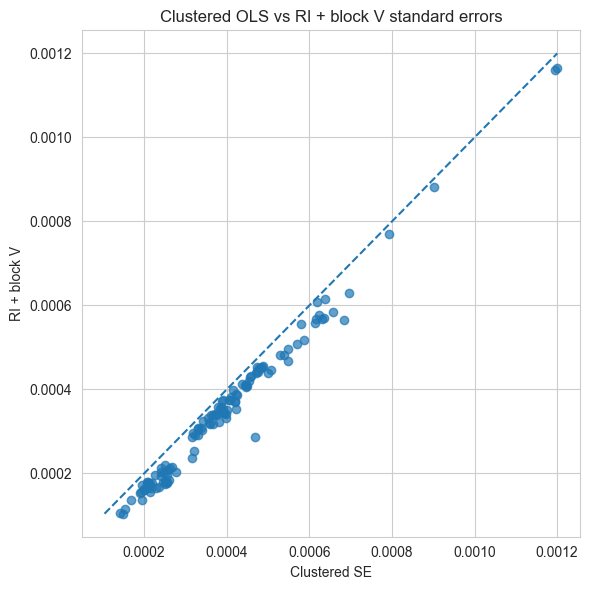

In [131]:
# scatter plot Clustered vs Block -V
plt.figure(figsize=(6, 6))

plt.scatter(se_clust_alpha1, se_block_0, alpha=0.7)

# diagonal
min_val = min(se_clust_alpha1.min(), se_block_0.min())
max_val = max(se_clust_alpha1.max(), se_block_0.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Clustered SE")
plt.ylabel("RI + block V")
plt.title("Clustered OLS vs RI + block V standard errors")

plt.tight_layout()
plt.show()

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
se_ri_0 = diag_0["focus_se"]
def plot_network_matrix(matrix, network_order, community_sizes, title="", save_path=None, dpi=300):
    """
    Plots a connectivity matrix with network labels using consistent coloring.
    """
    plt.figure(figsize=(12, 10))

    cmap = sns.diverging_palette(220, 20, as_cmap=True, center="light")

    max_val = np.nanmax(np.abs(matrix))
    vmin, vmax = -max_val, max_val

    ax = sns.heatmap(matrix, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
                     square=True, cbar_kws={'label': r'$\hat{\alpha}_1$ (Age Effect)'},
                     xticklabels=False, yticklabels=False)

    cum_sizes = np.cumsum([0] + community_sizes)
    for boundary in cum_sizes[1:-1]:
        ax.axvline(x=boundary, color='white', lw=2)
        ax.axhline(y=boundary, color='white', lw=2)

    tick_positions = [(cum_sizes[i] + cum_sizes[i + 1]) / 2 for i in range(len(community_sizes))]
    plt.xticks(tick_positions, network_order, rotation=90)
    plt.yticks(tick_positions, network_order)

    plt.title(title, fontsize=14)
    plt.xlabel("Brain Systems")
    plt.ylabel("Brain Systems")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', format='png')
        print(f"Saved to: {save_path}")

    plt.show()

In [134]:
def expand_to_block_matrix(cell_matrix, system_sizes):
    K_mat = cell_matrix.shape[0]
    if cell_matrix.shape[0] != cell_matrix.shape[1]:
        raise ValueError("cell_matrix must be square")
    if len(system_sizes) != K_mat:
        raise ValueError(
            f"Mismatch: cell_matrix is {K_mat}x{K_mat}, "
            f"but system_sizes has length {len(system_sizes)}"
        )

    total = sum(system_sizes)
    expanded = np.zeros((total, total))

    row_start = 0
    for i in range(K_mat):
        size_i = system_sizes[i]
        col_start = 0
        for j in range(K_mat):
            size_j = system_sizes[j]
            expanded[
                row_start:row_start + size_i,
                col_start:col_start + size_j
            ] = cell_matrix[i, j]
            col_start += size_j
        row_start += size_i

    return expanded

In [135]:
focus_cov = "age"

z_scores = all_diags_block[focus_cov]["focus_z"]
sig_global = global_diags_block[focus_cov]["reject_global"]

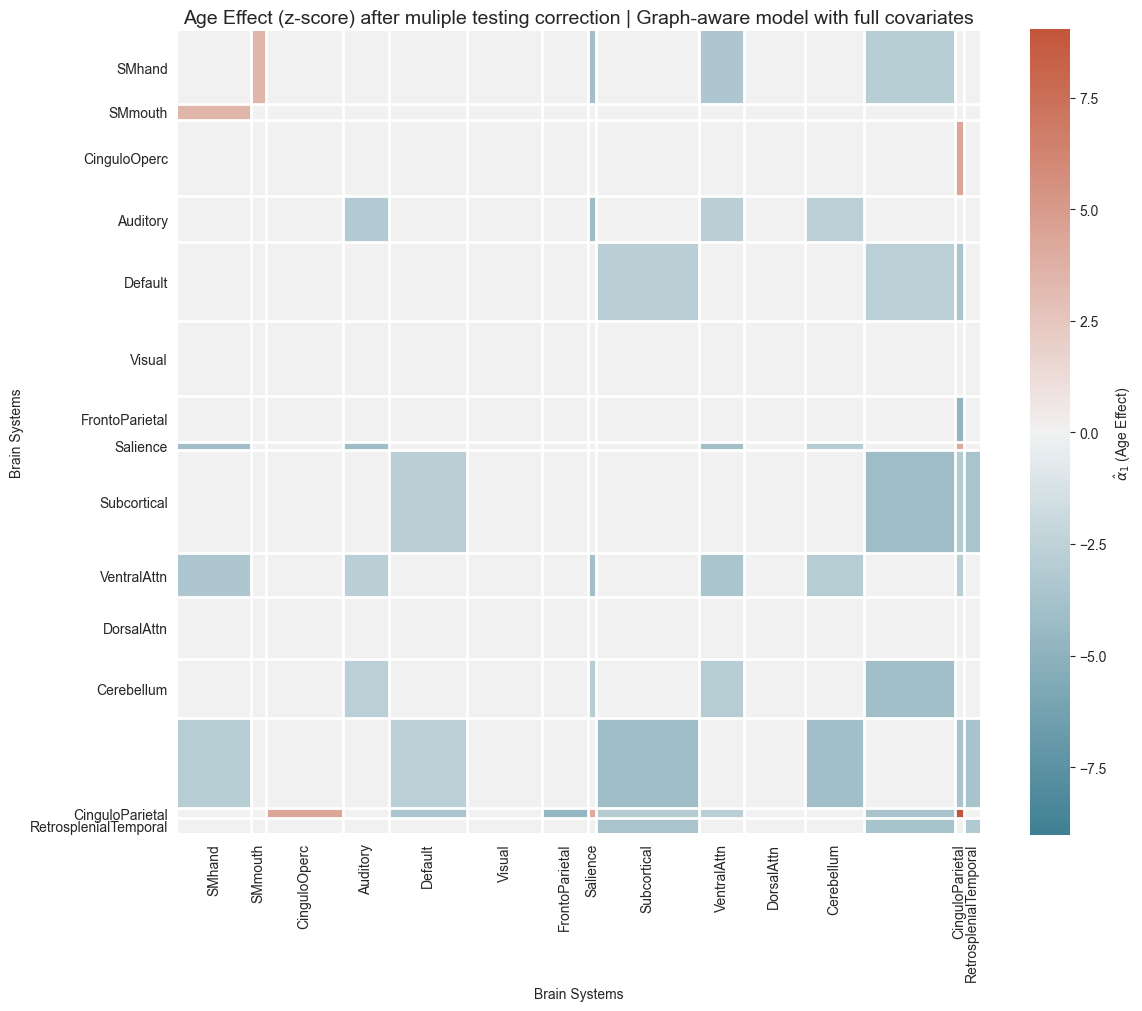

In [143]:
system_size_map = {
    "SMhand": 38,
    "SMmouth": 8,
    "CinguloOperc": 40,
    "Auditory": 24,
    "Default": 41,
    "Visual": 39,
    "FrontoParietal": 24,
    "Salience": 4,
    "Subcortical": 54,
    "VentralAttn": 23,
    "DorsalAttn": 32,
    "Cerebellum": 31,
    None: 47,
    "CinguloParietal": 5,
    "RetrosplenialTemporal": 8,
}
# ── 1. Build the 16×16 z-score matrix ────────────────────────────
# K = len(network_order)
# name_to_idx = {name: i for i, name in enumerate(network_order)}
#
# z_matrix   = np.full((K, K), np.nan)
# sig_matrix = np.zeros((K, K), dtype=bool)
#
# z_scores = block_diag_full["focus_z"]
# sig_adj  = block_diag_full["focus_sig_adj"]
#
# for c, (net_a, net_b) in enumerate(cell_labels):
#     i = name_to_idx[net_a]
#     j = name_to_idx[net_b]
#     z_matrix[i, j]   = z_scores[c]
#     z_matrix[j, i]   = z_scores[c]   # symmetric
#     sig_matrix[i, j] = sig_adj[c]
#     sig_matrix[j, i] = sig_adj[c]
#
# system_sizes = [system_size_map[name] for name in network_order]
# z_plot = z_matrix.copy()
# z_plot[~sig_matrix] = 0.0
# ── Build z-score matrix using GLOBAL BH significance ─────────────

focus_cov = "age"

K = len(network_order)
name_to_idx = {name: i for i, name in enumerate(network_order)}

z_matrix = np.full((K, K), np.nan)
sig_matrix = np.zeros((K, K), dtype=bool)

z_scores = np.asarray(all_diags_block[focus_cov]["focus_z"])
sig_adj_global = np.asarray(
    global_diags_block[focus_cov]["reject_global"],
    dtype=bool
)

for c, (net_a, net_b) in enumerate(cell_labels):
    i = name_to_idx[net_a]
    j = name_to_idx[net_b]

    z_matrix[i, j] = z_scores[c]
    z_matrix[j, i] = z_scores[c]

    sig_matrix[i, j] = sig_adj_global[c]
    sig_matrix[j, i] = sig_adj_global[c]

system_sizes = [system_size_map[name] for name in network_order]

z_plot = z_matrix.copy()
z_plot[~sig_matrix] = 0.0

z_expanded = expand_to_block_matrix(z_plot, system_sizes)

plot_network_matrix(
    matrix=z_expanded,
    network_order=network_order,
    community_sizes=system_sizes,
    title=(
        #"Age Effect (z-score), Global BH-corrected FDR 0.05 | "
        "Age Effect (z-score) after muliple testing correction | "
        "Graph-aware model with full covariates"
        #"Model full covariates"
    ),
)

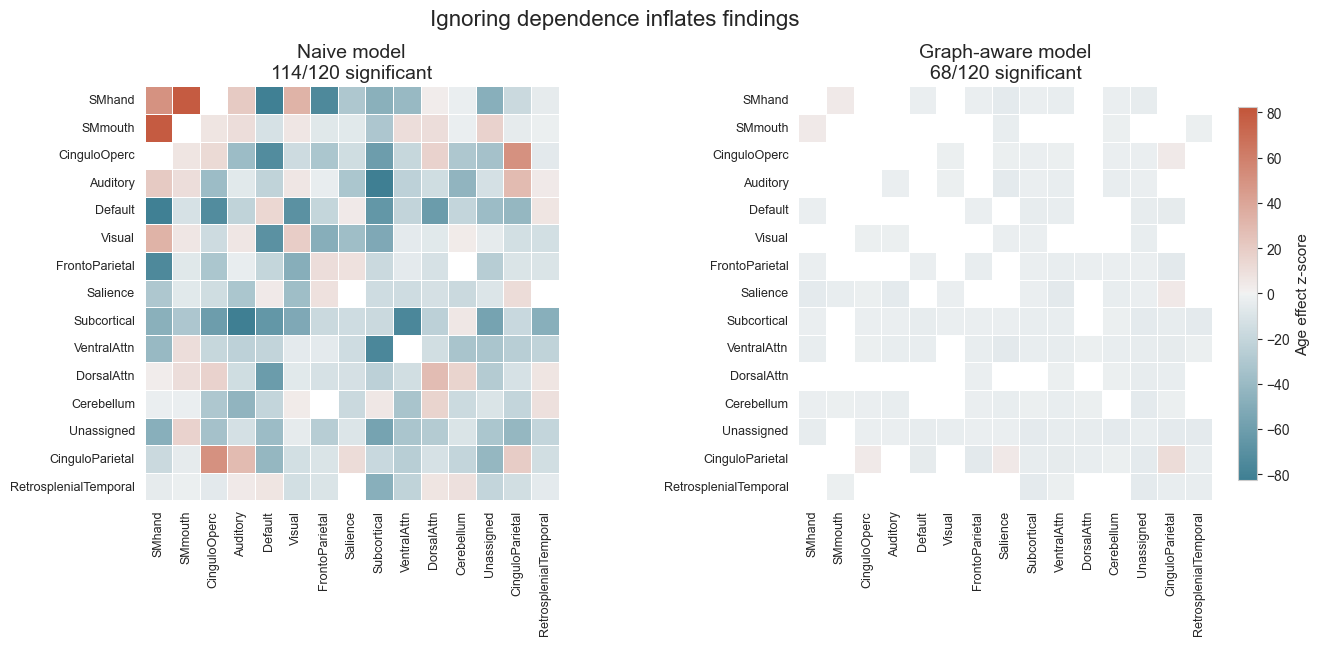

In [142]:
def clean_label(x):
    return "Unassigned" if x is None else x


focus_cov = "age"

network_order_plot = [clean_label(x) for x in network_order]
cell_labels_plot = [(clean_label(a), clean_label(b)) for a, b in cell_labels]


def build_system_matrix(values, sig_mask, cell_labels_plot, network_order_plot, nonsig_value=np.nan):
    K = len(network_order_plot)
    name_to_idx = {name: i for i, name in enumerate(network_order_plot)}

    mat = np.full((K, K), np.nan)
    sig = np.zeros((K, K), dtype=bool)

    for c, (net_a, net_b) in enumerate(cell_labels_plot):
        i = name_to_idx[net_a]
        j = name_to_idx[net_b]

        mat[i, j] = values[c]
        mat[j, i] = values[c]

        sig[i, j] = sig_mask[c]
        sig[j, i] = sig_mask[c]

    out = mat.copy()
    out[~sig] = nonsig_value
    return out


# --- Inputs ---
naive_values = np.asarray(t_naive)
naive_sig = np.asarray(reject_naive_bh, dtype=bool)

graph_values = np.asarray(diag_block_0["focus_z"])
graph_sig = np.asarray(diag_block_0["focus_sig_adj"], dtype=bool)


# --- Build matrices ---
naive_mat = build_system_matrix(
    values=naive_values,
    sig_mask=naive_sig,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
)

graph_mat = build_system_matrix(
    values=graph_values,
    sig_mask=graph_sig,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
)


# ---- Common color scale based on significant cells in both plots ----
all_vals = np.concatenate([
    naive_mat[~np.isnan(naive_mat)],
    graph_mat[~np.isnan(graph_mat)]
])

vmax = np.max(np.abs(all_vals)) if len(all_vals) > 0 else 1.0
vmin = -vmax


# ---- Colormap ----
cmap = sns.diverging_palette(220, 20, as_cmap=True)
cmap.set_bad(color="white")


# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

panels = [
    (
        axes[0],
        naive_mat,
        "Naive model",
        f"{naive_sig.sum()}/120 significant"
    ),
    (
        axes[1],
        graph_mat,
        "Graph-aware model",
        f"{graph_sig.sum()}/120 significant"
    ),
]

for ax, mat, title, subtitle in panels:
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=0,
        square=True,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=network_order_plot,
        yticklabels=network_order_plot,
    )

    ax.set_title(f"{title}\n{subtitle}", fontsize=14)
    ax.tick_params(axis="x", rotation=90, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")


# ---- Shared colorbar ----
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("Age effect z-score", fontsize=11)

fig.suptitle(
    "Ignoring dependence inflates findings",
    fontsize=16,
    y=1.05
)

plt.show()

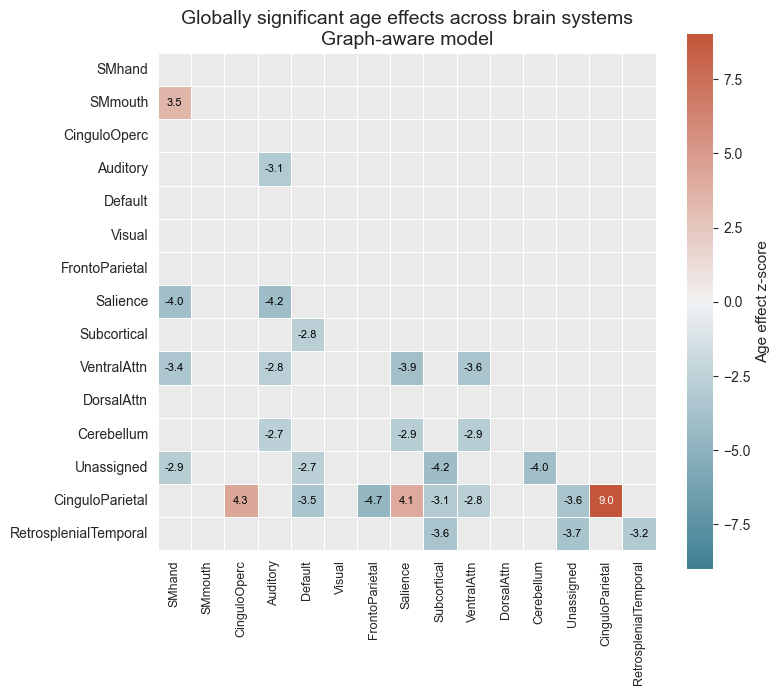

In [159]:
def clean_label(x):
    return "Unassigned" if x is None else x

focus_cov = "age"

network_order_plot = [clean_label(x) for x in network_order]
cell_labels_plot = [(clean_label(a), clean_label(b)) for a, b in cell_labels]


def build_system_matrix(values, sig_mask, cell_labels_plot, network_order_plot, nonsig_value=np.nan):
    K = len(network_order_plot)
    name_to_idx = {name: i for i, name in enumerate(network_order_plot)}

    mat = np.full((K, K), np.nan)
    sig = np.zeros((K, K), dtype=bool)

    for c, (net_a, net_b) in enumerate(cell_labels_plot):
        i = name_to_idx[net_a]
        j = name_to_idx[net_b]

        mat[i, j] = values[c]
        mat[j, i] = values[c]

        sig[i, j] = sig_mask[c]
        sig[j, i] = sig_mask[c]

    out = mat.copy()
    out[~sig] = nonsig_value

    return out, sig


# ---- Build matrix for final model using GLOBAL BH ----
z_values = np.asarray(all_diags_block[focus_cov]["focus_z"])
sig_global = np.asarray(global_diags_block[focus_cov]["reject_global"], dtype=bool)

final_mat, final_sig = build_system_matrix(
    values=z_values,
    sig_mask=sig_global,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
)

# ---- Keep only lower triangle ----
K = final_mat.shape[0]
lower_mask = np.triu(np.ones((K, K), dtype=bool), k=1)
plot_mat = final_mat.copy()
plot_mat[lower_mask] = np.nan

# ---- Color scale based on significant cells only ----
vals = plot_mat[~np.isnan(plot_mat)]

if len(vals) > 0:
    vmax = np.max(np.abs(vals))
else:
    vmax = 1.0

vmin = -vmax

# ---- Colormap ----
cmap = sns.diverging_palette(220, 20, as_cmap=True)
cmap.set_bad(color="#eaeaea")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    plot_mat,
    ax=ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    center=0,
    square=True,
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=network_order_plot,
    yticklabels=network_order_plot,
    annot=False
)

# ---- Add z-score labels over globally significant cells ----
for i in range(K):
    for j in range(K):
        if np.isnan(plot_mat[i, j]):
            continue

        val = plot_mat[i, j]
        text_color = "white" if abs(val) > 0.55 * vmax else "black"

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{val:.1f}",
            ha="center",
            va="center",
            fontsize=8,
            color=text_color
        )

n_sig_global = int(sig_global.sum())

ax.set_title(
    f"Globally significant age effects across brain systems\n"
    f"Graph-aware model",
    #"Model 2B full covariates",
    #f"({n_sig_global}/120 significant)",
    fontsize=14
)

ax.tick_params(axis="x", rotation=90, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=10)
ax.set_xlabel("")
ax.set_ylabel("")

cbar = ax.collections[0].colorbar
cbar.set_label("Age effect z-score", fontsize=11)

plt.tight_layout()
plt.show()

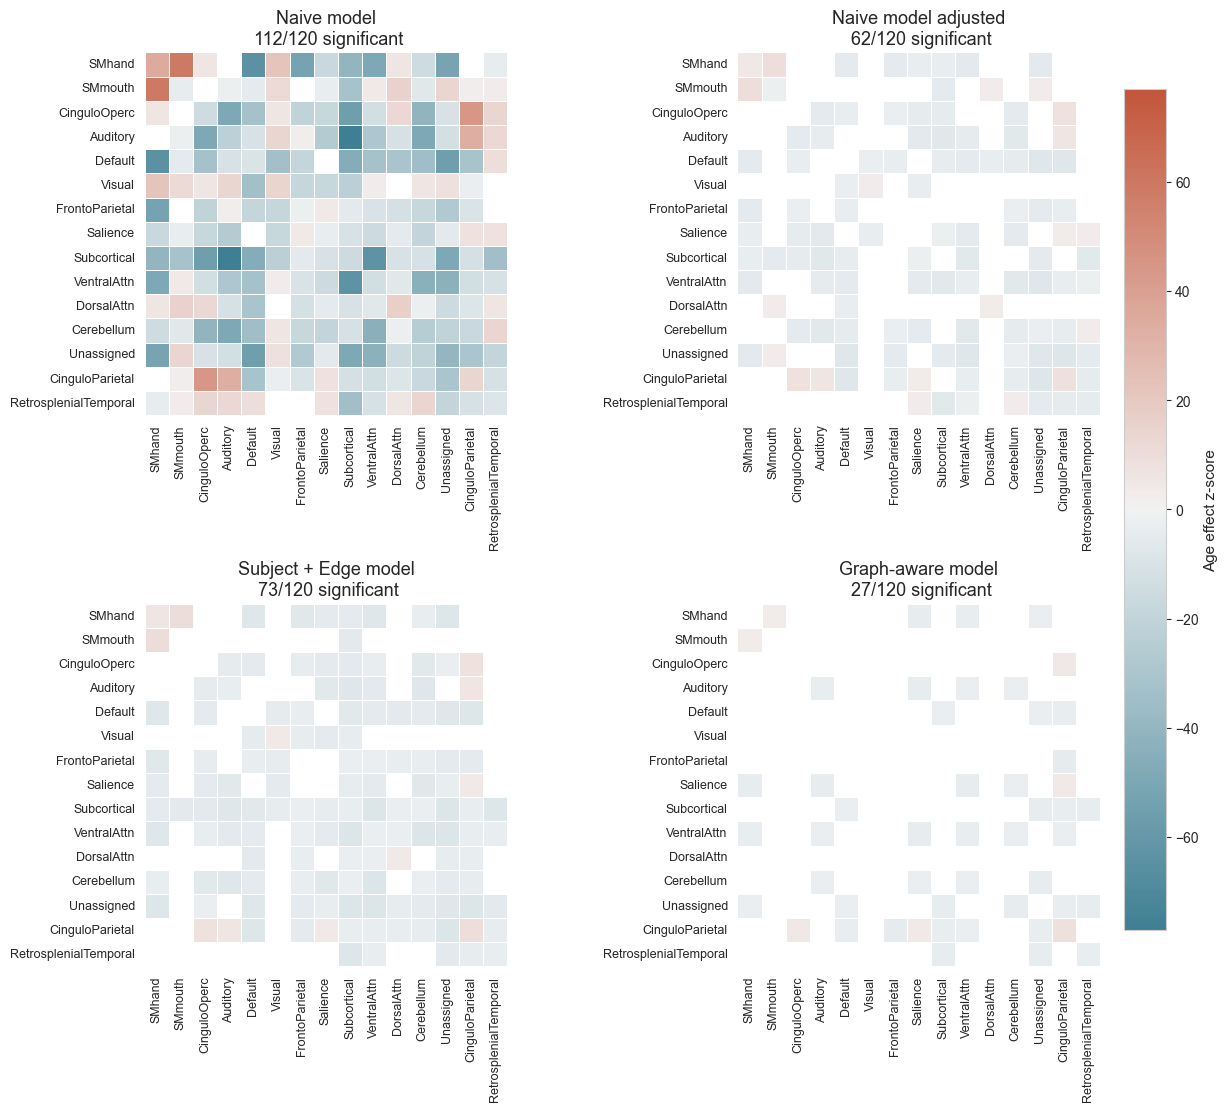

In [160]:
def clean_label(x):
    return "Unassigned" if x is None else x

focus_cov = "age"

network_order_plot = [clean_label(x) for x in network_order]
cell_labels_plot = [(clean_label(a), clean_label(b)) for a, b in cell_labels]


def build_system_matrix(values, sig_mask, cell_labels_plot, network_order_plot, nonsig_value=np.nan):
    K = len(network_order_plot)
    name_to_idx = {name: i for i, name in enumerate(network_order_plot)}

    mat = np.full((K, K), np.nan)
    sig = np.zeros((K, K), dtype=bool)

    for c, (net_a, net_b) in enumerate(cell_labels_plot):
        i = name_to_idx[net_a]
        j = name_to_idx[net_b]

        mat[i, j] = values[c]
        mat[j, i] = values[c]

        sig[i, j] = sig_mask[c]
        sig[j, i] = sig_mask[c]

    out = mat.copy()
    out[~sig] = nonsig_value
    return out


# ---- Global BH masks ----
reject_naive_global = np.asarray(
    ols_naive_global[focus_cov]["reject_global"],
    dtype=bool
)

reject_clust_global = np.asarray(
    ols_clust_global[focus_cov]["reject_global"],
    dtype=bool
)

reject_diag_global = np.asarray(
    global_diags_diag[focus_cov]["reject_global"],
    dtype=bool
)

reject_block_global = np.asarray(
    global_diags_block[focus_cov]["reject_global"],
    dtype=bool
)


# ---- Build matrices using GLOBAL BH ----
naive_mat = build_system_matrix(
    values=t_naive_full,
    sig_mask=reject_naive_global,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
)

adjse_mat = build_system_matrix(
    values=t_clust_full,
    sig_mask=reject_clust_global,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
)

diag_mat = build_system_matrix(
    values=all_diags_diag[focus_cov]["focus_z"],
    sig_mask=reject_diag_global,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
)

block_mat = build_system_matrix(
    values=all_diags_block[focus_cov]["focus_z"],
    sig_mask=reject_block_global,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
)


# ---- Common color scale based on all globally significant cells ----
all_vals = np.concatenate([
    naive_mat[~np.isnan(naive_mat)],
    adjse_mat[~np.isnan(adjse_mat)],
    diag_mat[~np.isnan(diag_mat)],
    block_mat[~np.isnan(block_mat)]
])

if len(all_vals) > 0:
    vmax = np.max(np.abs(all_vals))
else:
    vmax = 1.0

vmin = -vmax


# ---- Colormap ----
cmap = sns.diverging_palette(220, 20, as_cmap=True)
cmap.set_bad(color="white")


# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True)

panels = [
    (
        axes[0, 0],
        naive_mat,
        "Naive model",
        f"{reject_naive_global.sum()}/120 significant"
    ),
    (
        axes[0, 1],
        adjse_mat,
        "Naive model adjusted",
        f"{reject_clust_global.sum()}/120 significant"
    ),
    (
        axes[1, 0],
        diag_mat,
        "Subject + Edge model",
        f"{reject_diag_global.sum()}/120 significant"
    ),
    (
        axes[1, 1],
        block_mat,
        "Graph-aware model",
        f"{reject_block_global.sum()}/120 significant"
    ),
]

for ax, mat, title, subtitle in panels:
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=0,
        square=True,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=network_order_plot,
        yticklabels=network_order_plot,
    )

    ax.set_title(f"{title}\n {subtitle}", fontsize=13)
    ax.tick_params(axis="x", rotation=90, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")


# ---- Shared colorbar ----
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label("Age effect z-score", fontsize=11)

plt.show()

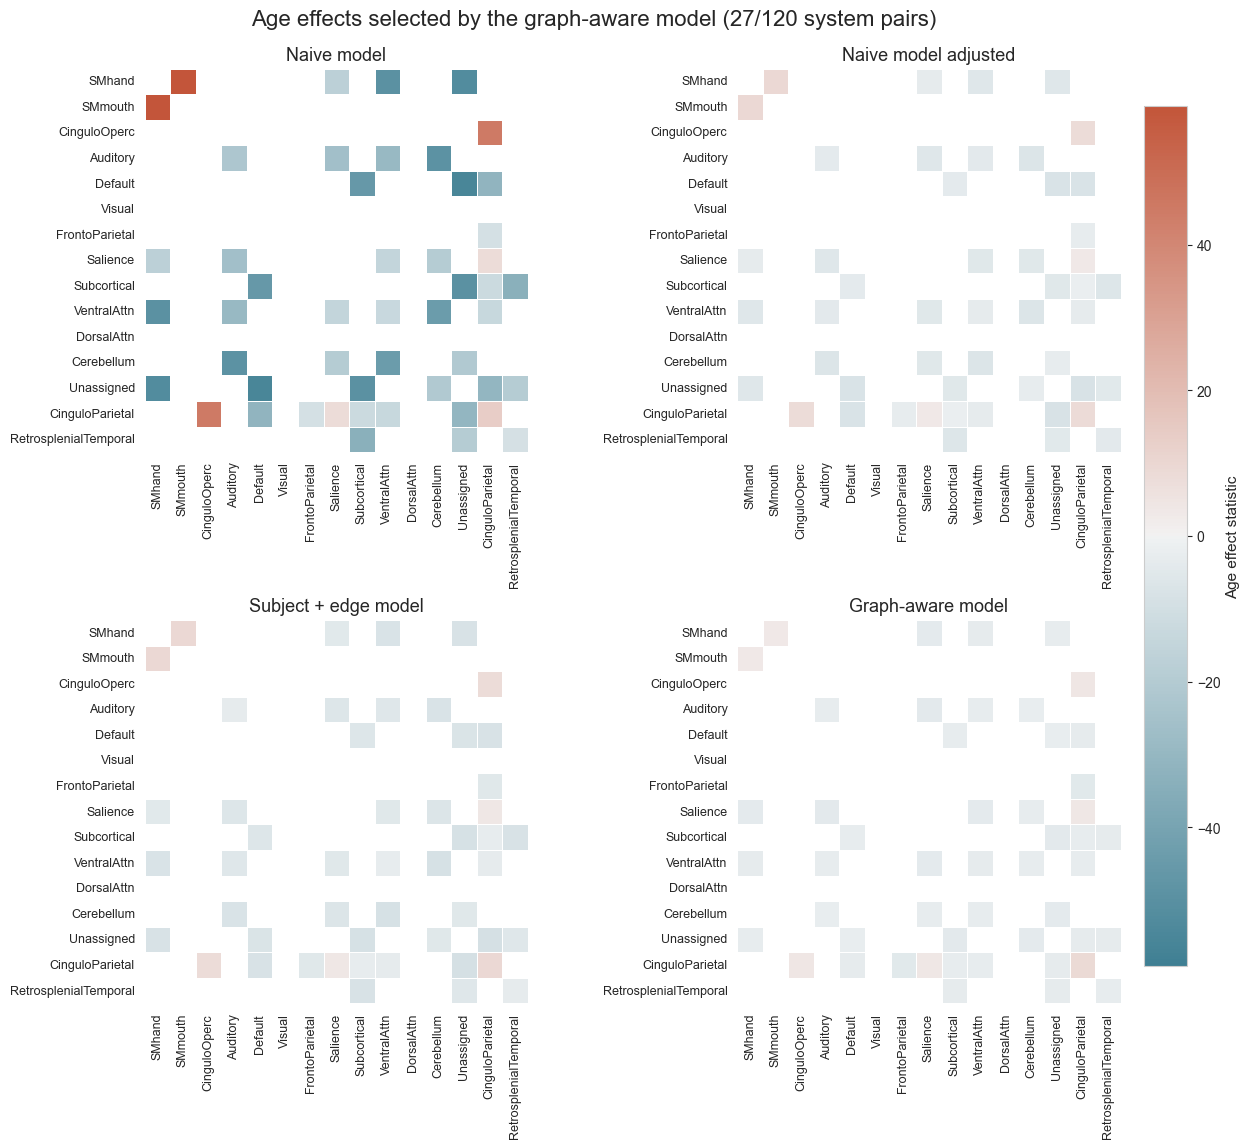

In [161]:
def clean_label(x):
    return "Unassigned" if x is None else x

focus_cov = "age"

network_order_plot = [clean_label(x) for x in network_order]
cell_labels_plot = [(clean_label(a), clean_label(b)) for a, b in cell_labels]


def build_system_matrix(values, display_mask, cell_labels_plot, network_order_plot, nonsig_value=np.nan):
    K = len(network_order_plot)
    name_to_idx = {name: i for i, name in enumerate(network_order_plot)}

    mat = np.full((K, K), np.nan)
    show = np.zeros((K, K), dtype=bool)

    for c, (net_a, net_b) in enumerate(cell_labels_plot):
        i = name_to_idx[net_a]
        j = name_to_idx[net_b]

        mat[i, j] = values[c]
        mat[j, i] = values[c]

        show[i, j] = display_mask[c]
        show[j, i] = display_mask[c]

    out = mat.copy()
    out[~show] = nonsig_value
    return out


# ---- Graph-aware mask: use this same mask for all panels ----
mask_final_model = np.asarray(
    global_diags_block[focus_cov]["reject_global"],
    dtype=bool
)

# ---- Build matrices using the SAME graph-aware mask ----
naive_mat = build_system_matrix(
    values=t_naive_full,
    display_mask=mask_final_model,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
)

adjse_mat = build_system_matrix(
    values=t_clust_full,
    display_mask=mask_final_model,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
)

diag_mat = build_system_matrix(
    values=all_diags_diag[focus_cov]["focus_z"],
    display_mask=mask_final_model,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
)

block_mat = build_system_matrix(
    values=all_diags_block[focus_cov]["focus_z"],
    display_mask=mask_final_model,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
)

# ---- Common color scale based only on displayed cells ----
all_vals = np.concatenate([
    naive_mat[~np.isnan(naive_mat)],
    adjse_mat[~np.isnan(adjse_mat)],
    diag_mat[~np.isnan(diag_mat)],
    block_mat[~np.isnan(block_mat)],
])

vmax = np.max(np.abs(all_vals)) if len(all_vals) > 0 else 1.0
vmin = -vmax

# ---- Colormap ----
cmap = sns.diverging_palette(220, 20, as_cmap=True)
cmap.set_bad(color="white")

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True)

n_final = mask_final_model.sum()

panels = [
    (axes[0, 0], naive_mat, "Naive model"),
    (axes[0, 1], adjse_mat, "Naive model adjusted"),
    (axes[1, 0], diag_mat, "Subject + edge model"),
    (axes[1, 1], block_mat, "Graph-aware model"),
]

for ax, mat, title in panels:
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=0,
        square=True,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=network_order_plot,
        yticklabels=network_order_plot,
    )

    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="x", rotation=90, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# ---- Shared colorbar ----
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label("Age effect statistic", fontsize=11)

fig.suptitle(
    f"Age effects selected by the graph-aware model ({n_final}/120 system pairs)",
    fontsize=16,
    y=1.03,
)

plt.show()

# Stability check

# Bootstrap stability check

In [ ]:
from sklearn.model_selection import train_test_split


# --------------------------------------------------
# Subject-level split
# --------------------------------------------------
unique_subj = np.unique(subject_id_sub)
subj_train, subj_test = train_test_split(
    unique_subj,
    test_size=0.2,
    random_state=42
)

train_mask = np.isin(subject_id_sub, subj_train)
test_mask  = np.isin(subject_id_sub, subj_test)

n_train_subj = len(subj_train)
n_test_subj  = len(subj_test)
n_train_obs  = train_mask.sum()
n_test_obs   = test_mask.sum()

# --------------------------------------------------
# Build full extra-covariate matrix
# --------------------------------------------------
extra_cov_full = np.column_stack([
    sleep_centered,
    motion_centered,
    g_centered,
    sexc,
    hisp_c,
    race_dummies_centered.to_numpy(),
    ses_centered,
])

extra_cov_names = [
    "sleep", "motion", "g", "sex", "hisp",
    "race_1", "race_2", "race_3", "ses"
]

# --------------------------------------------------
# Fit diagonal-V full model on training set
# --------------------------------------------------
model_diag_full_cv = LongitudinalGraphAwareEM_RI_cell(
    Y=Y_stacked_sub[train_mask],
    age=ages_centered_sub[train_mask],
    extra_covariates=extra_cov_full[train_mask],
    global_covariates=Z_site_stacked[train_mask],
    subject_id=subject_id_sub[train_mask],
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=extra_cov_names,
    global_covariate_names=site_cols,
    verbose=True,
    tol=1e-6,
)
model_diag_full_cv.fit()

# --------------------------------------------------
# Fit block-V full model on training set
# --------------------------------------------------

model_block_full_cv = LongitudinalGraphAwareEM_RI_BlockV_cell(
    Y=Y_stacked_sub[train_mask],
    edge_to_roi=edge_to_roi,
    roi_to_network=regions["NetworkNumber"].values,
    cells=cells,
    age=ages_centered_sub[train_mask],
    extra_covariates=extra_cov_full[train_mask],
    global_covariates=Z_site_stacked[train_mask],
    subject_id=subject_id_sub[train_mask],
    cell_id_of_edge=cell_id_of_edge,
    edges_per_cell=edges_per_cell,
    covariate_names=extra_cov_names,
    global_covariate_names=site_cols,
    verbose=True,
    tol=1e-6,
)
model_block_full_cv.fit()

# --------------------------------------------------
# Score on held-out subjects
# --------------------------------------------------
pll_diag_full = model_diag_full_cv.predictive_log_likelihood(
    Y=Y_stacked_sub[test_mask],
    age=ages_centered_sub[test_mask],
    extra_covariates=extra_cov_full[test_mask],
    global_covariates=Z_site_stacked[test_mask],
    subject_id=subject_id_sub[test_mask],
)

pll_block_full = model_block_full_cv.predictive_log_likelihood(
    Y=Y_stacked_sub[test_mask],
    age=ages_centered_sub[test_mask],
    extra_covariates=extra_cov_full[test_mask],
    global_covariates=Z_site_stacked[test_mask],
    subject_id=subject_id_sub[test_mask],
)

# --------------------------------------------------
# Report
# --------------------------------------------------
print(f"\n=== 80/20 CV results: FULL model ({n_test_subj} test subjects) ===")
print(f"Train subjects:         {n_train_subj}")
print(f"Test subjects:          {n_test_subj}")
print(f"Train observations:     {n_train_obs}")
print(f"Test observations:      {n_test_obs}")

print(f"\nPredictive log-likelihood:")
print(f"  Diag  PLL:            {pll_diag_full:>20.4f}")
print(f"  Block PLL:            {pll_block_full:>20.4f}")
print(f"  Gain (Block-Diag):    {pll_block_full - pll_diag_full:>+20.4f}")

print(f"\nPer subject:")
print(f"  Diag  PLL/subj:       {pll_diag_full  / n_test_subj:>20.4f}")
print(f"  Block PLL/subj:       {pll_block_full / n_test_subj:>20.4f}")
print(f"  Gain/subj:            {(pll_block_full - pll_diag_full) / n_test_subj:>+20.4f}")

print(f"\nPer observation:")
print(f"  Diag  PLL/obs:        {pll_diag_full  / n_test_obs:>20.4f}")
print(f"  Block PLL/obs:        {pll_block_full / n_test_obs:>20.4f}")
print(f"  Gain/obs:             {(pll_block_full - pll_diag_full) / n_test_obs:>+20.6f}")

In [ ]:
import matplotlib.pyplot as plt

# ---- Plot as before ----
plot_network_matrix(
    matrix=z_expanded,
    network_order=network_order,
    community_sizes=system_sizes,
    title="Age Effect (z-score), BH-corrected FDR 0.05 | RI + Block V + full covariates",
)

ax = plt.gca()

# ---- Compute cell centers in expanded matrix ----
cum_sizes = np.cumsum([0] + system_sizes)

for i in range(K):
    for j in range(K):
        # only lower triangle (including diagonal)
        if i < j:
            continue

        # only significant cells
        if not sig_matrix[i, j]:
            continue

        val = z_matrix[i, j]
        if np.isnan(val):
            continue

        # center of the block
        x_center = (cum_sizes[j] + cum_sizes[j+1]) / 2
        y_center = (cum_sizes[i] + cum_sizes[i+1]) / 2

        ax.text(
            x_center,
            y_center,
            f"{val:.1f}",   # format (1 decimal is usually best)
            ha='center',
            va='center',
            fontsize=8,
            color='black'
        )

plt.show()

# Significant cells for covariates

In [155]:
def summarize_significant_cells_with_counts_global(
    summary_dict,
    global_results_dict,
    cell_labels,
    top_k=None
):
    def clean(name):
        return "Unassigned" if name is None else str(name)

    z = np.asarray(summary_dict["focus_z"])
    sig = np.asarray(global_results_dict["reject_global"], dtype=bool)

    sig_idx = np.where(sig)[0]

    if len(sig_idx) == 0:
        print("No globally significant cells found.")
        return [], {}

    order = sig_idx[np.argsort(-np.abs(z[sig_idx]))]

    if top_k is not None:
        order = order[:top_k]

    results = []
    system_counts = {}

    print("\n=== Globally significant cells, sorted by |z| ===\n")

    for rank, c in enumerate(order, 1):
        net_a, net_b = cell_labels[c]
        net_a = clean(net_a)
        net_b = clean(net_b)
        z_val = z[c]

        results.append((net_a, net_b, z_val))

        for net in [net_a, net_b]:
            system_counts[net] = system_counts.get(net, 0) + 1

        print(f"{rank:2d}. ({net_a:>20}, {net_b:<20})  z = {z_val:>8.3f}")

    print(f"\nTotal globally significant cells: {len(sig_idx)}")

    system_counts_sorted = dict(
        sorted(system_counts.items(), key=lambda x: -x[1])
    )

    print("\n=== System involvement ===\n")
    for k, v in system_counts_sorted.items():
        print(f"{k:>20}: {v}")

    return results, system_counts_sorted

In [165]:
def plot_significant_system_heatmap_global(
    summary_dict,
    global_results_dict,
    cell_labels,
    network_order,
    title,
    count_in_title=True,
    lower_triangle=True,
    annotate=True,
    figsize=(8, 7),
    cmap=None,
    bad_color="white",
    linewidths=0.5,
    linecolor="#d9d9d9",
    fontsize_title=14,
    fontsize_ticks_x=9,
    fontsize_ticks_y=10,
    fontsize_annot=8,
    colorbar_label="Effect z-score",
    vmin=None,
    vmax=None,
):
    network_order_plot = [clean_label(x) for x in network_order]
    cell_labels_plot = [(clean_label(a), clean_label(b)) for a, b in cell_labels]

    z_values = np.asarray(summary_dict["focus_z"])
    sig_global = np.asarray(global_results_dict["reject_global"], dtype=bool)

    mat = build_system_matrix(
    values=z_values,
    display_mask=sig_global,
    #sig_mask=sig_global,
    cell_labels_plot=cell_labels_plot,
    network_order_plot=network_order_plot,
    nonsig_value=np.nan
    )

    plot_mat = mat.copy()
    K = plot_mat.shape[0]

    if lower_triangle:
        upper_mask = np.triu(np.ones((K, K), dtype=bool), k=1)
        plot_mat[upper_mask] = np.nan

    vals = plot_mat[~np.isnan(plot_mat)]

    if len(vals) == 0:
        print("No globally significant cells to plot.")
        return None, None

    if vmax is None:
        vmax = np.max(np.abs(vals))
    if vmin is None:
        vmin = -vmax

    if cmap is None:
        cmap = sns.diverging_palette(220, 20, as_cmap=True)

    cmap = cmap.copy()
    cmap.set_bad(color=bad_color)

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        plot_mat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=0,
        square=True,
        cbar=True,
        linewidths=linewidths,
        linecolor=linecolor,
        xticklabels=network_order_plot,
        yticklabels=network_order_plot,
        annot=False
    )

    if annotate:
        for i in range(K):
            for j in range(K):
                if np.isnan(plot_mat[i, j]):
                    continue

                val = plot_mat[i, j]
                text_color = "white" if abs(val) > 0.55 * vmax else "black"

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    fontsize=fontsize_annot,
                    color=text_color
                )

    n_sig = int(sig_global.sum())

    if count_in_title:
        full_title = f"{title}\nAfter multiple testing ({n_sig}/120 significant)"
    else:
        full_title = title

    ax.set_title(full_title, fontsize=fontsize_title)
    ax.tick_params(axis="x", rotation=90, labelsize=fontsize_ticks_x)
    ax.tick_params(axis="y", rotation=0, labelsize=fontsize_ticks_y)
    ax.set_xlabel("")
    ax.set_ylabel("")

    cbar = ax.collections[0].colorbar
    cbar.set_label(colorbar_label, fontsize=11)

    plt.tight_layout()
    plt.show()

    return fig, ax

## g-score

In [166]:
from scipy.stats import norm


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'g' (column 4)
  Raw significant cells at |z| > 1.96: 8 / 120
  Adjusted significant cells (BH, alpha=0.05): 3 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 g effects by |z-score|:
  Cell  82 ('FrontoParietal', 'CinguloParietal'): g = -0.002586  SE = 0.000766  z = -3.38  p = 7.340e-04  p_adj = 3.403e-02  (120 edges)
  Cell  90     ('Salience', 'CinguloParietal'): g = -0.003061  SE = 0.000911  z = -3.36  p = 7.772e-04  p_adj = 3.403e-02  (20 edges)
  Cell 117 ('Cingu

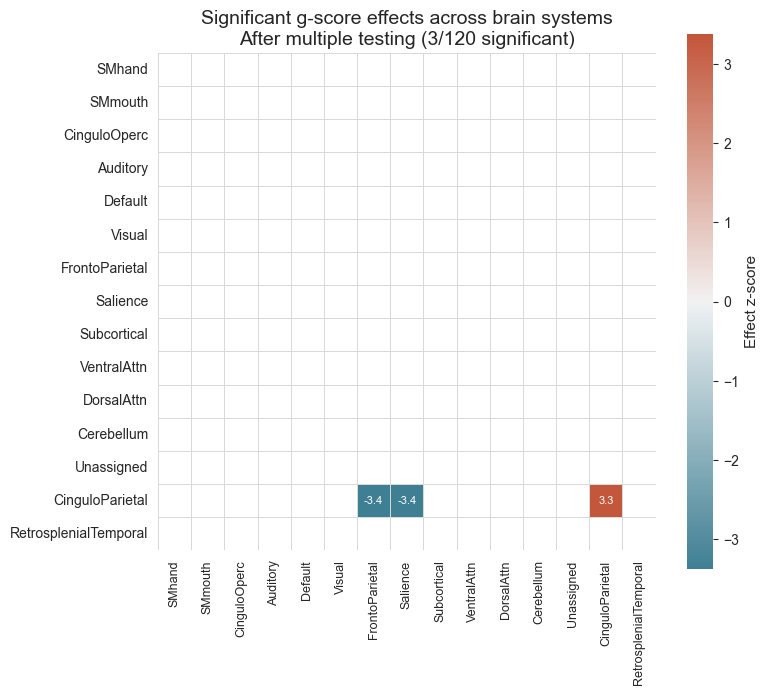

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant g-score effects across brain systems\nAfter multiple testing (3/120 significant)'}>)

In [167]:
focus_cov = "g"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant g-score effects across brain systems"
)

## sleep


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'sleep' (column 2)
  Raw significant cells at |z| > 1.96: 6 / 120
  Adjusted significant cells (BH, alpha=0.05): 2 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 sleep effects by |z-score|:
  Cell 103  ('VentralAttn', 'CinguloParietal'): sleep = +0.001802  SE = 0.000471  z = +3.83  p = 1.300e-04  p_adj = 1.321e-02  (115 edges)
  Cell  86         ('Salience', 'VentralAttn'): sleep = +0.001656  SE = 0.000448  z = +3.69  p = 2.202e-04  p_adj = 1.321e-02  (92 edges)
  Ce

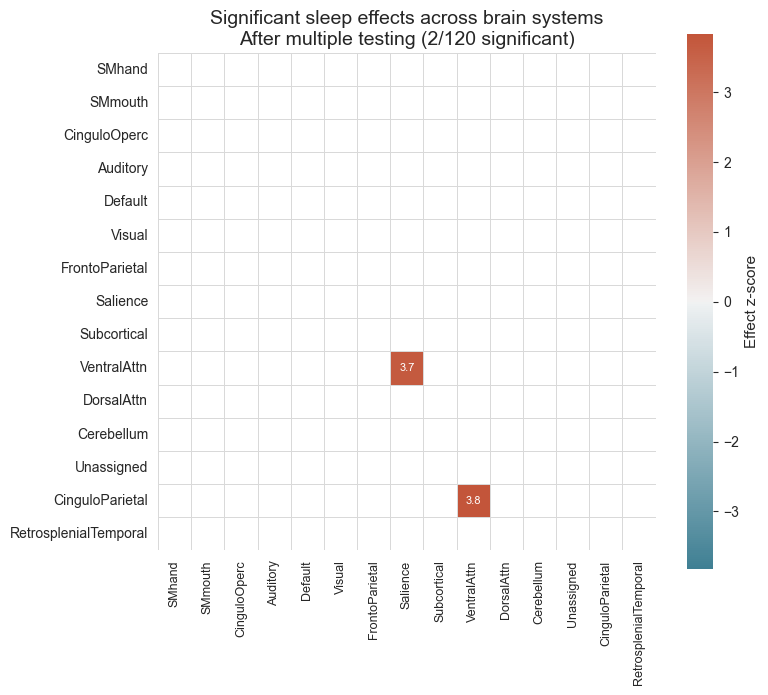

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant sleep effects across brain systems\nAfter multiple testing (2/120 significant)'}>)

In [168]:
focus_cov = "sleep"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant sleep effects across brain systems"
)

## sex


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'sex' (column 5)
  Raw significant cells at |z| > 1.96: 32 / 120
  Adjusted significant cells (BH, alpha=0.05): 17 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 sex effects by |z-score|:
  Cell  14 ('SMhand', 'RetrosplenialTemporal'): sex = -0.004076  SE = 0.000645  z = -6.31  p = 2.703e-10  p_adj = 3.243e-08  (304 edges)
  Cell  12                    ('SMhand', None): sex = -0.001163  SE = 0.000283  z = -4.10  p = 4.052e-05  p_adj = 2.431e-03  (1786 edges)
  Cell  

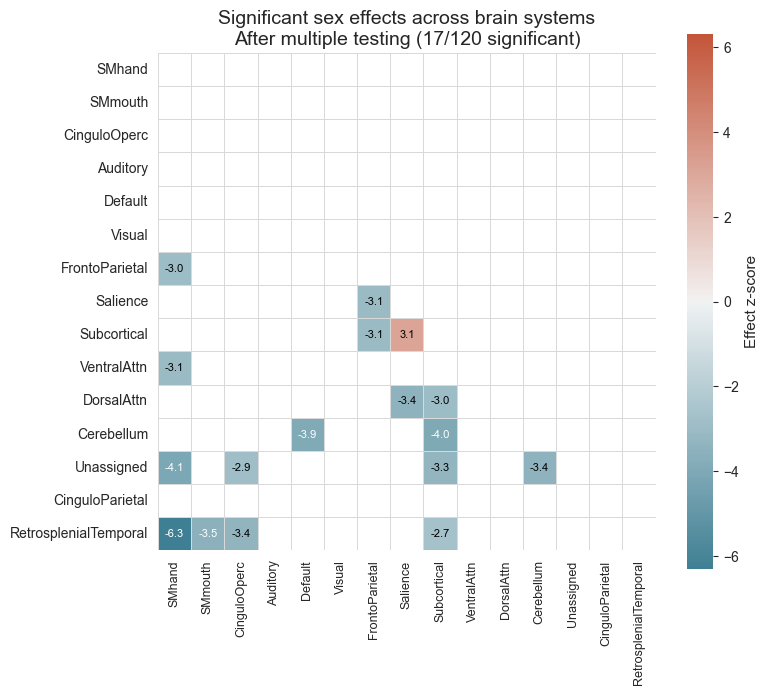

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant sex effects across brain systems\nAfter multiple testing (17/120 significant)'}>)

In [169]:
focus_cov = "sex"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant sex effects across brain systems"
)

# motion


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'motion' (column 3)
  Raw significant cells at |z| > 1.96: 88 / 120
  Adjusted significant cells (BH, alpha=0.05): 86 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 motion effects by |z-score|:
  Cell  91 ('Salience', 'RetrosplenialTemporal'): motion = +0.087696  SE = 0.006295  z = +13.93  p = 4.124e-44  p_adj = 4.949e-42  (32 edges)
  Cell  87          ('Salience', 'DorsalAttn'): motion = +0.053358  SE = 0.005371  z = +9.93  p = 2.971e-23  p_adj = 1.783e-21  (128 ed

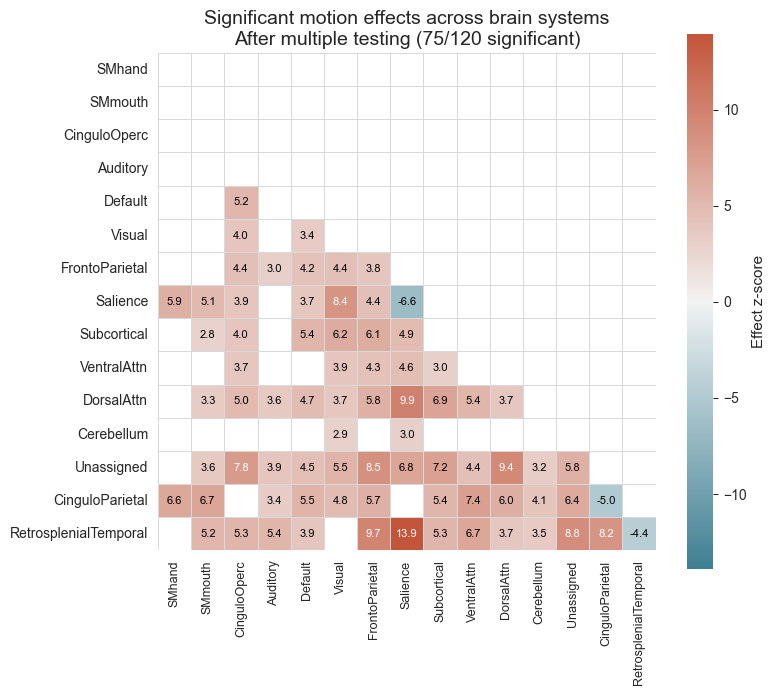

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant motion effects across brain systems\nAfter multiple testing (75/120 significant)'}>)

In [112]:
focus_cov = "motion"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant motion effects across brain systems"
)

### ses


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'ses' (column 10)
  Raw significant cells at |z| > 1.96: 2 / 120
  Adjusted significant cells (BH, alpha=0.05): 0 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 ses effects by |z-score|:
  Cell 108   ('DorsalAttn', 'CinguloParietal'): ses = +0.001948  SE = 0.000658  z = +2.96  p = 3.059e-03  p_adj = 3.671e-01  (160 edges)
  Cell 116     (None, 'RetrosplenialTemporal'): ses = -0.000411  SE = 0.000207  z = -1.98  p = 4.754e-02  p_adj = 9.771e-01  (376 edges)
  Cell 107

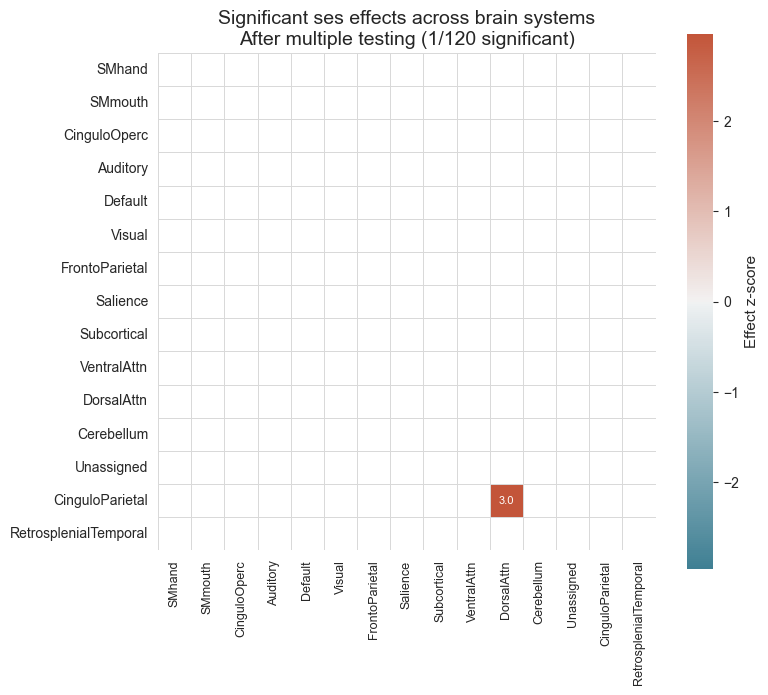

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant ses effects across brain systems\nAfter multiple testing (1/120 significant)'}>)

In [113]:
focus_cov = "ses"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant ses effects across brain systems"
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'hisp' (column 6)
  Raw significant cells at |z| > 1.96: 31 / 120
  Adjusted significant cells (BH, alpha=0.05): 9 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 hisp effects by |z-score|:
  Cell 111                ('Cerebellum', None): hisp = -0.001314  SE = 0.000300  z = -4.39  p = 1.157e-05  p_adj = 1.388e-03  (1457 edges)
  Cell   7              ('SMhand', 'Salience'): hisp = -0.003718  SE = 0.000994  z = -3.74  p = 1.832e-04  p_adj = 8.732e-03  (152 edges)
  Cel

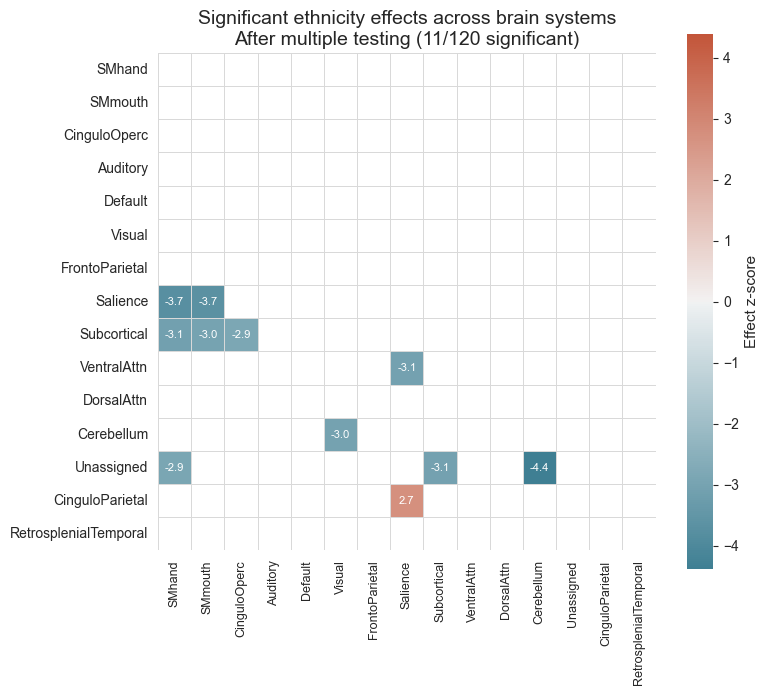

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant ethnicity effects across brain systems\nAfter multiple testing (11/120 significant)'}>)

In [115]:
focus_cov = "hisp"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant ethnicity effects across brain systems"
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'age:g' (column 11)
  Raw significant cells at |z| > 1.96: 19 / 120
  Adjusted significant cells (BH, alpha=0.05): 0 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 age:g effects by |z-score|:
  Cell  89                  ('Salience', None): age:g = -0.000796  SE = 0.000252  z = -3.16  p = 1.588e-03  p_adj = 1.906e-01  (188 edges)
  Cell  12                    ('SMhand', None): age:g = -0.000621  SE = 0.000212  z = -2.94  p = 3.334e-03  p_adj = 2.000e-01  (1786 edges)


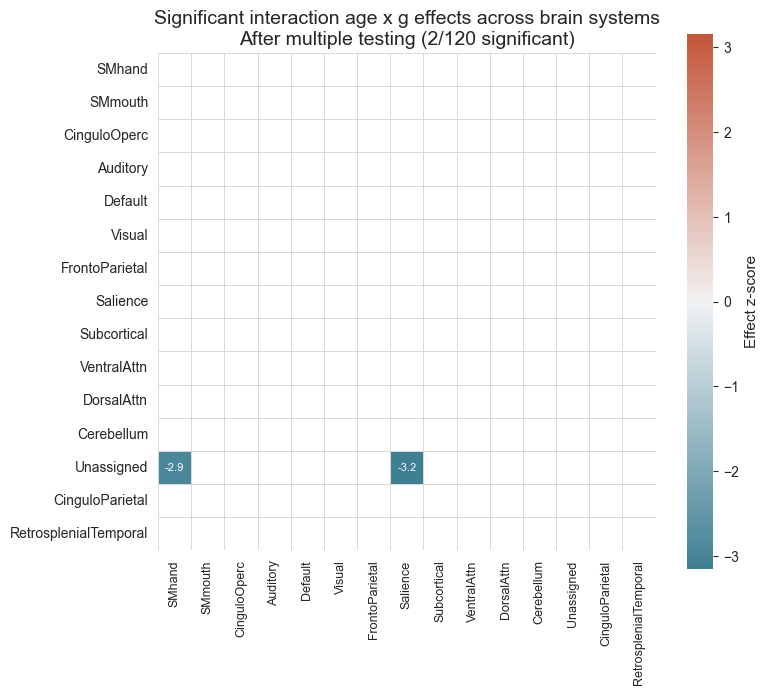

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant interaction age x g effects across brain systems\nAfter multiple testing (2/120 significant)'}>)

In [170]:
from scipy.stats import norm

focus_cov = "age:g"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant interaction age x g effects across brain systems"
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'race_1' (column 7)
  Raw significant cells at |z| > 1.96: 51 / 120
  Adjusted significant cells (BH, alpha=0.05): 40 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 race_1 effects by |z-score|:
  Cell  58          ('Default', 'Subcortical'): race_1 = -0.002307  SE = 0.000403  z = -5.72  p = 1.041e-08  p_adj = 1.042e-06  (2214 edges)
  Cell  96               ('Subcortical', None): race_1 = -0.001354  SE = 0.000240  z = -5.64  p = 1.737e-08  p_adj = 1.042e-06  (2538 ed

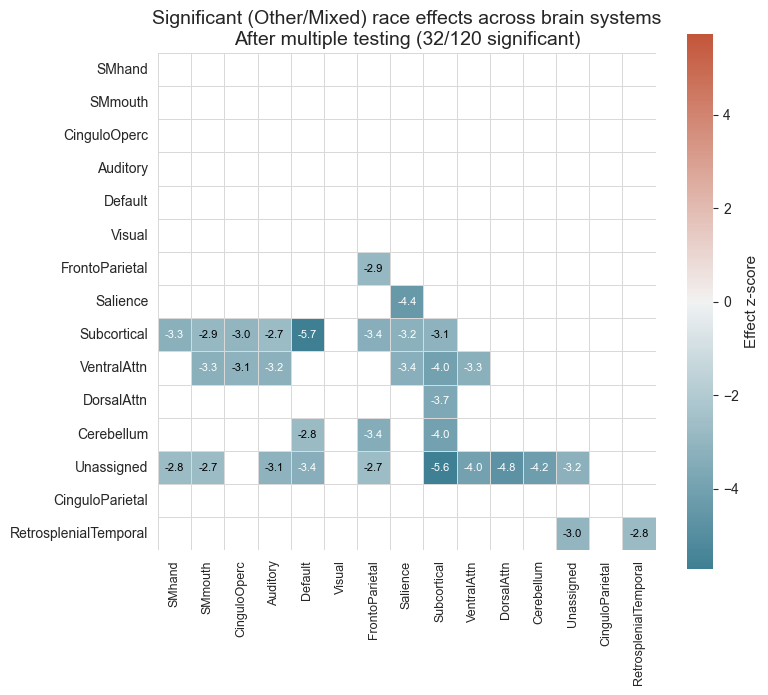

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant (Other/Mixed) race effects across brain systems\nAfter multiple testing (32/120 significant)'}>)

In [172]:
from scipy.stats import norm

focus_cov = "race_1"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant (Other/Mixed) race effects across brain systems"
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'race_2' (column 8)
  Raw significant cells at |z| > 1.96: 80 / 120
  Adjusted significant cells (BH, alpha=0.05): 70 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 race_2 effects by |z-score|:
  Cell  96               ('Subcortical', None): race_2 = -0.002069  SE = 0.000328  z = -6.32  p = 2.684e-10  p_adj = 3.221e-08  (2538 edges)
  Cell  80    ('FrontoParietal', 'Cerebellum'): race_2 = -0.003829  SE = 0.000675  z = -5.68  p = 1.369e-08  p_adj = 8.217e-07  (744 edg

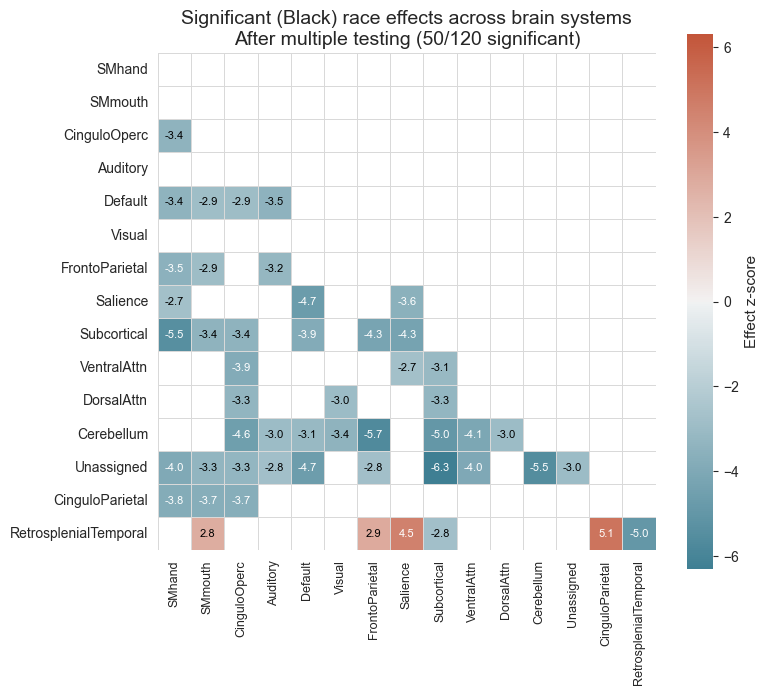

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant (Black) race effects across brain systems\nAfter multiple testing (50/120 significant)'}>)

In [173]:
focus_cov = "race_2"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant (Black) race effects across brain systems"
)


DIAGNOSTICS  (120 cells, 87153 edges, 2409 subjects)

  d (random intercept variance) = 0.000016
  Focus covariate: 'race_3' (column 9)
  Raw significant cells at |z| > 1.96: 27 / 120
  Adjusted significant cells (BH, alpha=0.05): 9 / 120

 Global coefficients:
site_site03 = 0.000565
site_site04 = -0.002953
site_site05 = 0.001350
site_site06 = 0.001333
site_site08 = -0.001126
site_site09 = 0.000680
site_site10 = -0.000958
site_site11 = 0.001250
site_site12 = -0.001092
site_site13 = -0.002691
site_site14 = 0.000656
site_site15 = 0.000155
site_site16 = 0.002107
site_site17 = -0.000665
site_site18 = -0.002162
site_site19 = -0.001500
site_site20 = -0.000309
site_site21 = 0.000651

Top 5 race_3 effects by |z-score|:
  Cell  91 ('Salience', 'RetrosplenialTemporal'): race_3 = +0.013131  SE = 0.003157  z = +4.16  p = 3.187e-05  p_adj = 3.825e-03  (32 edges)
  Cell  79    ('FrontoParietal', 'DorsalAttn'): race_3 = -0.013118  SE = 0.003479  z = -3.77  p = 1.625e-04  p_adj = 9.749e-03  (768 edge

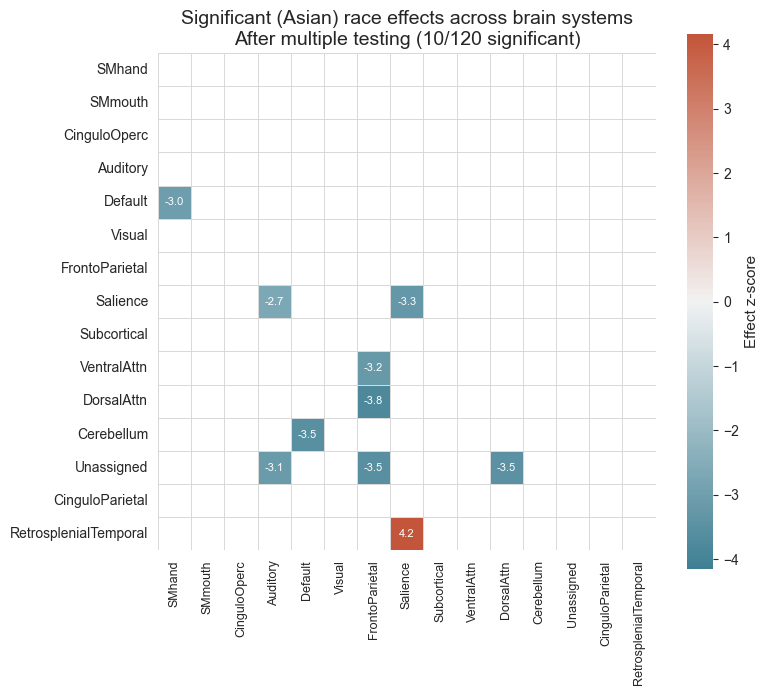

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Significant (Asian) race effects across brain systems\nAfter multiple testing (10/120 significant)'}>)

In [174]:
focus_cov = "race_3"

block_full_g = model_block_full.diagnostics(
    focus=focus_cov,
    cell_labels=cell_labels
)

results_g, system_counts_g = summarize_significant_cells_with_counts_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    top_k=10
)

plot_significant_system_heatmap_global(
    summary_dict=block_full_g,
    global_results_dict=global_diags_block[focus_cov],
    cell_labels=cell_labels,
    network_order=network_order,
    title="Significant (Asian) race effects across brain systems"
)

## all covariates

In [102]:
def significant_counts_barplot(
    all_diags,
    global_diags,
    alpha=0.05,
    skip=("intercept",),
    title="Number of significant cells by covariate",
    figsize=(11, 5),
):
    rows = []

    covariates = [cov for cov in all_diags.keys() if cov not in skip]

    for cov in covariates:
        z = np.asarray(all_diags[cov]["focus_z"])
        raw_sig = np.abs(z) > 1.96
        global_sig = np.asarray(global_diags[cov]["reject_global"], dtype=bool)

        rows.append({
            "covariate": cov,
            "Raw": int(raw_sig.sum()),
            "After multiple testing": int(global_sig.sum()),
        })

    counts_df = pd.DataFrame(rows)

    counts_long = counts_df.melt(
        id_vars="covariate",
        value_vars=["Raw", "After multiple testing"],
        var_name="Correction",
        value_name="Significant cells"
    )

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=counts_long,
        x="covariate",
        y="Significant cells",
        hue="Correction"
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("Number of significant cells")
    ax.set_ylim(0, 120)
    ax.tick_params(axis="x", rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    plt.legend(title="")
    plt.tight_layout()
    plt.show()

    return counts_df

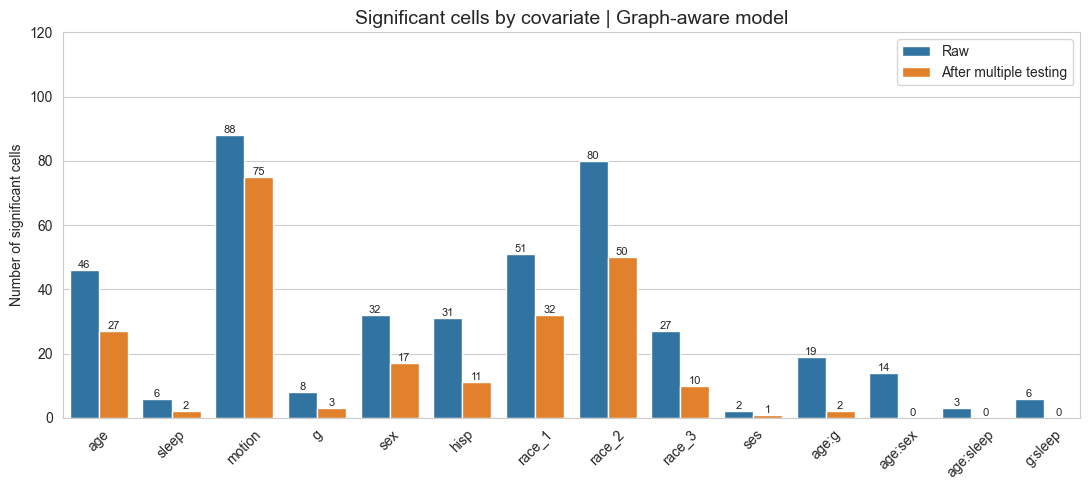

In [150]:
counts_block = significant_counts_barplot(
    all_diags=all_diags_block,
    global_diags=global_diags_block,
    title="Significant cells by covariate | Graph-aware model"
)

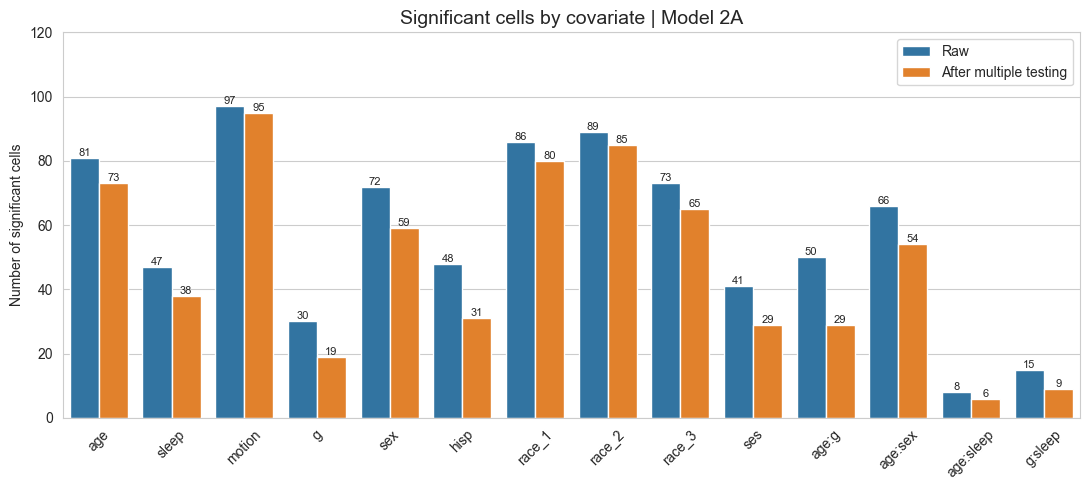

In [104]:
counts_diag = significant_counts_barplot(
    all_diags=all_diags_diag,
    global_diags=global_diags_diag,
    title="Significant cells by covariate | Model 2A"
)